# Exploring Some Aspects of Fixed Income with Python

In this session, we explore the world of bonds, the backbone of global finance.

Whether you're pricing a Treasury, managing duration risk, or identifying relative value opportunities, understanding bond math is essential. Bonds are deceptively simple on the surface, they're just a stream of fixed payments, but beneath that, they carry a complex world of interest rate dynamics, risk measures, and market structure.

### What You'll Learn Today:
> **How bonds work** — prices, coupons, and yield conventions  
> **Yield to maturity (YTM)** — interpreting market-implied returns  
> **Duration and convexity** — your tools for measuring interest rate risk  
> **Yield curves** — building structure from market data  
> **Rich/Cheap analysis** — is this bond mispriced relative to its peers?  
> **Credit spreads** — how much extra yield do corporates pay?  

Let’s break it down with theory, live code, and real bond data.

### Requirements \(Python Libraries\)

In [1]:
# Requirements
!pip install matplotlib
!pip install seaborn
!pip install scipy
!pip install statsmodels
!pip install plotly
!pip install QuantLib
!pip install xlrd


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 40.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 87.5 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 33.6 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.6/96.6 kB 7.4 MB/s eta 0:00:00

**Imports and Configuration**

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import date
import QuantLib as ql
from scipy.interpolate import interp1d, PchipInterpolator
import statsmodels.api as sm

# Configure seaborn theme and palette
sns.set_theme(style="whitegrid")
old_money_palette = [
    "#1C1F2A",  # Dark Navy
    "#2E4F36",  # Forest Green
    "#C1A45F",  # Gold Ochre
    "#E6D4B8",  # Muted Champagne
    "#5E5C58",  # Oxide Grey
    "#4C2C2B",  # Deep Burgundy
    "#3D5A40",  # Hunter Green
    "#F4EFE6",  # Ivory Cream
    "#6A5841",  # Dark Bronze
]
# Only set palette if the number of colors is valid (>0)
if old_money_palette:
    sns.set_palette(old_money_palette)

print("Imports and configuration completed successfully.")

Imports and configuration completed successfully.


# How bonds work
## 1. Cash Flows of a Plain Vanilla Bond

A plain vanilla bond pays fixed coupons periodically and repays face value at maturity.

**Example:**  
- Face Value = 1'000  
- Coupon Rate = 5%  
- Annual Payments  
- Maturity = 10 years

**Cash Flows (in \$):**

| Year         | 1   | 2   | 3   | 4   | 5   | 6   | 7   | 8   | 9   | 10     |
|--------------|-----|-----|-----|-----|-----|-----|-----|-----|-----|--------|
| Cash Flow    | 50  | 50  | 50  | 50  | 50  | 50  | 50  | 50  | 50  | 1'050  |



In [3]:
# Bond parameters
face_value = 1000
coupon_rate = 0.05
maturity = 10
frequency = 1

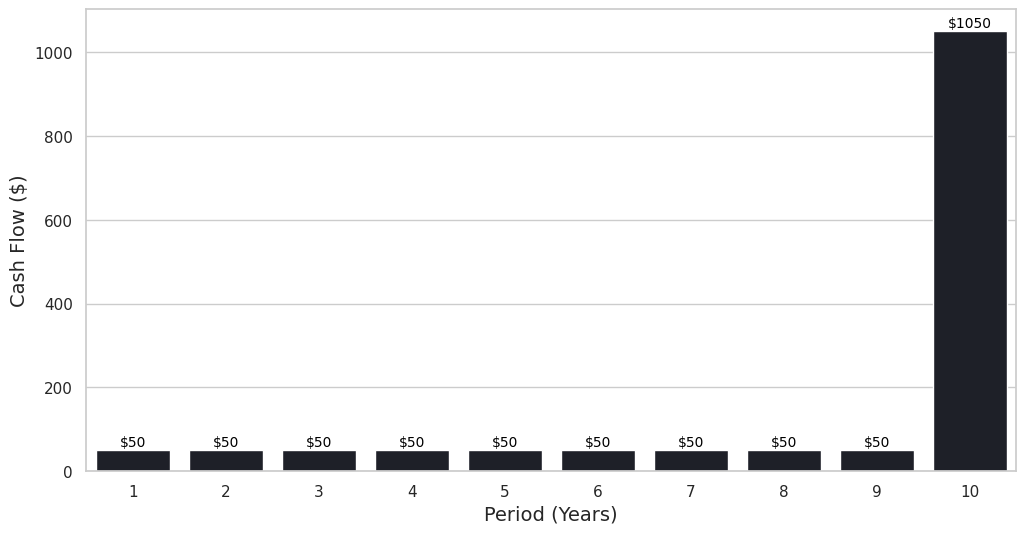

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette(old_money_palette)

# Bond parameters
face_value = 1000
coupon_rate = 0.05
maturity = 10
frequency = 1

# Function to generate bond cash flows
def bond_cash_flows(face_value, coupon_rate, maturity, frequency):
    periods = int(maturity * frequency)
    coupon = face_value * coupon_rate / frequency
    cash_flows = [coupon] * periods
    cash_flows[-1] += face_value  # Add face value to the last cash flow
    return pd.DataFrame({
        'Period': range(1, periods + 1),
        'Cash Flow': cash_flows
    })

# Function to calculate the present value of a bond
def bond_price(cash_flows, discount_rate):
    periods = cash_flows['Period']
    cash_flow_values = cash_flows['Cash Flow']
    return np.sum(cash_flow_values / (1 + discount_rate) ** periods)

# Generate bond cash flows
cash_flows = bond_cash_flows(face_value, coupon_rate, maturity, frequency)

# Plot the cash flows
plt.figure(figsize=(12, 6))
sns.barplot(x=cash_flows['Period'], y=cash_flows['Cash Flow'])
plt.xlabel("Period (Years)", fontsize=14)
plt.ylabel("Cash Flow ($)", fontsize=14)
# Annotate bars
for index, row in cash_flows.iterrows():
    plt.text(index, row['Cash Flow'] + 10, f"${row['Cash Flow']:.0f}",
             ha='center', color="black", fontsize=10)

plt.show()

## 2. Time Value of Money

The **time value of money** is a foundational concept in fixed income analysis. It reflects the idea that a dollar received today is worth more than a dollar received in the future, due to its potential earning capacity. This principle is central to the valuation of bonds and other financial instruments.

To determine the value of a bond or any stream of future cash flows, we must discount each future payment to its present value using an appropriate **discount rate**, which reflects the opportunity cost of capital and the risk associated with the cash flows.

### Present Value Formula

The present value of a single future cash flow is calculated as:

$$
PV = \frac{CF}{(1 + r)^t}
$$

Where:
- $PV$ = present value of the cash flow  
- $CF$ = amount of the cash flow at time $t$  
- $r$ = discount rate (per period, expressed in decimal form)  
- $t$ = number of periods until payment

This formula adjusts the future payment to reflect the amount that would be equivalent in today's terms, assuming reinvestment at rate $r$.

### Application to Bond Cash Flows

Consider the bond from Section 1:

- Face Value = 1'000  
- Coupon Rate = 5%  
- Annual coupon = \$50  
- Maturity = 10 years  
- Discount Rate = 4%

Each coupon and the principal repayment are discounted to the present using the formula above. The sum of these present values gives the **market price** of the bond. For example, the present value of the first coupon is:

$$
PV = \frac{50}{(1 + 0.04)^1} = 48.08
$$

And the final payment of \$1,050 at year 10 is:

$$
PV = \frac{1{,}050}{(1 + 0.04)^{10}} = \frac{1{,}050}{1.48024} \approx 709.26
$$

In [5]:
def bond_cash_flows(face_value, coupon_rate, maturity, frequency, yld):
    periods = int(maturity * frequency)
    coupon = face_value * coupon_rate / frequency
    cash_flows = [coupon] * periods
    cash_flows[-1] += face_value  # Add face value to the last cash flow
    return pd.DataFrame({
        'Period': range(1, periods + 1),
        'Cash Flow': cash_flows,
        'Discounted Value': [cf / (1 + yld) ** p for p, cf in zip(range(1, periods + 1), cash_flows)]})

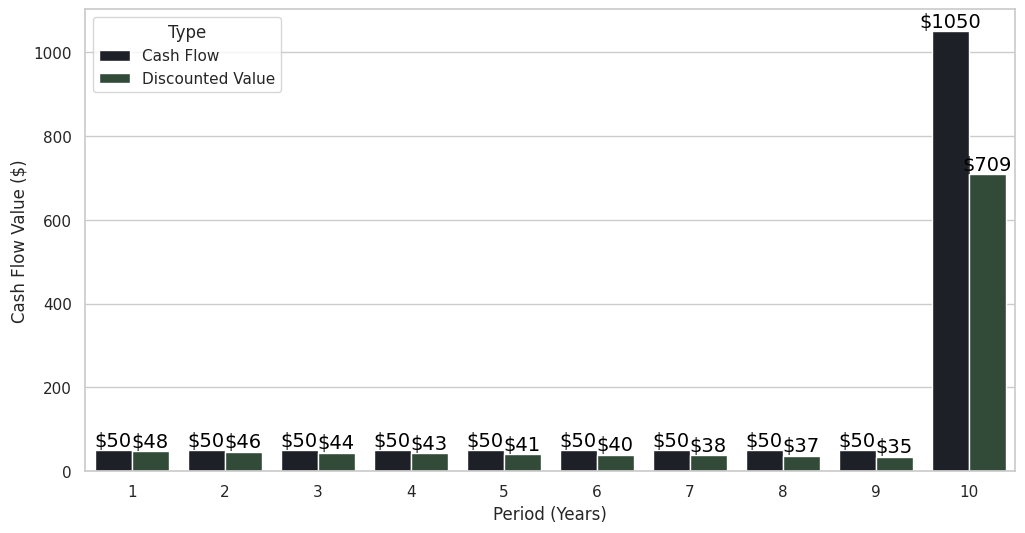

In [6]:
# Generate bond cash flows (example data, adjust as needed)
face_value = 1000
coupon_rate = 0.05
maturity = 10
payment_frequency = 1
yld = 0.04

# Generate data
cash_flows = bond_cash_flows(face_value, coupon_rate, maturity, payment_frequency, yld)

# Convert DataFrame to long format for Seaborn
long_cash_flows = cash_flows.melt(id_vars=["Period"], 
                                  value_vars=["Cash Flow", "Discounted Value"], 
                                  var_name="Type", 
                                  value_name="Value")

# Define a custom color palette using the specified colors

# Plot using Seaborn
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x="Period", y="Value", hue="Type", data=long_cash_flows)
# Add annotations to the bars
for bar, row in zip(ax.patches, long_cash_flows.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 10, 
        f"${row.Value:.0f}", ha='center', fontsize=14, color="black")
plt.xlabel("Period (Years)")
plt.ylabel("Cash Flow Value ($)")
plt.show()

## 3. Par, Discount, and Premium Bonds

A core principle in bond valuation is the relationship between a bond’s **coupon rate**, its **yield to maturity (YTM)** — or discount rate — and its **price**. This relationship determines whether the bond trades at **par**, **a premium**, or **a discount**.

### Par Bond
A bond trades **at par** when its **price equals its face value** (typically \$1,000). This occurs when the **coupon rate equals the YTM** — meaning the bond’s promised interest payments match the return demanded by the market.
> **Coupon Rate = Discount Rate**
> **Price = Face Value**

**Example**:  
At a **discount rate of 5%**, the bond price is **\$1,000**. → The bond trades **at par**.

### Premium Bond
A bond trades **at a premium** when its **price is above face value**. This happens when the **coupon rate exceeds the discount rate**. Investors are willing to pay more because the bond delivers above-market coupon payments.
> **Coupon Rate > Discount Rate**
> **Price > Face Value**

**Example**:  
At a **discount rate of 2%**, the bond price is **\$1,269.48**. → The bond trades **at a premium**.

### Discount Bond
A bond trades **at a discount** when its **price is below face value**. This occurs when the **coupon rate is less than the discount rate**. The investor is compensated for the lower coupon through a capital gain at maturity.
> **Coupon Rate < Discount Rate**
> **Price < Face Value**

**Example**:  
At a **discount rate of 8%**, the bond price is **\$798.70**. → The bond trades **at a discount**.

### Summary Table (Based on Examples)
| Discount Rate (%) | Bond Price ($) | Bond Type     |
|-------------------|----------------|---------------|
| 2.0               | 1,269.48       | Premium       |
| 5.0               | 1,000.00       | Par           |
| 8.0               |   798.70       | Discount      |

This **inverse relationship** between price and yield is a **core tenet** of fixed income mathematics. When yields rise, bond prices fall — and when yields fall, bond prices rise. The degree of sensitivity to interest rate changes depends on the bond’s **duration** and **coupon structure**, topics we explore in detail later.


   Discount Rate (%)  Bond Price ($) Relationship
0                2.0     1269.477550    Above Par
1                5.0     1000.000000          Par
2                8.0      798.697558    Below Par


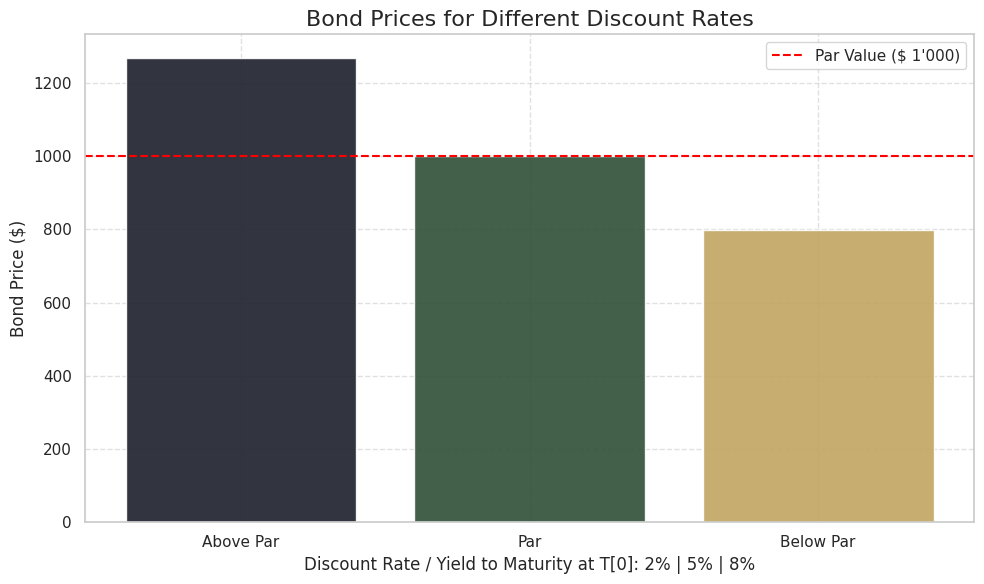

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ### Step 1: Define Cash Flow Table (from previous notebook)
def bond_cash_flows(face_value, coupon_rate, maturity, frequency):
    periods = int(maturity * frequency)
    coupon = face_value * coupon_rate / frequency
    cash_flows = [coupon] * periods
    cash_flows[-1] += face_value
    return pd.DataFrame({
        'Period': range(1, periods + 1),
        'Cash Flow': cash_flows
    })

# Bond parameters
face_value = 1000
coupon_rate = 0.05
maturity = 10
payment_frequency = 1
cash_flows = bond_cash_flows(face_value, coupon_rate, maturity, payment_frequency)

# ### Step 2: Define Discounting Function
def bond_price(cash_flows, discount_rate):
    """
    Calculate the present value (price) of a bond given its cash flows and discount rate.
    
    Parameters:
    - cash_flows: DataFrame containing periods and cash flows
    - discount_rate: Annual discount rate
    
    Returns:
    - Present value of the bond (price)
    """
    periods = cash_flows['Period']
    cash_flow_values = cash_flows['Cash Flow']
    return np.sum(cash_flow_values / (1 + discount_rate) ** periods)

# ### Step 3: Calculate Bond Prices for Below Par, Par, and Above Par
discount_rates = [0.02, 0.05, 0.08]  # below par, par, above par
prices = [bond_price(cash_flows, rate) for rate in discount_rates]

# Display Results
results = []
for rate, price in zip(discount_rates, prices):
    relation = "Below Par" if rate > coupon_rate else "Par" if rate == coupon_rate else "Above Par"
    results.append([rate * 100, price, relation])

df_results = pd.DataFrame(results, columns=["Discount Rate (%)", "Bond Price ($)", "Relationship"])
print(df_results)

# ### Step 4: Pull-to-Par Mechanism
def pull_to_par(cash_flows, discount_rate, years_to_maturity):
    """
    Simulate bond price evolution over time showing pull-to-par.
    
    Parameters:
    - cash_flows: DataFrame containing bond cash flows
    - discount_rate: Annual discount rate
    - years_to_maturity: List of years remaining to maturity
    
    Returns:
    - List of bond prices over time
    """
    prices = []
    for t in years_to_maturity:
        reduced_cash_flows = cash_flows[cash_flows['Period'] <= t].copy()
        reduced_cash_flows['Period'] -= (maturity - t) # Adjust periods
        prices.append(bond_price(reduced_cash_flows, discount_rate))
    return prices

# Simulate pull-to-par for a bond starting with a discount rate of 4% (Below Par)
remaining_years = list(range(maturity, 0, -1))
pull_to_par_prices = pull_to_par(cash_flows, 0.04, remaining_years)

# Visualize prices for below par, par, and above par
plt.figure(figsize=(10, 6))
cmap = plt.cm.viridis
plt.bar(["Above Par", "Par", "Below Par"], prices, color=["#1C1F2A","#2E4F36","#C1A45F"], alpha=0.9)
plt.axhline(face_value, color='red', linestyle='--', label="Par Value ($ 1'000)")
plt.title("Bond Prices for Different Discount Rates", fontsize=16)
plt.ylabel("Bond Price ($)", fontsize=12)
plt.xlabel("Discount Rate / Yield to Maturity at T[0]: 2% | 5% | 8%", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 4. Amortization and Accretion

In fixed income analysis, the concepts of **amortization** and **accretion** explain how a bond’s book value evolves over time when the bond is purchased at a price different from par. These adjustments are particularly important in the context of **book valuation**, **interest income recognition**, and **regulatory accounting**.

When a bond is purchased at a price **above** or **below par**, the difference is systematically **amortized** or **accreted** over its remaining life, converging to par at maturity. This phenomenon is also referred to as the **pull-to-par effect**.

### Key Concepts

> **Premium Bond**: Purchased **above par**. The bond’s book value **declines** toward par over time — a process known as **amortization**.
> **Discount Bond**: Purchased **below par**. The bond’s book value **increases** toward par over time — a process known as **accretion**.
> **Par Bond**: No adjustment is necessary — price equals face value throughout.

Assuming the issuer does not default and market rates remain unchanged, the bond's price will approach par as the maturity date nears.

### Why It Matters

These accounting adjustments affect:

> The **book value** of fixed income holdings over time  
> The **effective yield** recognized by investors  
> The allocation of **interest income vs. capital gain/loss** in reporting & taxes.

### Numerical Examples (Based on Market Discount Rates)

Consider a 10-year, 5% annual coupon bond with a \$1,000 face value. Depending on market rates, the bond trades at different prices:

| Discount Rate (%) | Bond Price ($) | Bond Type     |
|-------------------|----------------|---------------|
| 2.0               | 1,269.48        | Premium       |
| 5.0               | 1,000.00        | Par           |
| 8.0               |   798.70        | Discount      |

> At a **2% market rate**, the bond trades **above par** due to its relatively high coupon. The excess value over par (\$269.48) will be **amortized** over 10 years.
> At **5%**, the bond trades at **par**. No amortization or accretion is needed.
> At an **8% market rate**, the bond trades **below par**. The bondholder receives low coupon payments relative to market demands, but this is compensated by **accretion** of the bond’s value from \$798.70 to \$1,000 at maturity.

### Straight-Line Accretion / Amortization Example

Using straight-line methods for simplicity, we can estimate the annual adjustment:

**Premium Bond at 2%:**

$$
\text{Annual Amortization} = \frac{1{,}269.48 - 1{,}000}{10} = 26.95
$$

**Discount Bond at 8%:**

$$
\text{Annual Accretion} = \frac{1{,}000 - 798.70}{10} = 20.13
$$

### Summary Table

| Bond Type      | Purchase Price | Trend to Par | Accounting Effect |
|----------------|----------------|--------------|-------------------|
| **Premium**    | Price > Par    | Amortizes ↓  | Reduces book value annually |
| **Par**        | Price = Par    | —            | No adjustment needed |
| **Discount**   | Price < Par    | Accretes ↑   | Increases book value annually |

Amortization and accretion are not just accounting formalities — they reflect how investors **earn or give up value** over time relative to the bond’s stated coupon. These mechanisms help ensure that **book yield converges with market yield**, preserving economic consistency in fixed income portfolios.

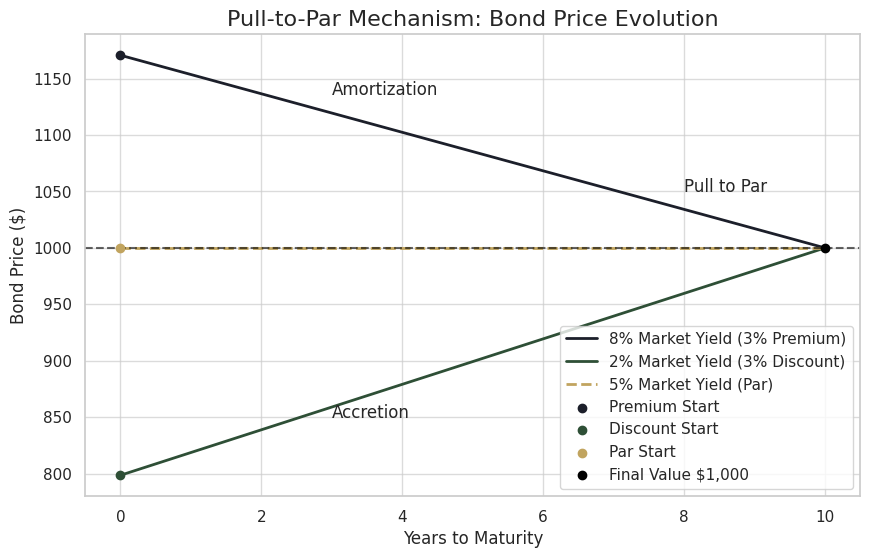

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Bond parameters
face_value = 1000
coupon_rate = 0.05
maturity = 10
payment_frequency = 1

# Define function to calculate bond prices based on cash flows
def bond_cash_flows(face_value, coupon_rate, maturity, frequency):
    periods = int(maturity * frequency)
    coupon = face_value * coupon_rate / frequency
    cash_flows = [coupon] * periods
    cash_flows[-1] += face_value  # Add face value to the last payment (at maturity)
    return pd.DataFrame({
        'Period': range(1, periods + 1),
        'Cash Flow': cash_flows
    })

def bond_price(cash_flows, discount_rate):
    """ Calculate the present value (price) of a bond given its cash flows and discount rate. """
    periods = cash_flows['Period']
    cash_flow_values = cash_flows['Cash Flow']
    return np.sum(cash_flow_values / (1 + discount_rate) ** periods)

cash_flows = bond_cash_flows(face_value, coupon_rate, maturity, payment_frequency)
premium_start = bond_price(cash_flows, 0.03)  # Bond priced at a 3% premium
par_start = bond_price(cash_flows, 0.05)  # Par value at 5% yield
discount_start = bond_price(cash_flows, 0.08)  # Bond priced at an 8% discount

years_to_maturity = np.arange(0, maturity + 1)

# Calculate the pull-to-par paths
premium_prices = premium_start - (premium_start - face_value) * (years_to_maturity / maturity)
discount_prices = discount_start + (face_value - discount_start) * (years_to_maturity / maturity)
par_prices = np.full_like(years_to_maturity, face_value)  # Par price remains constant

# Plot
plt.figure(figsize=(10, 6))
plt.plot(years_to_maturity, premium_prices, label="8% Market Yield (3% Premium)", linewidth=2)
plt.plot(years_to_maturity, discount_prices, label="2% Market Yield (3% Discount)", linewidth=2)
plt.plot(years_to_maturity, par_prices, label="5% Market Yield (Par)", linestyle="--", linewidth=2)
plt.axhline(face_value, color="black", linestyle="--", alpha=0.6)  # Par value line
plt.scatter(years_to_maturity[0], premium_prices[0], label="Premium Start", zorder=10)
plt.scatter(years_to_maturity[0], discount_prices[0], label="Discount Start", zorder=10)
plt.scatter(years_to_maturity[0], par_prices[0], label="Par Start", zorder=10)
plt.scatter(years_to_maturity[-1], par_prices[-1], color="black", label="Final Value $1,000", zorder=10)
# Annotations
plt.annotate("Pull to Par", xy=(maturity, face_value), xytext=(8, face_value + 50))
plt.annotate("Accretion", xy=(5, discount_prices[5]), xytext=(3, discount_prices[5] - 50))
plt.annotate("Amortization", xy=(5, premium_prices[5]), xytext=(3, premium_prices[5] + 50))
# Labels and title with enhanced explanations
plt.title("Pull-to-Par Mechanism: Bond Price Evolution", fontsize=16)
plt.xlabel("Years to Maturity", fontsize=12)
plt.ylabel("Bond Price ($)", fontsize=12)
plt.grid(alpha=0.7)
plt.legend()
plt.show()

## 5. Clean vs. Dirty Price
In bond markets, the quoted price of a bond often differs from the amount actually paid by the buyer. This distinction arises from **accrued interest**, which reflects the earned but unpaid coupon income between two coupon dates.

### Definitions
- **Clean Price**: The quoted price of the bond **excluding accrued interest**. This is the price used in bond listings and screen quotes.  
- **Dirty Price**: The **actual price paid** by the buyer, which includes the **clean price plus accrued interest**.

$$
\text{Dirty Price} = \text{Clean Price} + \text{Accrued Interest}
$$

The dirty price reflects the **total consideration** exchanged at settlement and is used for **cash flow and accounting purposes**.


### Accrued Interest (AI)
Between coupon dates, the bondholder earns interest on a daily basis. When a bond is sold before the next coupon payment, the seller is compensated for the accrued interest up to the settlement date.

The standard formula for accrued interest is:

$$
\text{AI} = \frac{\text{Coupon} \times \text{Days Since Last Payment}}{\text{Coupon Interval}}
$$

Where:
- **Coupon** is the periodic interest payment  
- **Days Since Last Payment** = number of days since last coupon (e.g. Jan 1 to Apr 1 = 90)  
- **Coupon Interval** = 365 (for annual bonds with Actual/Actual convention)

---

### Example: 5% Annual Coupon, 10-Year Bond
> Face Value = \$1,000  
> Coupon Rate = 5% annually → \$50 every year  
> Last coupon paid on **January 1**  
> Settlement date = **April 1** (90 days after)  
> Day count convention: **Actual/Actual**  
> Clean Price = \$980

Then:

$$
\text{AI} = \frac{50 \times 90}{365} = 12.33
$$

So the **dirty price** is:

$$
\text{Dirty Price} = 980 + 12.33 = 992.33
$$

### Why It Matters
- The **clean price** is used for quoting and tracking market value.  
- The **dirty price** is used in **settlement** and **total return** calculations.  
- Accrued interest ensures fairness in **ownership of earned income** between seller and buyer.

### Market Conventions
- Accrued interest is calculated according to specific **day count conventions** (e.g., 30/360, Actual/Actual).  
- Bonds quoted with a clean price convention include **Treasuries, corporates, and many sovereigns**.

Understanding the distinction between clean and dirty prices is essential for accurate **pricing**, **accounting**, and **performance attribution** in fixed income portfolios.

## 6. Yield to Maturity (YTM)

The **Yield to Maturity (YTM)** is a cornerstone concept in fixed income analysis. It represents the **internal rate of return (IRR)** of a bond — the single discount rate that makes the **present value of all future cash flows** equal to the bond’s current **market price**.

### Definition

Mathematically, YTM is the solution $y$ to the following equation:

$$
P = \sum_{i=1}^{n} \frac{CF_i}{(1 + y)^{t_i}}
$$

Where:
- $P$ = current bond price  
- $CF_i$ = cash flow at time $t_i$ (coupon or principal)  
- $y$ = yield to maturity (annualized)  
- $t_i$ = time in years until cash flow $i$  
- $n$ = total number of cash flows

This equation generally **cannot be solved analytically** and is computed numerically, for example using **Newton-Raphson iteration** or Excel's `IRR` function.

### Key Properties of YTM

- Expresses the **expected annual return** if the bond is held to maturity and all payments are made as scheduled.
- Assumes that **all coupon payments are reinvested** at the same rate $y$.
- Determines whether the bond trades at a **discount**, **par**, or **premium**:
  - If **YTM > coupon rate** → price < par (discount)
  - If **YTM = coupon rate** → price = par
  - If **YTM < coupon rate** → price > par (premium)



### Example: 10-Year 5% Bond

Let’s consider our standard bond:

- Face Value = \$1,000  
- Annual Coupon = 5% → \$50 per year  
- Maturity = 10 years  
- Market Price = \$920

We want to find the yield $y$ that satisfies:

$$
920 = \sum_{t=1}^{9} \frac{50}{(1 + y)^t} + \frac{1{,}050}{(1 + y)^{10}}
$$

This equation is typically solved numerically. The solution is:

$$
y \approx 6.27\%
$$

This means the investor will earn an **annualized return of approximately 6.27%** if the bond is held to maturity, all cash flows are received on time, and coupons are reinvested at the same yield.

### Intuition

Think of YTM as the bond’s **internal rate of return**, which equates the price you pay today to the present value of all future cash flows.

>It is a unifying measure that allows investors to compare bonds of **different coupons, maturities, and prices** on a common basis.

### Practical Use

YTM is used to:
- **Value fixed income securities**
- **Compare bonds** across issuers and structures
- **Assess return expectations**, given current market conditions
- **Anchor risk metrics** like duration and convexity

### Important Caveats

- YTM assumes **no default** or prepayment risk.
- It also assumes **reinvestment of coupons at the YTM**, which may not reflect actual reinvestment opportunities.
- For callable or amortizing bonds, **yield to call** or **yield to worst** may be more appropriate.

Despite its limitations, YTM remains a foundational tool in bond valuation and portfolio construction.


In [9]:
import numpy as np
from scipy.optimize import newton

def bond_ytm(price, face_value, coupon_rate, years_to_maturity, freq=1):
    """
    Calculate Yield to Maturity (YTM) of a bond.

    Parameters:
    - price: Market price of the bond
    - face_value: Face value of the bond (e.g., 1000)
    - coupon_rate: Annual coupon rate (e.g., 0.05 for 5%)
    - years_to_maturity: Years remaining until maturity
    - freq: Coupon frequency per year (1 = annual, 2 = semi-annual)

    Returns:
    - Yield to Maturity
    """
    periods = int(years_to_maturity * freq)
    coupon = coupon_rate * face_value / freq

    def bond_price_function(y):
        return sum([coupon / (1 + y / freq)**t for t in range(1, periods + 1)]) + face_value / (1 + y / freq)**periods - price

    # Initial guess: coupon rate
    return newton(bond_price_function, x0=coupon_rate)

# Example usage:
price = 1000  # market price of face value
face_value = 1000
coupon_rate = 0.05
years_to_maturity = 10

ytm = bond_ytm(price, face_value, coupon_rate, years_to_maturity)
print(f"Yield to Maturity: {ytm:.4%}")

Yield to Maturity: 5.0000%


## 7. Duration and Convexity

In fixed income analysis, **duration and convexity** are core tools to quantify how bond prices respond to interest rate changes. **Duration** measures the linear (first-order) sensitivity of a bond’s price to yield changes. **Convexity** adjusts this estimate for curvature (second-order effects), increasing accuracy, especially for larger rate moves.

But to truly grasp **why** these approximations work so well, we turn to **Taylor series** and **calculus**. The bond price function \( P(y) \), which depends on the yield \( y \), can be expanded as:

$$
P(y + \Delta y) \approx P(y) + \frac{dP}{dy} \Delta y + \frac{1}{2} \frac{d^2P}{dy^2} (\Delta y)^2 + \cdots
$$

This expansion reveals that **modified duration** and **convexity** naturally correspond to the **first** and **second** derivatives of the bond price function with respect to yield. These are the foundational mathematical tools behind price sensitivity.

### Example Bond

We use the standard bond throughout:

- Face Value = \$1,000  
- Annual Coupon = 5% → \$50/year  
- Maturity = 10 years  
- Yield to Maturity (YTM) = 5% (annual)  
- Price = \$1,000 (par)

### Table for Duration and Convexity

| Year ($t$) | Cash Flow ($CF_t$) | PV Factor $(1 + y)^{-t}$ | PV of CF | Weight $= PV / P$ | $t \cdot \text{Weight}$ | $t(t+1) \cdot CF_t$ | $(1 + y)^{-t-2}$ | Convexity Term |
|------------|--------------------|---------------------------|----------|-------------------|--------------------------|----------------------|------------------|----------------|
| 1          | 50                 | 0.9524                    | 47.62    | 0.0476            | 0.0476                   | 100                  | 0.8610           | 86.10          |
| 2          | 50                 | 0.9070                    | 45.35    | 0.0454            | 0.0908                   | 300                  | 0.8190           | 245.70         |
| 3          | 50                 | 0.8638                    | 43.19    | 0.0432            | 0.1296                   | 600                  | 0.7788           | 467.28         |
| 4          | 50                 | 0.8227                    | 41.13    | 0.0411            | 0.1645                   | 1000                 | 0.7407           | 740.66         |
| 5          | 50                 | 0.7835                    | 39.18    | 0.0392            | 0.1959                   | 1500                 | 0.7046           | 1,056.90       |
| 6          | 50                 | 0.7462                    | 37.31    | 0.0373            | 0.2239                   | 2100                 | 0.6702           | 1,407.39       |
| 7          | 50                 | 0.7107                    | 35.54    | 0.0355            | 0.2483                   | 2800                 | 0.6376           | 1,785.28       |
| 8          | 50                 | 0.6768                    | 33.84    | 0.0338            | 0.2702                   | 3600                 | 0.6065           | 2,183.40       |
| 9          | 50                 | 0.6446                    | 32.23    | 0.0322            | 0.2898                   | 4500                 | 0.5776           | 2,599.20       |
| 10         | 1050               | 0.6139                    | 644.60   | 0.6446            | 6.4455                   | 115,500              | 0.5506           | 63,368.30      |
| **Total**  |                    |                           | 1000.00  | 1.0000            | **8.1059**               |                      |                  | **75.00**      |

### Step 1: Macaulay Duration

We calculate **Macaulay Duration** as the weighted average time to receive the bond’s cash flows:

$$
D_{Mac} = \sum_{t=1}^{n} t \cdot \frac{PV(CF_t)}{P} = 8.11 \text{ years}
$$

### Step 2: Modified Duration

To adjust for compounding effects of interest rates:

$$
D_{mod} = \frac{D_{Mac}}{1 + y} = \frac{8.11}{1.05} = 7.72
$$

This is also equal to:

$$
D_{mod} = -\frac{1}{P} \cdot \frac{dP}{dy}
$$

This shows **modified duration** is the **negative first derivative** of the price function w.r.t yield, normalized by price. It estimates the percentage price drop for a 1% increase in yield.

### Step 3: Convexity

Convexity accounts for the **second derivative** and improves accuracy:

$$
\text{Convexity} = \frac{1}{P} \sum_{t=1}^{n} \frac{CF_t \cdot t(t + 1)}{(1 + y)^{t + 2}} = \frac{73{,}950.20}{1000} = 75.00
$$

Which aligns with:

$$
\text{Convexity} = \frac{1}{P} \cdot \frac{d^2P}{dy^2}
$$

### Step 4: Price Change Approximation

Using the Taylor expansion logic:

$$
\frac{\Delta P}{P} \approx -D_{mod} \cdot \Delta y + \frac{1}{2} \cdot \text{Convexity} \cdot (\Delta y)^2
$$

For $\Delta y = 0.01$ (100 bps):

$$
\frac{\Delta P}{P} \approx -7.72 \cdot 0.01 + \frac{1}{2} \cdot 75.00 \cdot (0.01)^2 = -0.0772 + 0.0037 = -0.0735
$$

This shows a **7.35% decline** in bond value for a 1% yield increase — **less** than the 7.72% suggested by duration alone.

### Summary: Risk Metrics of the 10-Year 5% Bond (YTM = 5%)

| Measure              | Value      | Interpretation                                                 |
|----------------------|------------|----------------------------------------------------------------|
| Macaulay Duration    | 8.11 years | Weighted average timing of cash flows                          |
| Modified Duration    | 7.72       | Approx. % price change per 1% yield change (linear estimate)   |
| Convexity            | 75.00      | Adjusts for curvature: improves accuracy for large $\Delta y$ |
| Est. Price Change    | –7.35%     | Approximate change for +100 bps yield increase                 |

### Final Notes

> **Taylor series** allows a precise, calculus-based interpretation of duration and convexity as first and second derivatives of the bond price function.
> **Modified duration** captures linear price sensitivity.
> **Convexity** refines this with second-order curvature for large rate shifts.
> For very small $\Delta y$, modified duration suffices.
> For larger changes, convexity substantially improves accuracy.
> These tools are essential for **hedging, stress testing, risk budgeting, and fixed income portfolio analytics**.

<img src="Macauly_Duration.png" width="50" align="" />

In [10]:
import numpy as np

def duration_convexity(face, coupon_rate, maturity, freq, ytm):
    periods = int(maturity * freq)
    coupon = face * coupon_rate / freq
    times = np.arange(1, periods + 1)
    df = 1 / (1 + ytm / freq) ** times
    cf = np.full(periods, coupon)
    cf[-1] += face
    pv = cf * df
    bond_pv = pv.sum()
    
    t = times / freq
    macaulay_duration = np.sum(t * pv) / bond_pv
    modified_duration = macaulay_duration / (1 + ytm / freq)
    convexity = np.sum(pv * t * (t + 1 / freq)) / (bond_pv * (1 + ytm / freq) ** 2)
    
    return bond_pv, modified_duration, convexity

def price_bond(face, coupon_rate, maturity, freq, ytm):
    periods = int(maturity * freq)
    coupon = face * coupon_rate / freq
    times = np.arange(1, periods + 1)
    df = 1 / (1 + ytm / freq) ** times
    cf = np.full(periods, coupon)
    cf[-1] += face
    return np.sum(cf * df)

# Inputs
face_value = 1000
coupon_rate = 0.05
maturity = 10
freq = 1
ytm = 0.05
delta_y = 0.01  # +1% yield shift

# 1. Original metrics
price_orig, mod_dur, conv = duration_convexity(face_value, coupon_rate, maturity, freq, ytm)

# 2. Estimate price change using Modified Duration
price_dur = price_orig * (1 - mod_dur * delta_y)

# 3. Estimate price change using Duration + Convexity
price_dur_conv = price_orig * (1 - mod_dur * delta_y + 0.5 * conv * delta_y ** 2)

# 4. Reprice bond at new YTM (ytm + delta_y)
price_new = price_bond(face_value, coupon_rate, maturity, freq, ytm + delta_y)

# 5. Print all results
print(f"Modified Duration: {mod_dur:.2f} | Convexity: {conv:.2f}")
print(f"Original Price: {price_orig:.2f}")
print(f"Price using Modified Duration: {price_dur:.2f}")
print(f"Price using Duration + Convexity: {price_dur_conv:.2f}")
print(f"Actual Repriced Bond (new YTM = {ytm + delta_y:.2%}): {price_new:.2f}")

# Show differences
print(f"\nDifferences to true price after +1% yield:")
print(f"- Mod. Duration error: {price_dur - price_new:.2f}")
print(f"- Mod. Duration + Convexity error: {price_dur_conv - price_new:.2f}")

Modified Duration: 7.72 | Convexity: 75.00
Original Price: 1000.00
Price using Modified Duration: 922.78
Price using Duration + Convexity: 926.53
Actual Repriced Bond (new YTM = 6.00%): 926.40

Differences to true price after +1% yield:
- Mod. Duration error: -3.62
- Mod. Duration + Convexity error: 0.13


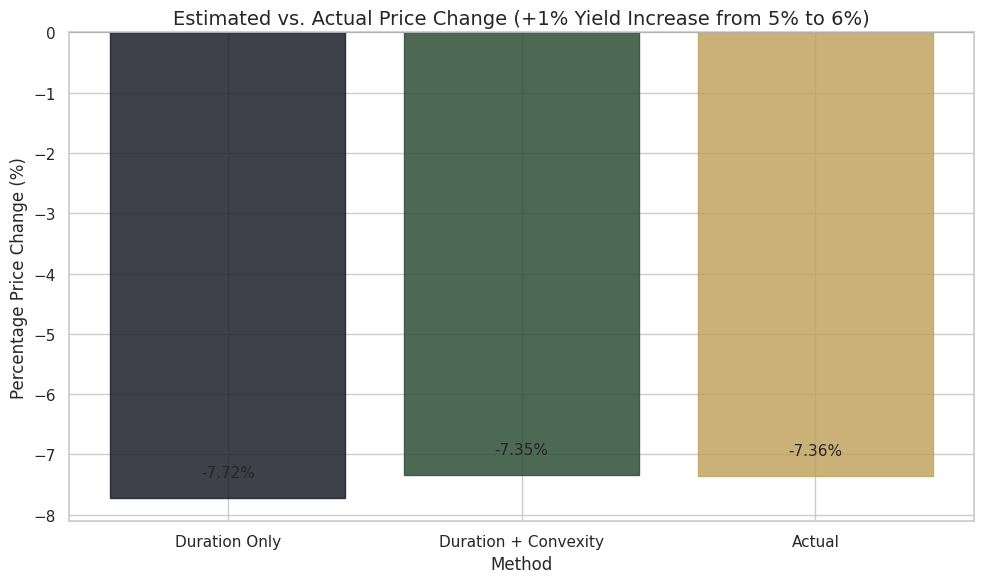

Macaulay Duration: 8.1078 years
Modified Duration: 7.7217
Convexity: 74.9977

Duration-only Estimate: -7.7217%
Duration + Convexity Estimate: -7.3467%
Actual Price Change (from discounting): -7.3601%

Duration-only Error: -0.3616%
Duration + Convexity Error: 0.0133%


In [11]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Set Seaborn theme and color palette
sns.set_theme(style="whitegrid")

# Bond parameters
face_value = 1000
coupon_rate = 0.05
maturity = 10
payment_frequency = 1

# Generate bond cash flows function
def bond_cash_flows(face_value, coupon_rate, maturity, frequency):
    periods = int(maturity * frequency)
    coupon = face_value * coupon_rate / frequency
    cash_flows = [coupon] * periods
    cash_flows[-1] += face_value  # Add face value to last period
    return pd.DataFrame({
        'Period': range(1, periods + 1),
        'Cash Flow': cash_flows
    })

# Bond price function
def bond_price(cash_flows, discount_rate):
    periods = cash_flows['Period']
    cash_flow_values = cash_flows['Cash Flow']
    return np.sum(cash_flow_values / (1 + discount_rate) ** periods)

# Calculate Macaulay duration
def macaulay_duration(cash_flows, discount_rate):
    periods = cash_flows['Period']
    cash_flow_values = cash_flows['Cash Flow']
    discounted_cash_flows = cash_flow_values / (1 + discount_rate) ** periods
    weighted_time = periods * discounted_cash_flows
    return np.sum(weighted_time) / np.sum(discounted_cash_flows)

# Calculate Modified Duration
def modified_duration(macaulay_duration, discount_rate):
    return macaulay_duration / (1 + discount_rate)

# Calculate convexity
def convexity(cash_flows, discount_rate):
    periods = cash_flows['Period']
    cash_flow_values = cash_flows['Cash Flow']
    pv_factors = (1 + discount_rate) ** (periods + 2)
    convexity_terms = cash_flow_values * periods * (periods + 1) / pv_factors
    price = bond_price(cash_flows, discount_rate)
    return np.sum(convexity_terms) / price

# Bond cash flows
cash_flows = bond_cash_flows(face_value, coupon_rate, maturity, payment_frequency)

# Baseline YTM and price
par_rate = 0.05
par_price = bond_price(cash_flows, par_rate)

# Duration and convexity at par
D_mac = macaulay_duration(cash_flows, par_rate)
D_mod = modified_duration(D_mac, par_rate)
C = convexity(cash_flows, par_rate)

# Yield change
new_yield = 0.06
delta_y = new_yield - par_rate

# Estimates
duration_only_change = -D_mod * delta_y * 100
convexity_correction = 0.5 * C * (delta_y ** 2) * 100
duration_convexity_change = duration_only_change + convexity_correction

# Actual price change
new_price = bond_price(cash_flows, new_yield)
actual_change = (new_price - par_price) / par_price * 100

# Error
duration_error = duration_only_change - actual_change
duration_convexity_error = duration_convexity_change - actual_change

# Plot
plt.figure(figsize=(10, 6))
methods = ["Duration Only", "Duration + Convexity", "Actual"]
values = [duration_only_change, duration_convexity_change, actual_change]

bars = plt.bar(methods, values, alpha=0.85)

for bar, color in zip(bars, old_money_palette):
    bar.set_color(color)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"{val:.2f}%", ha='center', va='bottom', fontsize=11)

plt.title("Estimated vs. Actual Price Change (+1% Yield Increase from 5% to 6%)", fontsize=14)
plt.ylabel("Percentage Price Change (%)", fontsize=12)
plt.xlabel("Method", fontsize=12)
plt.axhline(0, color="black", linewidth=0.7)
plt.tight_layout()
plt.show()

# Print summary for students
print(f"Macaulay Duration: {D_mac:.4f} years")
print(f"Modified Duration: {D_mod:.4f}")
print(f"Convexity: {C:.4f}")
print()
print(f"Duration-only Estimate: {duration_only_change:.4f}%")
print(f"Duration + Convexity Estimate: {duration_convexity_change:.4f}%")
print(f"Actual Price Change (from discounting): {actual_change:.4f}%")
print()
print(f"Duration-only Error: {duration_error:.4f}%")
print(f"Duration + Convexity Error: {duration_convexity_error:.4f}%")

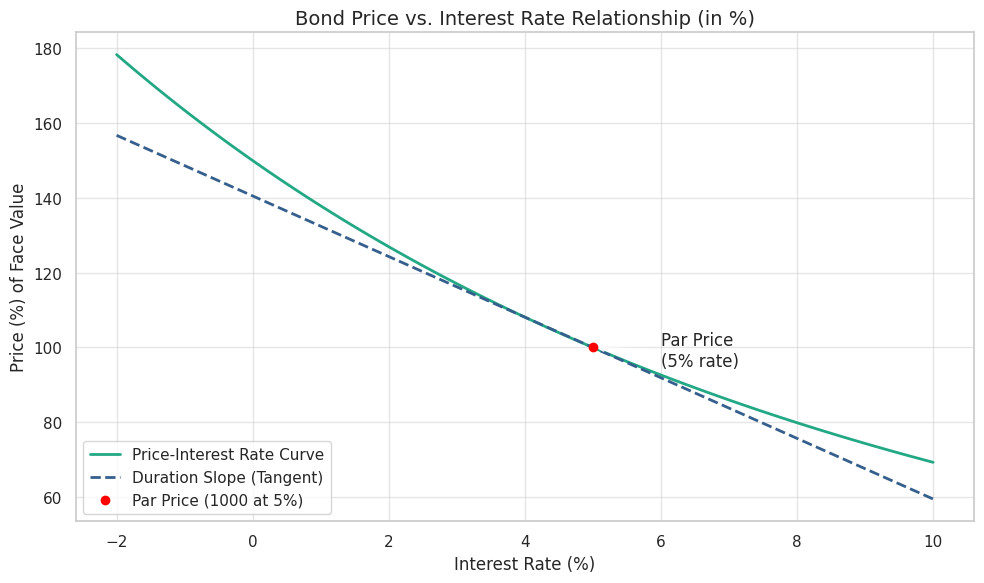

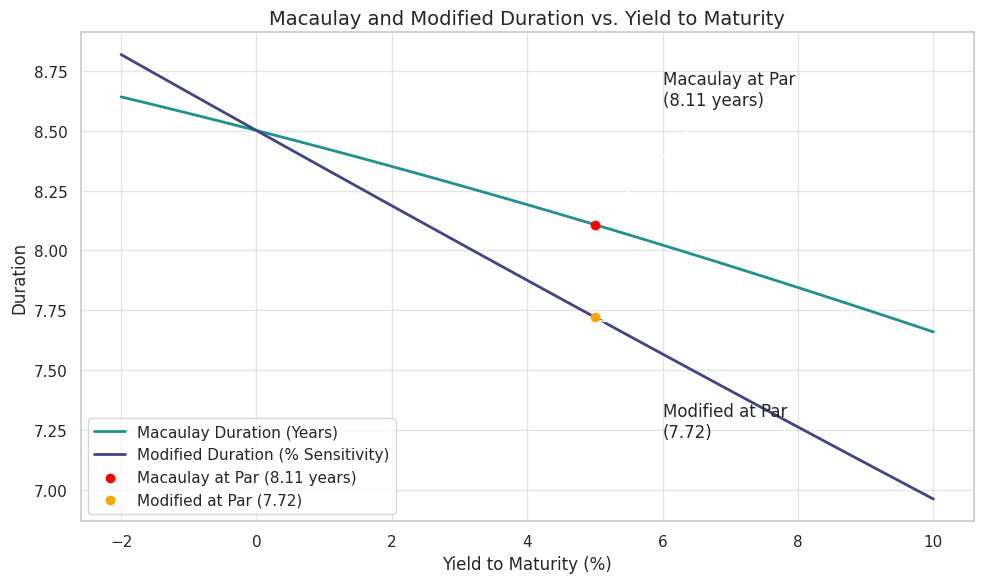

Macaulay Duration at Par (5% rate): 8.11 years
Modified Duration at Par (5% rate): 7.72


In [12]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Set Seaborn theme and color palette
sns.set_theme(style="whitegrid")
cmap = cm.viridis  # Use viridis colormap for smoother color transitions

# Bond parameters
face_value = 1000
coupon_rate = 0.05
maturity = 10
payment_frequency = 1

# Generate bond cash flows function
def bond_cash_flows(face_value, coupon_rate, maturity, frequency):
    periods = int(maturity * frequency)
    coupon = face_value * coupon_rate / frequency
    cash_flows = [coupon] * periods
    cash_flows[-1] += face_value  # Add face value to last period
    return pd.DataFrame({
        'Period': range(1, periods + 1),
        'Cash Flow': cash_flows
    })

# Bond price function
def bond_price(cash_flows, discount_rate):
    periods = cash_flows['Period']
    cash_flow_values = cash_flows['Cash Flow']
    return np.sum(cash_flow_values / (1 + discount_rate) ** periods)

# Calculate Macaulay duration
def macaulay_duration(cash_flows, discount_rate):
    periods = cash_flows['Period']
    cash_flow_values = cash_flows['Cash Flow']
    discounted_cash_flows = cash_flow_values / (1 + discount_rate) ** periods
    weighted_time = periods * discounted_cash_flows
    return np.sum(weighted_time) / np.sum(discounted_cash_flows)

# Calculate Modified duration
def modified_duration(macaulay_dur, discount_rate):
    return macaulay_dur / (1 + discount_rate)

# Generate bond cash flows for the bond
cash_flows = bond_cash_flows(face_value, coupon_rate, maturity, payment_frequency)

# Interest rates (from -2% to 10%)
interest_rates = np.linspace(-0.02, 0.10, 100)
prices = [bond_price(cash_flows, rate) for rate in interest_rates]

# Calculate the bond's price at par (5% rate)
par_rate = 0.05
par_price = bond_price(cash_flows, par_rate)

# Compute Macaulay and Modified durations at par
duration_at_par = macaulay_duration(cash_flows, par_rate)
mod_duration_at_par = modified_duration(duration_at_par, par_rate)

# Tangent line for duration slope at par price
tangent_line = par_price - duration_at_par * face_value * (interest_rates - par_rate)

# Plot the price-interest rate curve
plt.figure(figsize=(10, 6))

# Plot the bond price vs. interest rate curve (as percentage of face value)
sns.lineplot(x=interest_rates * 100, y=np.array(prices) / face_value * 100, 
             label="Price-Interest Rate Curve", color=cmap(0.6), linewidth=2)

# Plot the tangent line (duration slope) at par
sns.lineplot(x=interest_rates * 100, y=tangent_line / face_value * 100, 
             label="Duration Slope (Tangent)", color=cmap(0.3), linestyle="--", linewidth=2)

# Plot the par price and annotate
plt.scatter(par_rate * 100, par_price / face_value * 100, color="red", label="Par Price (1000 at 5%)", zorder=10)
plt.annotate("Par Price\n(5% rate)", xy=(par_rate * 100, par_price / face_value * 100), 
             xytext=(par_rate * 100 + 1, par_price / face_value * 100 - 5),
             arrowprops=dict(facecolor="black", arrowstyle="->"))

# Labels and Title
plt.title("Bond Price vs. Interest Rate Relationship (in %)", fontsize=14)
plt.xlabel("Interest Rate (%)", fontsize=12)
plt.ylabel("Price (%) of Face Value", fontsize=12)
plt.legend(loc="lower left")
plt.grid(alpha=0.5)

# Show the plot
plt.tight_layout()
plt.show()

# Compute Macaulay and Modified Durations across YTM range
macaulay_durations = [macaulay_duration(cash_flows, rate) for rate in interest_rates]
modified_durations = [modified_duration(md, rate) for md, rate in zip(macaulay_durations, interest_rates)]

# Plot Macaulay and Modified Durations vs. YTM
plt.figure(figsize=(10, 6))

# Plot Macaulay Duration (in years)
sns.lineplot(x=interest_rates * 100, y=macaulay_durations, label="Macaulay Duration (Years)", color=cmap(0.5), linewidth=2)

# Plot Modified Duration (dimensionless)
sns.lineplot(x=interest_rates * 100, y=modified_durations, label="Modified Duration (% Sensitivity)", color=cmap(0.2), linewidth=2)

# Highlight durations at par (5% rate)
plt.scatter(par_rate * 100, duration_at_par, color="red", label=f"Macaulay at Par ({duration_at_par:.2f} years)", zorder=10)
plt.scatter(par_rate * 100, mod_duration_at_par, color="orange", label=f"Modified at Par ({mod_duration_at_par:.2f})", zorder=10)

# Annotate Macaulay and Modified Durations at par
plt.annotate(f"Macaulay at Par\n({duration_at_par:.2f} years)", 
             xy=(par_rate * 100, duration_at_par), 
             xytext=(par_rate * 100 + 1, duration_at_par + 0.5),
             arrowprops=dict(facecolor="black", arrowstyle="->"))
plt.annotate(f"Modified at Par\n({mod_duration_at_par:.2f})", 
             xy=(par_rate * 100, mod_duration_at_par), 
             xytext=(par_rate * 100 + 1, mod_duration_at_par - 0.5),
             arrowprops=dict(facecolor="black", arrowstyle="->"))

# Labels and Title
plt.title("Macaulay and Modified Duration vs. Yield to Maturity", fontsize=14)
plt.xlabel("Yield to Maturity (%)", fontsize=12)
plt.ylabel("Duration", fontsize=12)
plt.legend(loc="lower left")
plt.grid(alpha=0.5)

# Show the plot
plt.tight_layout()
plt.show()

# Print summary for students
print(f"Macaulay Duration at Par (5% rate): {duration_at_par:.2f} years")
print(f"Modified Duration at Par (5% rate): {mod_duration_at_par:.2f}")

## 8. Yield Curve Construction in Fixed Income

In fixed income analysis, the **term structure of interest rates** is the foundation for pricing, hedging, and risk management of bonds and interest rate derivatives. Multiple yield curves exist: each serving different analytical and practical purposes.

In markets like the U.S. Treasury market:
- You observe (derive) actual **yield to maturity (YTM)** for bonds across different maturities
- These **observed YTMs** are interpreted directly as **par yields**

> This is how Bloomberg’s `YCGT0025 Index` (U.S. Treasury Par Yield Curve) is built:
> - **T-bills** for short maturities  
> - **Notes and bonds** for longer maturities  
> - Based on **on-the-run** securities (most recently issued)

We use public available data from an iShares U.S. Treasury Bond ETF (GOVT):
https://www.ishares.com/us/products/239468/ishares-u-s-treasury-bond-etf

You can download holdings data from the iShares website, see Detailed Holdings and Analytics https://www.ishares.com/us/products/239468/detailed-holdings-and-analytics

### 1. Observed Yield Curve (YTW/YTM)

The **observed yield curve** is built from **quoted yields** of traded bonds. For non-callable U.S. Treasury bonds, the **Yield to Maturity (YTM)** is the internal rate of return $y$ solving:

$$
P = \sum_{i=1}^{N} \frac{C}{(1 + y)^i} + \frac{F}{(1 + y)^N}
$$

Where:
- $P$ = market price  
- $C$ = semiannual coupon payment  
- $F$ = face value (usually 100)  
- $N$ = number of periods to maturity

This curve reflects market pricing but is **not arbitrage-free**. It is often **noisy** due to:
- Liquidity or credit premia  
- Discount/premium pricing  
- Market imperfections

Observed curves are typically **smoothed** using non-parametric regressions like **LOWESS** for visualization.

### Step 1 -  Import and Clean U.S. Treasury Bond Data

We begin by importing a dataset representing the holdings of a U.S. Treasury bond ETF.

Key cleaning steps:
> - Strip out headers and metadata
> - Convert all numerical fields properly
> - Parse `Maturity` and compute **Time to Maturity (TTM)**
> - Ensure all datatypes are numeric or datetime, avoiding object types## Step 1: Load and Clean Data

We start by loading the U.S. Treasury holdings data from an ETF and cleaning relevant numeric and date columns.


In [13]:
# ============================================================
# Load and clean iShares GOVT holdings CSV
# eval_date is inferred from downloaded iShares metadata
# ============================================================

import re
from io import StringIO

import pandas as pd
import requests


URL = (
    "https://www.ishares.com/ch/professionals/en/products/239468/"
    "ishares-us-treasury-bond-etf/1495092304805.ajax"
    "?fileType=csv&fileName=GOVT_holdings&dataType=fund"
)

REFERER = (
    "https://www.ishares.com/ch/professionals/en/products/239468/"
    "ishares-us-treasury-bond-etf"
)

headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept": "text/csv,application/csv,text/plain,*/*",
    "Referer": REFERER,
}


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def infer_ishares_eval_date(lines):
    """
    Infer holdings date from iShares metadata.

    Typical metadata line:
        Fund Holdings as of,14/May/2026

    Returns:
        pd.Timestamp
    """
    # Prefer explicit holdings-as-of metadata.
    for line in lines[:80]:
        if "Holdings as of" in line or "Fund Holdings as of" in line:
            match = re.search(r"\b\d{1,2}/[A-Za-z]{3}/\d{4}\b", line)
            if match:
                return pd.to_datetime(match.group(0), format="%d/%b/%Y")

    # Fallback: first date-looking value in metadata block before CSV header.
    for line in lines[:80]:
        match = re.search(r"\b\d{1,2}/[A-Za-z]{3}/\d{4}\b", line)
        if match:
            return pd.to_datetime(match.group(0), format="%d/%b/%Y")

    raise ValueError(
        "Could not infer iShares holdings evaluation date from metadata."
    )


def clean_number(x):
    """
    Robust iShares numeric cleaner.

    Handles:
    - commas
    - percent signs
    - currency symbols
    - currency labels such as USD
    - non-breaking spaces
    - unicode apostrophes
    - missing markers
    """
    if pd.isna(x):
        return pd.NA

    s = str(x).strip()

    if s in {"--", "", "nan", "None", "NaN"}:
        return pd.NA

    s = (
        s.replace("\ufeff", "")
         .replace("\xa0", "")
         .replace(",", "")
         .replace("%", "")
         .replace("’", "")
         .replace("'", "")
    )

    # Keep only digits, decimal point, and minus sign.
    s = re.sub(r"[^0-9.\-]", "", s)

    if s in {"", "-", ".", "-."}:
        return pd.NA

    try:
        return float(s)
    except ValueError:
        return pd.NA


# ------------------------------------------------------------
# Download
# ------------------------------------------------------------

resp = requests.get(URL, headers=headers, timeout=60)
resp.raise_for_status()

text = resp.content.decode("utf-8-sig", errors="replace")
lines = text.splitlines()

# Fail fast if iShares returned HTML, consent page, or blocked response.
if not any(
    line.lstrip("\ufeff ").startswith(("Name,", '"Name",'))
    for line in lines
):
    raise ValueError(
        "Could not find holdings CSV header. "
        "iShares may have returned HTML, blocked content, or changed the format.\n\n"
        f"First 1000 characters:\n{text[:1000]}"
    )

# Critical fix: eval_date now comes from the downloaded iShares file.
eval_date = infer_ishares_eval_date(lines)


# ------------------------------------------------------------
# Parse CSV block
# ------------------------------------------------------------

header_idx = next(
    i for i, line in enumerate(lines)
    if line.lstrip("\ufeff ").startswith(("Name,", '"Name",'))
)

csv_text = "\n".join(lines[header_idx:])
df_full = pd.read_csv(StringIO(csv_text))

df_full = df_full.dropna(how="all").copy()
df_full.columns = [str(c).strip() for c in df_full.columns]

# Remove repeated header rows if present.
if "Name" in df_full.columns:
    df_full = df_full[df_full["Name"].astype(str).str.strip() != "Name"].copy()


# ------------------------------------------------------------
# Clean numeric columns
# ------------------------------------------------------------

numeric_cols = [
    "Market Value",
    "Weight (%)",
    "Notional Value",
    "Par Value",
    "Price",
    "Coupon (%)",
    "Yield to Worst (%)",
    "Mod. Duration",
    "Real Duration",
    "Real YTM (%)",
    "YTM (%)",
    "FX Rate",
    "Duration",
]

for col in numeric_cols:
    if col in df_full.columns:
        df_full[col] = df_full[col].map(clean_number).astype("Float64")


# ------------------------------------------------------------
# Clean date columns
# ------------------------------------------------------------

for col in ["Maturity", "Accrual Date", "Effective Date"]:
    if col in df_full.columns:
        df_full[col] = pd.to_datetime(df_full[col], errors="coerce")

if {"Effective Date", "Accrual Date"}.issubset(df_full.columns):
    df_full["Effective Date"] = df_full["Effective Date"].fillna(df_full["Accrual Date"])


# ------------------------------------------------------------
# Remove cash-like rows
# ------------------------------------------------------------

if "Name" in df_full.columns:
    df_full = df_full[
        ~df_full["Name"]
        .astype(str)
        .str.contains(r"Cash|CSH FND", case=False, na=False)
    ].copy()


# ------------------------------------------------------------
# Derived analytics columns
# ------------------------------------------------------------

if "Maturity" in df_full.columns:
    df_full["Time to Maturity"] = (
        df_full["Maturity"] - eval_date
    ).dt.days / 365.25

if "Effective Date" in df_full.columns:
    df_full["Bond Age (Years)"] = (
        eval_date - df_full["Effective Date"]
    ).dt.days / 365.25

# Prefer Yield to Worst. Fallback to YTM.
if {"Yield to Worst (%)", "YTM (%)"}.issubset(df_full.columns):
    df_full["Analysis Yield (%)"] = (
        df_full["Yield to Worst (%)"].fillna(df_full["YTM (%)"])
    )
elif "Yield to Worst (%)" in df_full.columns:
    df_full["Analysis Yield (%)"] = df_full["Yield to Worst (%)"]
elif "YTM (%)" in df_full.columns:
    df_full["Analysis Yield (%)"] = df_full["YTM (%)"]


# ------------------------------------------------------------
# Analysis-ready filtered DataFrame
# ------------------------------------------------------------

required_cols = [
    c for c in [
        "Time to Maturity",
        "Analysis Yield (%)",
        "Weight (%)",
        "Effective Date",
    ]
    if c in df_full.columns
]

if required_cols:
    df_clean = df_full.dropna(subset=required_cols).copy()
else:
    df_clean = df_full.copy()

if "Time to Maturity" in df_clean.columns:
    df_clean = df_clean[df_clean["Time to Maturity"] > 0].copy()


# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

print("iShares holdings eval_date:", eval_date.date())
print("Rows in full cleaned holdings:", len(df_full))
print("Rows in analysis-ready holdings:", len(df_clean))

for col in ["Market Value", "Notional Value", "Par Value", "Weight (%)"]:
    if col in df_full.columns:
        print(
            f"{col}:",
            "non-null =", int(df_full[col].notna().sum()),
            "| null =", int(df_full[col].isna().sum()),
        )

if "Weight (%)" in df_clean.columns:
    print("Weight sum after analysis filter:", round(float(df_clean["Weight (%)"].sum()), 6))

if "Time to Maturity" in df_clean.columns:
    print(
        "Time to maturity range:",
        round(float(df_clean["Time to Maturity"].min()), 3),
        "to",
        round(float(df_clean["Time to Maturity"].max()), 3),
        "years",
    )

if "Analysis Yield (%)" in df_clean.columns:
    print(
        "Analysis yield range:",
        round(float(df_clean["Analysis Yield (%)"].min()), 3),
        "to",
        round(float(df_clean["Analysis Yield (%)"].max()), 3),
        "%",
    )


# ------------------------------------------------------------
# Preview
# ------------------------------------------------------------

preview_cols = [
    c for c in [
        "Name",
        "Market Value",
        "Notional Value",
        "Par Value",
        "Weight (%)",
        "Price",
        "Coupon (%)",
        "YTM (%)",
        "Yield to Worst (%)",
        "Analysis Yield (%)",
        "Maturity",
        "Effective Date",
        "Time to Maturity",
        "Bond Age (Years)",
    ]
    if c in df_clean.columns
]

df_clean[preview_cols].head()

iShares holdings eval_date: 2026-05-15
Rows in full cleaned holdings: 219
Rows in analysis-ready holdings: 209
Market Value: non-null = 218 | null = 1
Notional Value: non-null = 218 | null = 1
Par Value: non-null = 218 | null = 1
Weight (%): non-null = 218 | null = 1
Weight sum after analysis filter: 94.96
Time to maturity range: 0.756 to 29.755 years
Analysis yield range: 3.8 to 5.35 %


,Name,Market Value,Notional Value,Par Value,Weight (%),Price,Coupon (%),YTM (%),Yield to Worst (%),Analysis Yield (%),Maturity,Effective Date,Time to Maturity,Bond Age (Years)
0,TREASURY NOTE,2151844234.0,2151844234.34,2510925800.0,5.26,85.7,1.38,4.32,4.32,4.32,2031-11-15,2021-11-15,5.503080,4.495551
1,TREASURY NOTE,1211972493.0,1211972493.4,1252724000.0,2.96,96.1,2.63,4.14,4.14,4.14,2029-02-15,2019-02-15,2.757016,7.244353
2,TREASURY NOTE,1079472346.0,1079472346.27,1096341800.0,2.64,97.79,2.75,4.07,4.07,4.07,2028-02-15,2018-02-15,1.754962,8.243669
3,TREASURY NOTE,849850298.0,849850298.39,870350800.0,2.08,97.64,3.13,4.13,4.13,4.13,2028-11-15,2018-11-15,2.505133,7.496235
4,TREASURY NOTE,658352831.0,658352831.31,673883500.0,1.61,97.7,2.88,4.09,4.09,4.09,2028-05-15,2018-05-15,2.001369,8.000000


### Step 2 - Plot The Observed Yield Curve

We visualize `Yield to Worst (%)` against `Time to Maturity`.  
This empirical curve serves as a noisy version of the par yield curve and exhibits jumps and local irregularities.

> Use **YTW** vs. **Time to Maturity**

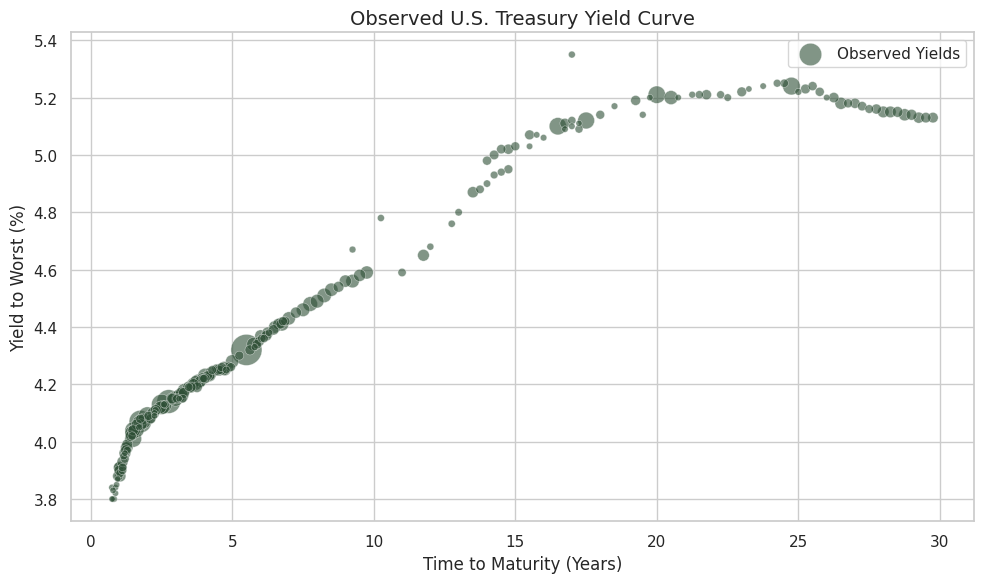

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style and size
sns.set_theme(style="whitegrid", rc={"figure.figsize": (10, 6)})

# Plot
sns.scatterplot(
    data=df_full,
    x="Time to Maturity",
    y="Yield to Worst (%)",
    size=df_full["Weight (%)"] * 100,
    sizes=(20, 500),
    legend=False,
    alpha=0.6,
    color=old_money_palette[1],
    label="Observed Yields"
)

# Labels and legend
plt.title("Observed U.S. Treasury Yield Curve", fontsize=14)
plt.xlabel("Time to Maturity (Years)", fontsize=12)
plt.ylabel("Yield to Worst (%)", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

### Why Is There a Gap in the U.S. Yield Curve Between Intermediate and Long Maturities?

The visible gap in the U.S. Treasury yield curve — particularly between the 10-year and 15-year maturities — is a result of both **historical issuance policies** and **market structure**.

Timeline of Key U.S. Treasury Decisions
| Year | Event                           |
|------|---------------------------------|
| 1986 | 20-year bonds discontinued      |
| 2001 | 30-year bonds suspended         |
| 2006 | 30-year bonds reintroduced      |
| 2020 | 20-year bonds reintroduced      |

#### The Math Behind the Gap:
- A long period with **no 20Y issuance** between **2006 and 2020**
- Bonds issued in 2006 with a 30-year maturity are now drifting into the **11–14Y range**.
- As a result, the 10–15Y segment is populated by **old off-the-run 30Y bonds** that are **illiquid and rarely used for pricing**.
- Lack of benchmark bonds maturing in that segment today
- This creates a **natural gap** in observed yields, even though theoretical models interpolate across it.

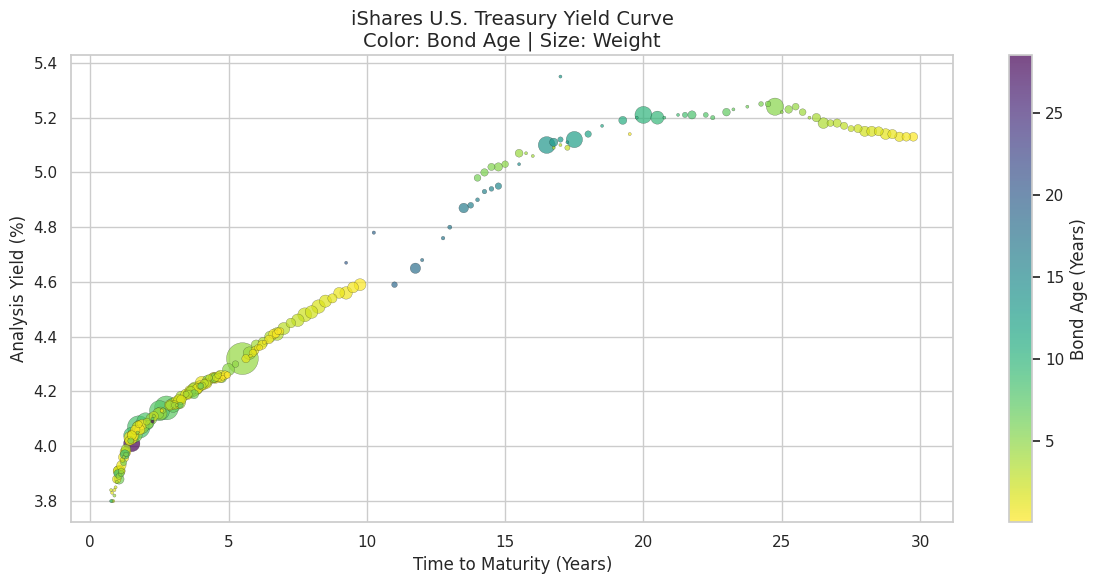

count    209.000000
mean       9.148155
std        8.692905
min        0.755647
25%        2.297057
50%        4.876112
75%       15.000684
max       29.754962
Name: Time to Maturity, dtype: float64


In [15]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from matplotlib import cm

# Use Analysis Yield if available; otherwise fall back to Yield to Worst.
yield_col = (
    "Analysis Yield (%)"
    if "Analysis Yield (%)" in df_full.columns
    else "Yield to Worst (%)"
)

required_plot_cols = [
    yield_col,
    "Time to Maturity",
    "Weight (%)",
    "Bond Age (Years)",
]

missing_cols = [c for c in required_plot_cols if c not in df_full.columns]

if missing_cols:
    raise KeyError(f"Missing required columns for plot: {missing_cols}")

# Drop missing values from ALL columns used in x, y, color, and size.
df_plot = df_full.dropna(subset=required_plot_cols).copy()

# Remove invalid values.
df_plot = df_plot[
    (df_plot["Time to Maturity"] > 0)
    & (df_plot["Weight (%)"] >= 0)
    & (df_plot["Bond Age (Years)"] >= 0)
].copy()

if df_plot.empty:
    raise ValueError("No valid rows left for plotting after filtering.")

# Convert to numpy arrays.
# This avoids pandas nullable Float64 dtype issues in matplotlib.
x = df_plot["Time to Maturity"].astype(float).to_numpy()
y = df_plot[yield_col].astype(float).to_numpy()
age = df_plot["Bond Age (Years)"].astype(float).to_numpy()

# Bubble size must be scalar or same length as x and y.
size = (df_plot["Weight (%)"].astype(float).to_numpy() * 100)

# Avoid invisible zero-size bubbles.
size = np.clip(size, 5, None)

if not (len(x) == len(y) == len(age) == len(size)):
    raise ValueError(
        f"Length mismatch: x={len(x)}, y={len(y)}, age={len(age)}, size={len(size)}"
    )

# Handle constant age case.
if np.nanmin(age) == np.nanmax(age):
    norm = mcolors.Normalize(vmin=np.nanmin(age) - 1, vmax=np.nanmax(age) + 1)
else:
    norm = mcolors.Normalize(vmin=np.nanmin(age), vmax=np.nanmax(age))

# "mako_r" is not available in standard matplotlib unless seaborn/cmocean registered it.
# Use a standard matplotlib colormap.
cmap = plt.colormaps.get_cmap("viridis_r")

fig, ax = plt.subplots(figsize=(12, 6))

scatter = ax.scatter(
    x,
    y,
    c=age,
    cmap=cmap,
    norm=norm,
    s=size,
    alpha=0.7,
    edgecolor="k",
    linewidth=0.2,
)

ax.set_title(
    "iShares U.S. Treasury Yield Curve\nColor: Bond Age | Size: Weight",
    fontsize=14,
)
ax.set_xlabel("Time to Maturity (Years)")
ax.set_ylabel(yield_col)
ax.grid(True)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Bond Age (Years)")

plt.tight_layout()
plt.show()

print(df_plot["Time to Maturity"].describe())

**Try Quadratic Interpolation (But Not Ideal...)**

Quadratic interpolation can create artificial spikes when the yield curve has kinks or irregular spacing.

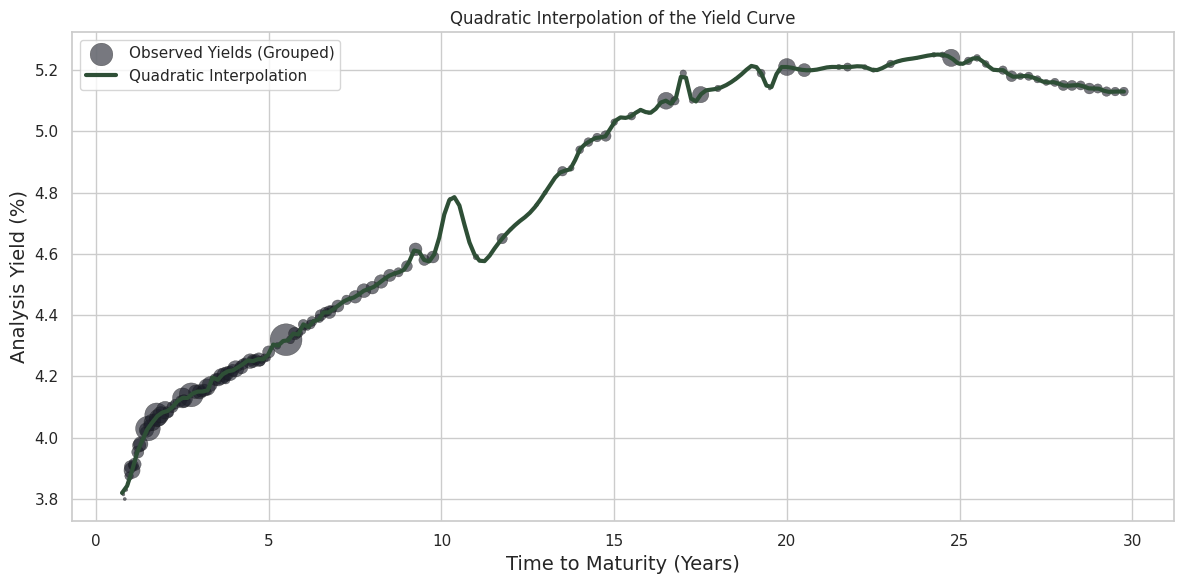

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Use Analysis Yield if available; otherwise fall back to Yield to Worst.
yield_col = (
    "Analysis Yield (%)"
    if "Analysis Yield (%)" in df_full.columns
    else "Yield to Worst (%)"
)

required_cols = [
    yield_col,
    "Time to Maturity",
    "Weight (%)",
]

missing_cols = [c for c in required_cols if c not in df_full.columns]

if missing_cols:
    raise KeyError(f"Missing required columns for interpolation plot: {missing_cols}")

# Clean plotting base.
df_plot = df_full.dropna(subset=required_cols).copy()

df_plot = df_plot[
    (df_plot["Time to Maturity"] > 0)
    & (df_plot["Weight (%)"] >= 0)
].copy()

if df_plot.empty:
    raise ValueError("No valid rows left after filtering.")

# Convert to real float dtype before groupby/interpolation.
df_plot["Time to Maturity"] = df_plot["Time to Maturity"].astype(float)
df_plot[yield_col] = df_plot[yield_col].astype(float)
df_plot["Weight (%)"] = df_plot["Weight (%)"].astype(float)

# Group duplicate maturities.
df_grouped = (
    df_plot
    .groupby("Time to Maturity", as_index=False)
    .agg({
        yield_col: "mean",
        "Weight (%)": "sum",
    })
    .sort_values("Time to Maturity")
)

x_vals = df_grouped["Time to Maturity"].to_numpy(dtype=float)
y_vals = df_grouped[yield_col].to_numpy(dtype=float)
sizes = (df_grouped["Weight (%)"].to_numpy(dtype=float) * 100)

# Avoid zero-size markers.
sizes = np.clip(sizes, 5, None)

if not (len(x_vals) == len(y_vals) == len(sizes)):
    raise ValueError(
        f"Length mismatch: x={len(x_vals)}, y={len(y_vals)}, sizes={len(sizes)}"
    )

if len(x_vals) < 2:
    raise ValueError("Need at least 2 unique maturities for interpolation.")

# Quadratic interpolation needs at least 3 points.
interp_kind = "quadratic" if len(x_vals) >= 3 else "linear"

interp_func = interp1d(
    x_vals,
    y_vals,
    kind=interp_kind,
    fill_value="extrapolate",
    bounds_error=False,
)

grid_times = np.linspace(float(x_vals.min()), float(x_vals.max()), 200)
grid_yields = interp_func(grid_times)

# Plot
plt.figure(figsize=(12, 6))

plt.scatter(
    x_vals,
    y_vals,
    s=sizes,
    color="#1C1F2A",
    alpha=0.6,
    edgecolor="k",
    linewidth=0.3,
    label="Observed Yields (Grouped)",
)

plt.plot(
    grid_times,
    grid_yields,
    color="#2E4F36",
    linewidth=3,
    label=f"{interp_kind.title()} Interpolation",
)

plt.title(f"{interp_kind.title()} Interpolation of the Yield Curve")
plt.xlabel("Time to Maturity (Years)", fontsize=14)
plt.ylabel(yield_col, fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

#### LOWESS Smoothing for a Clean Curve
LOWESS is a smoother, not an interpolator. 
But we can still interpolate from the fitted curve to query any tenor. 
We introduce - `threshold_age` to filter out bonds that are too old.

In [17]:
# ============================================================
# Bond Universe Filters
#
# Input:
#   df_full
#
# Output:
#   df_filter      = cleaned base universe used for classification
#   df_strips      = Treasury STRIPs
#   df_offtherun   = old non-STRIP coupon bonds
#   df_actives     = active non-STRIP coupon bonds
#
# User-adjustable filter settings are collected in FILTER_CONFIG.
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1) User-visible filter settings
# ------------------------------------------------------------

FILTER_CONFIG = {
    # Maximum bond age for "active" bonds.
    # Bonds older than this are classified as off-the-run.
    "max_active_bond_age_years": 99,

    # Minimum remaining maturity.
    # Useful to remove near-maturity bonds where yields/prices can be noisy.
    "min_time_to_maturity_years": 0.10,

    # Maximum remaining maturity.
    # Use None to automatically use the maximum available maturity.
    "max_time_to_maturity_years": None,

    # Minimum par value.
    # Use this to remove tiny residual positions.
    "min_par_value": 1,

    # Exclude cash-like rows from the base universe.
    "exclude_cash": True,

    # Classify STRIPs separately.
    "separate_strips": True,

    # Optional sampling fraction for plotting / speed.
    # Use 1.0 for all rows. Use 0.10 for 10%.
    "sample_fraction": 1.0,

    # Random seed for reproducible sampling.
    "random_state": 42,
}


# ------------------------------------------------------------
# 2) Filtering function
# ------------------------------------------------------------

def classify_bond_universe(df_full, config):
    """
    Classify iShares Treasury holdings into:
      - STRIPs
      - off-the-run coupon bonds
      - active coupon bonds

    This function avoids boolean masks with NA values and prints
    row-count diagnostics at each step.
    """

    required_cols = [
        "Name",
        "Bond Age (Years)",
        "Time to Maturity",
        "Par Value",
    ]

    missing_cols = [c for c in required_cols if c not in df_full.columns]

    if missing_cols:
        raise KeyError(f"Missing required columns for filtering: {missing_cols}")

    df = df_full.copy()

    # Defensive type conversion.
    df["Name"] = df["Name"].astype(str)

    for col in ["Bond Age (Years)", "Time to Maturity", "Par Value"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    rows_initial = len(df)

    # Remove rows missing fields used for classification.
    df = df.dropna(subset=required_cols).copy()
    rows_after_required_dropna = len(df)

    # Remove invalid numeric values.
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=required_cols).copy()

    df = df[
        (df["Bond Age (Years)"] >= 0)
        & (df["Time to Maturity"] > 0)
        & (df["Par Value"] >= 0)
    ].copy()

    rows_after_numeric_filters = len(df)

    # Optional cash exclusion.
    if config.get("exclude_cash", True):
        is_cash = df["Name"].str.contains(
            r"Cash|CSH FND",
            case=False,
            na=False,
        )
        df = df[~is_cash].copy()

    rows_after_cash_filter = len(df)

    # Time-to-maturity filter.
    min_ttm = config.get("min_time_to_maturity_years", 0.0)
    max_ttm = config.get("max_time_to_maturity_years", None)

    if max_ttm is None:
        max_ttm = float(df["Time to Maturity"].max())

    df = df[
        (df["Time to Maturity"] >= float(min_ttm))
        & (df["Time to Maturity"] <= float(max_ttm))
    ].copy()

    rows_after_maturity_filter = len(df)

    # Optional sampling.
    sample_fraction = float(config.get("sample_fraction", 1.0))

    if sample_fraction <= 0 or sample_fraction > 1:
        raise ValueError("sample_fraction must be in the interval (0, 1].")

    if sample_fraction < 1.0:
        df = df.sample(
            frac=sample_fraction,
            random_state=config.get("random_state", 42),
        ).copy()

    rows_after_sampling = len(df)

    # Classification masks.
    is_strip = df["Name"].str.contains(
        "STRIP",
        case=False,
        na=False,
    )

    max_age = float(config.get("max_active_bond_age_years", 99))
    min_par = float(config.get("min_par_value", 1))

    df_strips = df[is_strip].copy()

    df_offtherun = df[
        (~is_strip)
        & (df["Bond Age (Years)"] > max_age)
    ].copy()

    df_actives = df[
        (~is_strip)
        & (df["Bond Age (Years)"] <= max_age)
        & (df["Par Value"] > min_par)
    ].copy()

    diagnostics = pd.DataFrame(
        [
            {"Step": "Initial rows", "Rows": rows_initial},
            {"Step": "After required dropna", "Rows": rows_after_required_dropna},
            {"Step": "After numeric validity filters", "Rows": rows_after_numeric_filters},
            {"Step": "After cash filter", "Rows": rows_after_cash_filter},
            {"Step": "After maturity filter", "Rows": rows_after_maturity_filter},
            {"Step": "After sampling", "Rows": rows_after_sampling},
            {"Step": "STRIPs", "Rows": len(df_strips)},
            {"Step": "Off-the-run", "Rows": len(df_offtherun)},
            {"Step": "Actives", "Rows": len(df_actives)},
            {
                "Step": "Classified total",
                "Rows": len(df_strips) + len(df_offtherun) + len(df_actives),
            },
        ]
    )

    effective_config = dict(config)
    effective_config["max_time_to_maturity_years_used"] = max_ttm

    return df, df_strips, df_offtherun, df_actives, diagnostics, effective_config


# ------------------------------------------------------------
# 3) Run filters
# ------------------------------------------------------------

df_filter, df_strips, df_offtherun, df_actives, filter_diagnostics, effective_filter_config = (
    classify_bond_universe(df_full, FILTER_CONFIG)
)


# ------------------------------------------------------------
# 4) Display filter settings and diagnostics
# ------------------------------------------------------------

print("Filter settings used:")
display(pd.Series(effective_filter_config).to_frame("Value"))

print("Filter diagnostics:")
display(filter_diagnostics)


# ------------------------------------------------------------
# 5) Quick sanity checks
# ------------------------------------------------------------

classified_total = len(df_strips) + len(df_offtherun) + len(df_actives)

print("Rows in base filter universe:", len(df_filter))
print("Rows classified:", classified_total)

if classified_total != len(df_filter):
    print(
        "Warning: classified_total != df_filter rows. "
        "Check classification masks."
    )

print("STRIPs:", len(df_strips))
print("Off-the-run:", len(df_offtherun))
print("Actives:", len(df_actives))

Filter settings used:


,Value
max_active_bond_age_years,99
min_time_to_maturity_years,0.1
max_time_to_maturity_years,None
min_par_value,1
exclude_cash,True
separate_strips,True
sample_fraction,1.0
random_state,42
max_time_to_maturity_years_used,29.754962


Filter diagnostics:


,Step,Rows
0,Initial rows,219
1,After required dropna,209
2,After numeric validity filters,209
3,After cash filter,209
4,After maturity filter,209
5,After sampling,209
6,STRIPs,3
7,Off-the-run,0
8,Actives,206
9,Classified total,209


Rows in base filter universe: 209
Rows classified: 209
STRIPs: 3
Off-the-run: 0
Actives: 206


In [18]:
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.interpolate import interp1d

#LOWESS Function
def fit_lowess_curve(df, x_col="Time to Maturity", y_col="Yield to Worst (%)", frac=0.10):
    mask = df[x_col].notna() & df[y_col].notna()
    x = df.loc[mask, x_col].values
    y = df.loc[mask, y_col].values / 100
    result = lowess(endog=y, exog=x, frac=frac, return_sorted=True)
    tenor, yields = result[:, 0], result[:, 1]
    return tenor, yields * 100

data_frac = 0.05

# LOWESS Fit
lowess_times, lowess_yields = fit_lowess_curve(df_actives, frac=data_frac)

In [19]:
print("df_full:", len(df_full))
print("df_actives:", len(df_actives))
print("df_offtherun:", len(df_offtherun))
print("df_strips:", len(df_strips))
print("total plotted:", len(df_actives) + len(df_offtherun) + len(df_strips))

for col in [
    "Name",
    "Time to Maturity",
    "Analysis Yield (%)",
    "Yield to Worst (%)",
    "Weight (%)",
    "Par Value",
    "Bond Age (Years)",
]:
    if col in df_full.columns:
        print(col, "non-null:", df_full[col].notna().sum(), "null:", df_full[col].isna().sum())

df_full: 219
df_actives: 206
df_offtherun: 0
df_strips: 3
total plotted: 209
Name non-null: 219 null: 0
Time to Maturity non-null: 209 null: 10
Analysis Yield (%) non-null: 218 null: 1
Yield to Worst (%) non-null: 218 null: 1
Weight (%) non-null: 218 null: 1
Par Value non-null: 218 null: 1
Bond Age (Years) non-null: 210 null: 9


usable rows: 209
active rows: 183
off-the-run rows: 23
STRIP rows: 3
classified total: 209


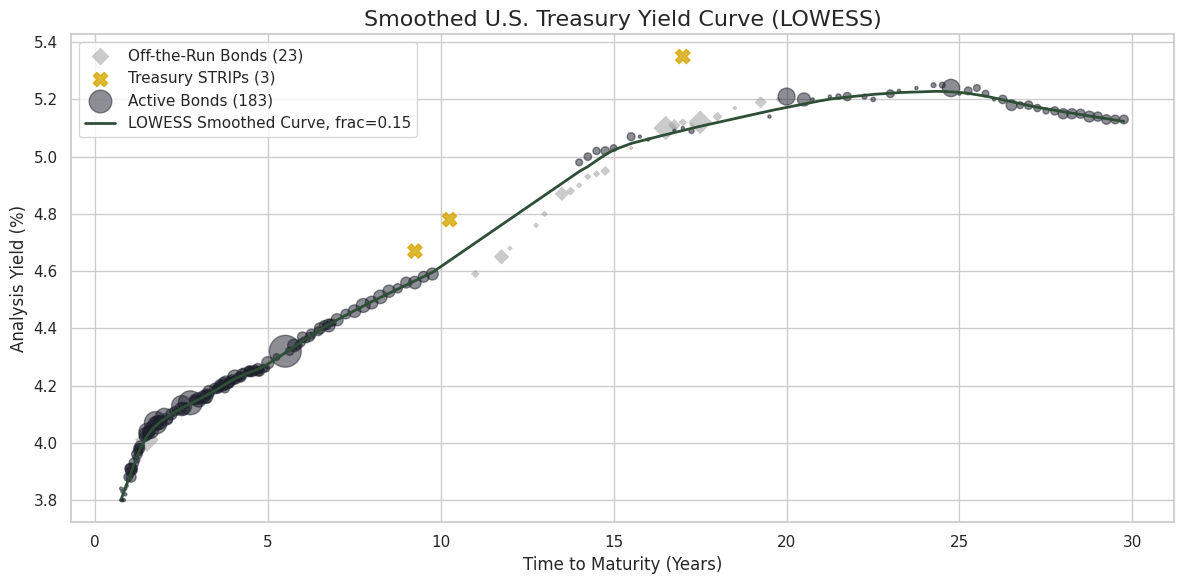

In [20]:
# ------------------------------------------------------------
# Classify all usable bonds for plotting + LOWESS curve
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

try:
    from statsmodels.nonparametric.smoothers_lowess import lowess
except ImportError:
    raise ImportError(
        "statsmodels is required for LOWESS. Install with: pip install statsmodels"
    )


# ------------------------------------------------------------
# Select yield column
# ------------------------------------------------------------

yield_col = (
    "Analysis Yield (%)"
    if "Analysis Yield (%)" in df_full.columns
    else "Yield to Worst (%)"
)


# ------------------------------------------------------------
# Build usable plotting DataFrame
# ------------------------------------------------------------

required_cols = [
    "Name",
    "Time to Maturity",
    yield_col,
    "Weight (%)",
]

missing_cols = [c for c in required_cols if c not in df_full.columns]

if missing_cols:
    raise KeyError(f"Missing required columns: {missing_cols}")

df_plot_all = df_full.dropna(subset=required_cols).copy()

for col in ["Time to Maturity", yield_col, "Weight (%)"]:
    df_plot_all[col] = pd.to_numeric(df_plot_all[col], errors="coerce")

df_plot_all = (
    df_plot_all
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["Time to Maturity", yield_col, "Weight (%)"])
    .copy()
)

df_plot_all = df_plot_all[
    (df_plot_all["Time to Maturity"] > 0)
    & (df_plot_all["Weight (%)"] >= 0)
].copy()

if df_plot_all.empty:
    raise ValueError("No usable rows left for plotting.")


# ------------------------------------------------------------
# Classify bonds
# ------------------------------------------------------------

is_strip = df_plot_all["Name"].astype(str).str.contains(
    "STRIP",
    case=False,
    na=False,
)

# Bond age may be missing for some rows. Do not let that remove bonds.
if "Bond Age (Years)" in df_plot_all.columns:
    df_plot_all["Bond Age (Years)"] = pd.to_numeric(
        df_plot_all["Bond Age (Years)"],
        errors="coerce",
    )
else:
    df_plot_all["Bond Age (Years)"] = np.nan

# Practical off-the-run definition for plotting:
# older than 10 years since issue, not STRIP.
off_the_run_age_threshold = 10

is_offtherun = (
    df_plot_all["Bond Age (Years)"].notna()
    & (df_plot_all["Bond Age (Years)"] > off_the_run_age_threshold)
    & (~is_strip)
)

is_active = (~is_strip) & (~is_offtherun)

df_strips = df_plot_all[is_strip].copy()
df_offtherun = df_plot_all[is_offtherun].copy()
df_actives = df_plot_all[is_active].copy()

print("usable rows:", len(df_plot_all))
print("active rows:", len(df_actives))
print("off-the-run rows:", len(df_offtherun))
print("STRIP rows:", len(df_strips))
print("classified total:", len(df_actives) + len(df_offtherun) + len(df_strips))


# ------------------------------------------------------------
# LOWESS input
# ------------------------------------------------------------

# Use active coupon bonds for the smoothed Treasury curve.
df_lowess_base = df_actives.dropna(
    subset=["Time to Maturity", yield_col, "Weight (%)"]
).copy()

df_lowess_base["Time to Maturity"] = pd.to_numeric(
    df_lowess_base["Time to Maturity"],
    errors="coerce",
)

df_lowess_base[yield_col] = pd.to_numeric(
    df_lowess_base[yield_col],
    errors="coerce",
)

df_lowess_base["Weight (%)"] = pd.to_numeric(
    df_lowess_base["Weight (%)"],
    errors="coerce",
)

df_lowess_base = (
    df_lowess_base
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["Time to Maturity", yield_col, "Weight (%)"])
    .copy()
)

df_lowess_base = df_lowess_base[
    (df_lowess_base["Time to Maturity"] > 0)
    & (df_lowess_base["Weight (%)"] >= 0)
].copy()

if len(df_lowess_base) < 3:
    raise ValueError(
        f"Need at least 3 active bonds for LOWESS. Found {len(df_lowess_base)}."
    )

# Group duplicate maturities to prevent duplicated x-values from distorting LOWESS/interpolation.
df_lowess_grouped = (
    df_lowess_base
    .groupby("Time to Maturity", as_index=False)
    .agg({
        yield_col: "mean",
        "Weight (%)": "sum",
    })
    .sort_values("Time to Maturity")
)

if len(df_lowess_grouped) < 3:
    raise ValueError(
        f"Need at least 3 unique maturities for LOWESS. Found {len(df_lowess_grouped)}."
    )

x_lowess = df_lowess_grouped["Time to Maturity"].to_numpy(dtype=float)
y_lowess = df_lowess_grouped[yield_col].to_numpy(dtype=float)

# Fraction controls smoothness:
# lower = more local / wiggly
# higher = smoother
lowess_frac = 0.15

lowess_result = lowess(
    endog=y_lowess,
    exog=x_lowess,
    frac=lowess_frac,
    it=0,
    return_sorted=True,
)

df_lowess = pd.DataFrame(
    lowess_result,
    columns=["Time", "Yield"],
)

df_lowess = (
    df_lowess
    .dropna(subset=["Time", "Yield"])
    .drop_duplicates(subset="Time")
    .sort_values("Time")
)

if len(df_lowess) < 2:
    raise ValueError("LOWESS output has fewer than 2 valid points. Cannot interpolate.")


# ------------------------------------------------------------
# Interpolate LOWESS curve on dense grid
# ------------------------------------------------------------

grid_x = np.linspace(
    float(df_lowess["Time"].min()),
    float(df_lowess["Time"].max()),
    1000,
)

lowess_interp = interp1d(
    df_lowess["Time"].to_numpy(dtype=float),
    df_lowess["Yield"].to_numpy(dtype=float),
    kind="linear",
    bounds_error=False,
    fill_value="extrapolate",
)

smoothed_yields = lowess_interp(grid_x)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

if not df_offtherun.empty:
    plt.scatter(
        df_offtherun["Time to Maturity"].to_numpy(dtype=float),
        df_offtherun[yield_col].to_numpy(dtype=float),
        marker="D",
        s=np.clip(df_offtherun["Weight (%)"].to_numpy(dtype=float) * 100, 5, None),
        alpha=0.5,
        label=f"Off-the-Run Bonds ({len(df_offtherun)})",
        color="#999999",
        edgecolor="k",
        linewidth=0.1,
    )

if not df_strips.empty:
    plt.scatter(
        df_strips["Time to Maturity"].to_numpy(dtype=float),
        df_strips[yield_col].to_numpy(dtype=float),
        marker="X",
        s=np.clip(df_strips["Weight (%)"].to_numpy(dtype=float) * 100, 105, None),
        alpha=0.8,
        label=f"Treasury STRIPs ({len(df_strips)})",
        color="#D6A600",
    )

if not df_actives.empty:
    plt.scatter(
        df_actives["Time to Maturity"].to_numpy(dtype=float),
        df_actives[yield_col].to_numpy(dtype=float),
        s=np.clip(df_actives["Weight (%)"].to_numpy(dtype=float) * 100, 5, None),
        alpha=0.5,
        label=f"Active Bonds ({len(df_actives)})",
        color="#1C1F2A",
    )

plt.plot(
    grid_x,
    smoothed_yields,
    label=f"LOWESS Smoothed Curve, frac={lowess_frac}",
    color="#2E4F36",
    linewidth=2,
)


# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

plt.title("Smoothed U.S. Treasury Yield Curve (LOWESS)", fontsize=16)
plt.xlabel("Time to Maturity (Years)", fontsize=12)
plt.ylabel(yield_col, fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

**Now you can query any tenor!**

In [21]:
from scipy.interpolate import interp1d

def get_yield(tenor, x_vals, y_vals):
    """
    Returns interpolated yield for a given tenor using linear interpolation
    over a LOWESS-smoothed yield curve.

    Parameters:
        tenor (float): Time to maturity in years
        x_vals (array): LOWESS time-to-maturity points
        y_vals (array): LOWESS smoothed yields (%)

    Returns:
        float: Interpolated yield in percentage (%)
    """
    interp_func = interp1d(x_vals, y_vals, kind='linear', fill_value="extrapolate")
    return float(interp_func(tenor))

tenor = 30 #in fraction of years

yield_at_tenor = get_yield(tenor, grid_x, smoothed_yields)
print(f"Yield at {tenor} years: {yield_at_tenor:.2f}%")

Yield at 30 years: 5.12%


# Bootstrapping a U.S. Treasury Yield Curve Using QuantLib

#### What Is Bootstrapping?

**Bootstrapping** is the process of constructing a zero-coupon (spot rate) yield curve from the prices of coupon-bearing bonds. We solve for the set of **spot rates** that exactly reproduce observed bond prices. This yields a consistent, arbitrage-free term structure for pricing and risk analysis.

#### Key Concepts

| Concept                | Description                                                   |
|------------------------|---------------------------------------------------------------|
| **Par Yield**          | Coupon rate making a bond price exactly 100                   |
| **Spot Rate**          | Yield on a zero-coupon bond maturing at a specific time       |
| **Discount Factor**    | Present value of one unit of currency at a future date        |
| **Semiannual Coupons** | U.S. Treasuries typically pay interest twice per year         |

#### Bootstrapping a Yield Curve: Step-by-Step

The process:

1. Input observed Treasury prices and coupon rates.
2. Solve recursively for discount factors and spot rates.
3. Fit a smooth zero-coupon (spot) curve using QuantLib.
4. Evaluate curve fit using **duration-weighted pricing error**.


#### Stage 1: Synthetic Example (Semiannual Bootstrapping)

We use synthetic bonds with semiannual coupons and maturities at 1, 2, and 3 years:

| Maturity (Years) | Coupon (%) | Price |
|------------------|------------|-------|
| 1                | 2.00       | 98.00 |
| 2                | 2.50       | 97.50 |
| 3                | 3.00       | 98.20 |

**Step 1: 6-Month Spot Rate $z_{0.5}$**

Bond 1 pays:
- $1.00$ at $t = 0.5$
- $101.00$ at $t = 1.0$

We assume $z_{0.5} \approx 0.0202$, so:

$$
D(0.5) = \frac{1}{1 + z_{0.5}} = \frac{1}{1.0202} \approx 0.9802
$$

**Step 2: 1-Year Spot Rate $z_1$**

Using:

$$
98.00 = 1.00 \cdot D(0.5) + 101.00 \cdot D(1.0)
$$

Solve:

$$
D(1.0) = \frac{98.00 - 1.00 \cdot 0.9802}{101.00} \approx 0.9606
$$

**Step 3: 1.5-Year and 2-Year Spot Rates**

Bond 2 pays:
- $1.25$ at $t = 0.5$, $1.0$, $1.5$
- $101.25$ at $t = 2.0$

Known contributions:

$$
\text{CF}_{\text{known}} = 1.25 \cdot D(0.5) + 1.25 \cdot D(1.0) \approx 2.43
$$

Solve:

$$
97.50 = \text{CF}_{\text{known}} + 1.25 \cdot D(1.5) + 101.25 \cdot D(2.0)
$$

Numerical solution yields:

- $D(1.5) \approx 0.9515$
- $D(2.0) \approx 0.9273$

**Step 4: 2.5-Year and 3-Year Spot Rates**

Bond 3 pays:
- $1.50$ at $t = 0.5$, $1.0$, $1.5$, $2.0$, $2.5$
- $101.50$ at $t = 3.0$

Known part:

$$
\text{CF}_{\text{known}} = 1.5 \cdot (D(0.5) + D(1.0) + D(1.5) + D(2.0)) \approx 5.87
$$

Solve:

$$
98.20 = \text{CF}_{\text{known}} + 1.5 \cdot D(2.5) + 101.5 \cdot D(3.0)
$$

Numerical solution yields:

- $D(2.5) \approx 0.9180$
- $D(3.0) \approx 0.8911$

**Summary of Bootstrapped Discount Factors**

| Time (Years) | Discount Factor |
|--------------|------------------|
| 0.5          | 0.9802           |
| 1.0          | 0.9606           |
| 1.5          | 0.9515           |
| 2.0          | 0.9273           |
| 2.5          | 0.9180           |
| 3.0          | 0.8911           |


#### Stage 2: Real U.S. Treasury Data (iShares ETF)

In practice, we use data such as:

- `"Coupon"` (annual, decimal)
- `"Price"` (clean price)
- `"ParValue"` (typically 100)
- `"MaturityDate"` (as datetime)
- `"Mod. Duration"` (for error weighting)

Clean the data:
- Convert fields to numeric
- Drop duplicates
- Sort by maturity

**Yield Curve Builder Function**

Define `build_yield_curve(df)`:

- Input: DataFrame as above
- Output:
  - QuantLib yield curve handle
  - DataFrame with pricing errors
  - Duration-weighted pricing error (scalar)


**Pricing Error Evaluation**

For each bond:

- Absolute error:
  $$
  \text{Error} = | \text{Observed Price} - \text{Model Price} |
  $$

- Weighted error:
  $$
  \text{Weighted Error} = \text{Error} \cdot \text{Duration}
  $$

- Duration-weighted pricing error:
  $$
  \frac{\sum (\text{Error} \cdot \text{Duration})}{\sum \text{Duration}}
  $$


**Par Yield Curve and Discount Factors**

The **par yield curve** represents yields of hypothetical bonds trading exactly at par.

Given discount factors $Z(t)$:

$$
\text{Par Yield}(t) = \frac{1 - Z(t)}{\sum_{i=1}^{n} Z(t_i)} \cdot m
$$

Where:
- $Z(t_i)$ = discount factor at each coupon date $t_i$
- $Z(t)$ = at maturity
- $m$ = number of coupon periods per year (e.g., 2 for semiannual)

This ensures:

$$
100 = \sum_{i=1}^{n} c \cdot Z(t_i) + 100 \cdot Z(t)
$$


**QuantLib Implementation**

```python
# Define each bond using QuantLib
schedule = ql.Schedule(issue_date, maturity, ql.Period("6M"), calendar, ...)
bond = ql.FixedRateBond(settlement_days, face_value, schedule, [coupon], day_count)

# Add helpers
helper = ql.BondHelper(ql.QuoteHandle(ql.SimpleQuote(price)), bond)

# Build curve
curve = ql.PiecewiseLogCubicDiscount(today, helpers, day_count)


In [22]:
# ============================================================
# Load iShares GOVT holdings, fit QuantLib Svensson curve,
# and compare QuantLib prices/yields vs iShares values
#
# Main outputs:
#   df                 = cleaned iShares holdings
#   df_curve            = bonds used for curve fitting
#   eval_date           = iShares holdings date from downloaded file
#   curve_obj           = QuantLib FittedBondDiscountCurve
#   ts                  = QuantLib YieldTermStructureHandle
#   werr                = weighted average absolute price error on df_curve
#   error_df            = curve-fit repricing errors
#   zero_df             = selected QuantLib zero rates
#   comparison_df       = QuantLib vs iShares comparison table
#   stats_table         = price/yield error statistics
# ============================================================

import re
import datetime
from io import StringIO

import numpy as np
import pandas as pd
import requests
import QuantLib as ql


# ============================================================
# Configuration
# ============================================================

ISHARES_URL = (
    "https://www.ishares.com/ch/professionals/en/products/239468/"
    "ishares-us-treasury-bond-etf/1495092304805.ajax"
    "?fileType=csv&fileName=GOVT_holdings&dataType=fund"
)

ISHARES_REFERER = (
    "https://www.ishares.com/ch/professionals/en/products/239468/"
    "ishares-us-treasury-bond-etf"
)

HEADERS = {
    "User-Agent": "Mozilla/5.0",
    "Accept": "text/csv,application/csv,text/plain,*/*",
    "Referer": ISHARES_REFERER,
}

CURVE_CONFIG = {
    "exclude_strips_from_curve": True,
    "min_time_to_maturity_for_curve": 0.25,
    "min_weight_for_curve": 0.0,
    "max_price": 200.0,
    "settlement_days": 1,
    "curve_accuracy": 1e-10,
    "curve_max_evaluations": 10000,
}

COMPARISON_CONFIG = {
    "exclude_strips_from_comparison": True,
    "min_time_to_maturity_for_comparison": 0.0,
}


# ============================================================
# General helpers
# ============================================================

def as_py_date(x):
    if isinstance(x, pd.Timestamp):
        return x.date()
    if isinstance(x, datetime.datetime):
        return x.date()
    if isinstance(x, datetime.date):
        return x
    if isinstance(x, ql.Date):
        return datetime.date(x.year(), x.month(), x.dayOfMonth())
    return pd.Timestamp(x).date()


def ql_date(x):
    d = as_py_date(x)
    return ql.Date(d.day, d.month, d.year)


def clean_number(x):
    """
    Robust iShares numeric cleaner.
    """
    if pd.isna(x):
        return pd.NA

    s = str(x).strip()

    if s in {"--", "-", "", "nan", "None", "NaN"}:
        return pd.NA

    s = (
        s.replace("\ufeff", "")
         .replace("\xa0", "")
         .replace("’", "")
         .replace("'", "")
         .replace(",", "")
         .replace("%", "")
    )

    s = re.sub(r"[^0-9.\-]", "", s)

    if s in {"", "-", ".", "-."}:
        return pd.NA

    try:
        return float(s)
    except ValueError:
        return pd.NA


def infer_ishares_eval_date(lines):
    """
    Infer iShares holdings-as-of date from downloaded metadata.
    """
    for line in lines[:80]:
        if "Holdings as of" in line or "Fund Holdings as of" in line:
            m = re.search(r"\b\d{1,2}/[A-Za-z]{3}/\d{4}\b", line)
            if m:
                return pd.to_datetime(m.group(0), format="%d/%b/%Y")

    for line in lines[:80]:
        m = re.search(r"\b\d{1,2}/[A-Za-z]{3}/\d{4}\b", line)
        if m:
            return pd.to_datetime(m.group(0), format="%d/%b/%Y")

    raise ValueError("Could not infer iShares holdings evaluation date from metadata.")


def make_treasury_schedule(issue_date, maturity_date):
    """
    Semiannual U.S. Treasury-style coupon schedule.

    Important:
    The schedule starts at Effective Date / issue date, not at eval_date.
    """
    calendar = ql.UnitedStates(ql.UnitedStates.GovernmentBond)

    return ql.Schedule(
        ql_date(issue_date),
        ql_date(maturity_date),
        ql.Period(ql.Semiannual),
        calendar,
        ql.Unadjusted,
        ql.Unadjusted,
        ql.DateGeneration.Backward,
        False,
    )


# ============================================================
# 1) Load and clean iShares GOVT holdings
# ============================================================

def load_ishares_govt_holdings(
    url=ISHARES_URL,
    headers=HEADERS,
):
    """
    Download iShares GOVT holdings and return cleaned holdings.

    eval_date is inferred from the downloaded iShares metadata.
    """
    resp = requests.get(url, headers=headers, timeout=60)
    resp.raise_for_status()

    text = resp.content.decode("utf-8-sig", errors="replace")
    lines = text.splitlines()

    if not any(
        line.lstrip("\ufeff\xa0 ").startswith(("Name,", '"Name",'))
        for line in lines
    ):
        raise ValueError(
            "Could not find iShares holdings CSV header. "
            "iShares may have returned HTML, blocked content, or changed the format.\n\n"
            f"First 1000 characters:\n{text[:1000]}"
        )

    eval_date = infer_ishares_eval_date(lines)

    header_idx = next(
        i for i, line in enumerate(lines)
        if line.lstrip("\ufeff\xa0 ").startswith(("Name,", '"Name",'))
    )

    csv_text = "\n".join(lines[header_idx:])
    df = pd.read_csv(StringIO(csv_text))

    df = df.dropna(how="all").copy()
    df.columns = [str(c).strip() for c in df.columns]

    if "Name" not in df.columns:
        raise KeyError("Column 'Name' not found. CSV header was not parsed correctly.")

    df = df[df["Name"].astype(str).str.strip().ne("Name")].copy()
    df = df[df["Name"].astype(str).str.strip().ne("")].copy()

    numeric_cols = [
        "Market Value",
        "Weight (%)",
        "Notional Value",
        "Par Value",
        "Price",
        "Coupon (%)",
        "Yield to Worst (%)",
        "YTM (%)",
        "Duration",
        "Mod. Duration",
        "Real Duration",
        "Real YTM (%)",
        "FX Rate",
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = df[col].map(clean_number).astype("Float64")

    for col in ["Maturity", "Accrual Date", "Effective Date"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

    if {"Effective Date", "Accrual Date"}.issubset(df.columns):
        df["Effective Date"] = df["Effective Date"].fillna(df["Accrual Date"])

    if "Name" in df.columns:
        df = df[
            ~df["Name"].astype(str).str.contains(
                r"Cash|CSH FND",
                case=False,
                na=False,
            )
        ].copy()

    required = [
        "Name",
        "Maturity",
        "Effective Date",
        "Price",
        "Coupon (%)",
        "Weight (%)",
        "Par Value",
    ]

    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required iShares columns: {missing}")

    df = df.dropna(subset=required).copy()

    df = df[
        (df["Price"] > 0)
        & (df["Price"] < 200)
        & (df["Coupon (%)"] >= 0)
        & (df["Weight (%)"] >= 0)
        & (df["Par Value"] > 0)
    ].copy()

    eval_ts = pd.Timestamp(eval_date)

    df["Time to Maturity"] = (
        df["Maturity"] - eval_ts
    ).dt.days / 365.25

    df["Bond Age (Years)"] = (
        eval_ts - df["Effective Date"]
    ).dt.days / 365.25

    df = df[df["Time to Maturity"] > 0].copy()

    if {"Yield to Worst (%)", "YTM (%)"}.issubset(df.columns):
        df["Analysis Yield (%)"] = df["Yield to Worst (%)"].fillna(df["YTM (%)"])
    elif "Yield to Worst (%)" in df.columns:
        df["Analysis Yield (%)"] = df["Yield to Worst (%)"]
    elif "YTM (%)" in df.columns:
        df["Analysis Yield (%)"] = df["YTM (%)"]

    df = df.sort_values("Maturity").reset_index(drop=True)

    return df, eval_date


# ============================================================
# 2) Prepare curve-fitting universe
# ============================================================

def prepare_curve_bonds(df, config=CURVE_CONFIG):
    """
    Prepare coupon bonds for fitted curve construction.

    STRIPs are excluded by default because they should not be represented
    with coupon-bond helpers.
    """
    required = [
        "Name",
        "Maturity",
        "Effective Date",
        "Price",
        "Coupon (%)",
        "Weight (%)",
        "Par Value",
        "Time to Maturity",
    ]

    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required curve columns: {missing}")

    out = df.dropna(subset=required).copy()

    if config.get("exclude_strips_from_curve", True):
        out = out[
            ~out["Name"].astype(str).str.contains(
                r"STRIP|Cash|CSH FND",
                case=False,
                na=False,
            )
        ].copy()

    out = out[
        (out["Price"] > 0)
        & (out["Price"] < float(config.get("max_price", 200.0)))
        & (out["Coupon (%)"] >= 0)
        & (out["Weight (%)"] > float(config.get("min_weight_for_curve", 0.0)))
        & (out["Par Value"] > 0)
        & (out["Time to Maturity"] > float(config.get("min_time_to_maturity_for_curve", 0.25)))
    ].copy()

    out = (
        out.sort_values(["Maturity", "Weight (%)"], ascending=[True, False])
           .drop_duplicates("Maturity", keep="first")
           .sort_values("Maturity")
           .reset_index(drop=True)
    )

    if len(out) < 10:
        raise ValueError(f"Too few bonds for fitted curve: {len(out)}")

    return out


# ============================================================
# 3) Build fitted QuantLib curve
# ============================================================

def build_fitted_curve(df_curve, eval_date, config=CURVE_CONFIG):
    """
    Build fitted Treasury discount curve using QuantLib Svensson fitting.

    This is the primary method for ETF holdings because the holdings file
    is not a clean exact-bootstrap instrument ladder.
    """
    eval_date = as_py_date(eval_date)

    ql_eval = ql_date(eval_date)
    ql.Settings.instance().evaluationDate = ql_eval

    calendar = ql.UnitedStates(ql.UnitedStates.GovernmentBond)
    day_count = ql.ActualActual(ql.ActualActual.Bond)
    settlement_days = int(config.get("settlement_days", 1))

    helpers = []

    for _, r in df_curve.iterrows():
        maturity_date = as_py_date(r["Maturity"])
        issue_date = as_py_date(r["Effective Date"])

        if ql_date(maturity_date) <= ql_eval:
            continue

        price = float(r["Price"])
        coupon = float(r["Coupon (%)"]) / 100.0

        if price <= 0 or coupon < 0:
            continue

        schedule = make_treasury_schedule(issue_date, maturity_date)

        if len(schedule) < 2:
            continue

        helper = ql.FixedRateBondHelper(
            ql.QuoteHandle(ql.SimpleQuote(price)),
            settlement_days,
            100.0,
            schedule,
            [coupon],
            day_count,
            ql.Unadjusted,
            100.0,
            ql_date(issue_date),
        )

        helpers.append(helper)

    if len(helpers) < 10:
        raise ValueError(f"Too few valid QuantLib helpers: {len(helpers)}")

    fitting_method = ql.SvenssonFitting()

    curve_obj = ql.FittedBondDiscountCurve(
        settlement_days,
        calendar,
        helpers,
        day_count,
        fitting_method,
        float(config.get("curve_accuracy", 1e-10)),
        int(config.get("curve_max_evaluations", 10000)),
    )

    curve_obj.enableExtrapolation()

    # Force calculation now so fitting errors surface here.
    curve_obj.discount(ql_eval + ql.Period(30, ql.Years))

    ts = ql.YieldTermStructureHandle(curve_obj)

    return curve_obj, ts


# ============================================================
# 4) Curve repricing error and zero-rate table
# ============================================================

def price_and_error(df_curve, ts, eval_date):
    eval_date = as_py_date(eval_date)
    ql.Settings.instance().evaluationDate = ql_date(eval_date)

    day_count = ql.ActualActual(ql.ActualActual.Bond)
    settlement_days = 1

    rows = []

    for _, r in df_curve.iterrows():
        issue_date = as_py_date(r["Effective Date"])
        maturity_date = as_py_date(r["Maturity"])

        schedule = make_treasury_schedule(issue_date, maturity_date)

        if len(schedule) < 2:
            continue

        bond = ql.FixedRateBond(
            settlement_days,
            100.0,
            schedule,
            [float(r["Coupon (%)"]) / 100.0],
            day_count,
            ql.Unadjusted,
            100.0,
            ql_date(issue_date),
        )

        bond.setPricingEngine(ql.DiscountingBondEngine(ts))

        market_price = float(r["Price"])
        model_price = float(bond.cleanPrice())
        weight = float(r["Weight (%)"])

        rows.append({
            "Name": r["Name"],
            "Maturity": r["Maturity"],
            "Effective Date": r["Effective Date"],
            "Coupon (%)": float(r["Coupon (%)"]),
            "Weight (%)": weight,
            "Market Price": market_price,
            "Model Price": model_price,
            "Abs Error": abs(model_price - market_price),
        })

    error_df = pd.DataFrame(rows)

    if error_df.empty:
        raise ValueError("No bonds could be repriced.")

    if error_df["Weight (%)"].sum() > 0:
        werr = (
            error_df["Abs Error"] * error_df["Weight (%)"]
        ).sum() / error_df["Weight (%)"].sum()
    else:
        werr = error_df["Abs Error"].mean()

    error_df = error_df.sort_values("Abs Error", ascending=False)

    return werr, error_df


def curve_zero_rates(ts, eval_date, tenors=(0.5, 1, 2, 3, 5, 7, 10, 20, 30)):
    eval_date = as_py_date(eval_date)
    ql_eval = ql_date(eval_date)

    day_count = ql.ActualActual(ql.ActualActual.Bond)

    rows = []

    for tenor in tenors:
        d = ql_eval + ql.Period(int(round(float(tenor) * 12)), ql.Months)

        rate = ts.zeroRate(
            d,
            day_count,
            ql.Compounded,
            ql.Semiannual,
        ).rate()

        rows.append({
            "Tenor": tenor,
            "Zero Rate (%)": 100.0 * float(rate),
        })

    return pd.DataFrame(rows)


# ============================================================
# 5) Robust QuantLib yield inversion
# ============================================================

def clean_price_from_yield(bond, y, day_count, settlement_date=None):
    if settlement_date is None:
        settlement_date = bond.settlementDate()

    y = float(y)

    try:
        return float(
            ql.BondFunctions.cleanPrice(
                bond,
                y,
                day_count,
                ql.Compounded,
                ql.Semiannual,
                settlement_date,
            )
        )
    except Exception:
        pass

    try:
        return float(
            ql.BondFunctions.cleanPrice(
                bond,
                y,
                day_count,
                ql.Compounded,
                ql.Semiannual,
            )
        )
    except Exception:
        pass

    try:
        return float(
            bond.cleanPrice(
                y,
                day_count,
                ql.Compounded,
                ql.Semiannual,
                settlement_date,
            )
        )
    except Exception:
        pass

    try:
        return float(
            bond.cleanPrice(
                y,
                day_count,
                ql.Compounded,
                ql.Semiannual,
            )
        )
    except Exception as err:
        raise RuntimeError(f"Could not compute clean price from yield: {err}")


def yield_from_clean_price_bisection(
    bond,
    target_clean_price,
    day_count,
    settlement_date=None,
    low=-0.05,
    high=0.20,
    tol=1e-10,
    max_iter=200,
):
    if settlement_date is None:
        settlement_date = bond.settlementDate()

    target_clean_price = float(target_clean_price)

    def f(y):
        return clean_price_from_yield(
            bond=bond,
            y=y,
            day_count=day_count,
            settlement_date=settlement_date,
        ) - target_clean_price

    f_low = f(low)
    f_high = f(high)

    for lo, hi in [(-0.10, 0.30), (-0.25, 0.50), (-0.50, 1.00)]:
        if np.isfinite(f_low) and np.isfinite(f_high) and f_low * f_high <= 0:
            break

        low, high = lo, hi
        f_low = f(low)
        f_high = f(high)

    if not (np.isfinite(f_low) and np.isfinite(f_high)):
        raise RuntimeError("Yield bracket produced non-finite clean prices.")

    if f_low * f_high > 0:
        raise RuntimeError(
            f"Yield root not bracketed: "
            f"f({low})={f_low:.8f}, f({high})={f_high:.8f}, "
            f"target price={target_clean_price:.8f}"
        )

    for _ in range(max_iter):
        mid = 0.5 * (low + high)
        f_mid = f(mid)

        if abs(f_mid) < tol:
            return mid

        if f_low * f_mid <= 0:
            high = mid
            f_high = f_mid
        else:
            low = mid
            f_low = f_mid

    return 0.5 * (low + high)


# ============================================================
# 6) QuantLib vs iShares comparison
# ============================================================

def build_quantlib_comparison(
    df_input,
    ts,
    eval_date,
    config=COMPARISON_CONFIG,
):
    eval_date = as_py_date(eval_date)
    ql.Settings.instance().evaluationDate = ql_date(eval_date)

    day_count = ql.ActualActual(ql.ActualActual.Bond)
    settlement_days = 1
    yield_col = "Yield to Worst (%)"

    required = [
        "Name",
        "Maturity",
        "Effective Date",
        "Price",
        "Coupon (%)",
        "Weight (%)",
        yield_col,
    ]

    missing = [c for c in required if c not in df_input.columns]
    if missing:
        raise KeyError(f"Missing comparison columns: {missing}")

    work = df_input.copy()

    for col in ["Maturity", "Effective Date"]:
        work[col] = pd.to_datetime(work[col], errors="coerce")

    for col in ["Price", "Coupon (%)", "Weight (%)", yield_col]:
        work[col] = pd.to_numeric(work[col], errors="coerce")

    if "Time to Maturity" not in work.columns:
        work["Time to Maturity"] = (
            work["Maturity"] - pd.Timestamp(eval_date)
        ).dt.days / 365.25
    else:
        work["Time to Maturity"] = pd.to_numeric(
            work["Time to Maturity"],
            errors="coerce",
        )

    work = work.dropna(
        subset=[
            "Name",
            "Maturity",
            "Effective Date",
            "Price",
            "Coupon (%)",
            "Weight (%)",
            yield_col,
            "Time to Maturity",
        ]
    ).copy()

    work = work[
        (work["Maturity"] > pd.Timestamp(eval_date))
        & (work["Effective Date"] <= pd.Timestamp(eval_date))
        & (work["Price"] > 0)
        & (work["Price"] < 200)
        & (work["Coupon (%)"] >= 0)
        & (work["Weight (%)"] >= 0)
        & (work["Time to Maturity"] > float(config.get("min_time_to_maturity_for_comparison", 0.0)))
    ].copy()

    work = work[
        ~work["Name"].astype(str).str.contains(
            r"Cash|CSH FND",
            case=False,
            na=False,
        )
    ].copy()

    if config.get("exclude_strips_from_comparison", True):
        work = work[
            ~work["Name"].astype(str).str.contains(
                r"STRIP",
                case=False,
                na=False,
            )
        ].copy()

    rows = []
    yield_failures = []

    for _, r in work.iterrows():
        issue_date = as_py_date(r["Effective Date"])
        maturity_date = as_py_date(r["Maturity"])

        schedule = make_treasury_schedule(issue_date, maturity_date)

        if len(schedule) < 2:
            continue

        bond = ql.FixedRateBond(
            settlement_days,
            100.0,
            schedule,
            [float(r["Coupon (%)"]) / 100.0],
            day_count,
            ql.Unadjusted,
            100.0,
            ql_date(issue_date),
        )

        bond.setPricingEngine(ql.DiscountingBondEngine(ts))

        try:
            ql_price = float(bond.cleanPrice())
        except Exception:
            continue

        try:
            ql_yield = 100.0 * yield_from_clean_price_bisection(
                bond=bond,
                target_clean_price=ql_price,
                day_count=day_count,
                settlement_date=bond.settlementDate(),
            )
        except Exception as err:
            ql_yield = np.nan
            yield_failures.append({
                "Name": r["Name"],
                "Maturity": r["Maturity"],
                "QuantLib Price": ql_price,
                "Reason": str(err),
            })

        ishares_price = float(r["Price"])
        ishares_ytw = float(r[yield_col])
        weight = float(r["Weight (%)"])

        rows.append({
            "Name": r["Name"],
            "Maturity": r["Maturity"],
            "Effective Date": r["Effective Date"],
            "Time to Maturity": float(r["Time to Maturity"]),
            "Coupon (%)": float(r["Coupon (%)"]),
            "Weight (%)": weight,

            "iShares Price": ishares_price,
            "QuantLib Price": ql_price,
            "Price Error": ql_price - ishares_price,
            "Abs Price Error": abs(ql_price - ishares_price),

            "iShares Yield to Worst (%)": ishares_ytw,
            "QuantLib Yield (%)": ql_yield,
            "Yield Error (%)": ql_yield - ishares_ytw,
            "Abs Yield Error (%)": abs(ql_yield - ishares_ytw),
        })

    comparison_df = pd.DataFrame(rows)

    if comparison_df.empty:
        raise ValueError("No bonds could be repriced with QuantLib.")

    if yield_failures:
        print("Yield calculation failures:", len(yield_failures))
        display(pd.DataFrame(yield_failures).head(10))

    return comparison_df


# ============================================================
# 7) Stats table
# ============================================================

def weighted_mean(x, w):
    x = pd.to_numeric(x, errors="coerce")
    w = pd.to_numeric(w, errors="coerce")

    mask = x.notna() & w.notna() & (w > 0)

    if not mask.any():
        return np.nan

    return float(np.average(x[mask], weights=w[mask]))


def weighted_rmse(error, w):
    error = pd.to_numeric(error, errors="coerce")
    w = pd.to_numeric(w, errors="coerce")

    mask = error.notna() & w.notna() & (w > 0)

    if not mask.any():
        return np.nan

    return float(np.sqrt(np.average(error[mask] ** 2, weights=w[mask])))


def make_analysis_stats(
    df,
    ishares_col,
    ql_col,
    error_col,
    abs_error_col,
    label,
):
    clean = df.dropna(
        subset=[
            ishares_col,
            ql_col,
            error_col,
            abs_error_col,
            "Weight (%)",
        ]
    ).copy()

    if clean.empty:
        return pd.DataFrame([{
            "Analysis": label,
            "Observations": 0,
            "Mean iShares": np.nan,
            "Mean QuantLib": np.nan,
            "Mean Error": np.nan,
            "Median Error": np.nan,
            "Mean Abs Error": np.nan,
            "Median Abs Error": np.nan,
            "RMSE": np.nan,
            "Weighted Mean Error": np.nan,
            "Weighted Mean Abs Error": np.nan,
            "Weighted RMSE": np.nan,
            "Max Abs Error": np.nan,
            "Correlation": np.nan,
        }])

    return pd.DataFrame([{
        "Analysis": label,
        "Observations": len(clean),
        "Mean iShares": clean[ishares_col].mean(),
        "Mean QuantLib": clean[ql_col].mean(),
        "Mean Error": clean[error_col].mean(),
        "Median Error": clean[error_col].median(),
        "Mean Abs Error": clean[abs_error_col].mean(),
        "Median Abs Error": clean[abs_error_col].median(),
        "RMSE": float(np.sqrt(np.mean(clean[error_col] ** 2))),
        "Weighted Mean Error": weighted_mean(clean[error_col], clean["Weight (%)"]),
        "Weighted Mean Abs Error": weighted_mean(clean[abs_error_col], clean["Weight (%)"]),
        "Weighted RMSE": weighted_rmse(clean[error_col], clean["Weight (%)"]),
        "Max Abs Error": clean[abs_error_col].max(),
        "Correlation": clean[[ishares_col, ql_col]].corr().iloc[0, 1]
        if len(clean) > 1 else np.nan,
    }])


# ============================================================
# 8) Run full module
# ============================================================

df, eval_date = load_ishares_govt_holdings()

df_curve = prepare_curve_bonds(df, CURVE_CONFIG)

curve_obj, ts = build_fitted_curve(
    df_curve=df_curve,
    eval_date=eval_date,
    config=CURVE_CONFIG,
)

werr, error_df = price_and_error(
    df_curve=df_curve,
    ts=ts,
    eval_date=eval_date,
)

zero_df = curve_zero_rates(ts, eval_date)

comparison_df = build_quantlib_comparison(
    df_input=df,
    ts=ts,
    eval_date=eval_date,
    config=COMPARISON_CONFIG,
)

price_stats = make_analysis_stats(
    df=comparison_df,
    ishares_col="iShares Price",
    ql_col="QuantLib Price",
    error_col="Price Error",
    abs_error_col="Abs Price Error",
    label="Price",
)

yield_stats = make_analysis_stats(
    df=comparison_df,
    ishares_col="iShares Yield to Worst (%)",
    ql_col="QuantLib Yield (%)",
    error_col="Yield Error (%)",
    abs_error_col="Abs Yield Error (%)",
    label="Yield to Worst",
)

stats_table = pd.concat([price_stats, yield_stats], ignore_index=True)

#### Analyzing QuantLib vs. iShares 

=== SUMMARY ===
iShares eval_date: 2026-05-15
Cleaned holdings rows: 209
Curve-fitting rows: 152
Comparison rows: 206
Curve weighted average absolute clean-price error: 0.140567

=== STATS TABLE ===


,Analysis,Observations,Mean iShares,Mean QuantLib,Mean Error,Median Error,Mean Abs Error,Median Abs Error,RMSE,Weighted Mean Error,Weighted Mean Abs Error,Weighted RMSE,Max Abs Error,Correlation
0,Price,206,91.030971,91.037013,0.006042,0.037147,0.168756,0.106059,0.233477,0.002095,0.134462,0.189512,0.699751,0.999838
1,Yield to Worst,206,4.469466,4.473520,0.004054,-0.005517,0.036344,0.031397,0.048580,0.004775,0.033377,0.041834,0.209612,0.994709


=== QUANTLIB ZERO RATES ===


,Tenor,Zero Rate (%)
0,0.500000,3.923758
1,1.000000,3.997857
2,2.000000,4.112579
3,3.000000,4.197254
4,5.000000,4.325219
5,7.000000,4.444857
6,10.000000,4.655996
7,20.000000,5.374999
8,30.000000,5.114544


=== FULL COMPARISON TABLE ===


...

,Name,Maturity,Effective Date,Time to Maturity,Coupon (%),Weight (%),iShares Price,QuantLib Price,Price Error,Abs Price Error,iShares Yield to Worst (%),QuantLib Yield (%),Yield Error (%),Abs Yield Error (%)
0,TREASURY BOND,2037-05-15,2007-08-15,11.000684,5.000000,0.170000,103.510000,102.810249,-0.699751,0.699751,4.590000,4.670158,0.080158,0.080158
1,TREASURY BOND,2038-02-15,2008-02-15,11.756331,4.380000,0.560000,97.550000,96.913310,-0.636690,0.636690,4.650000,4.724718,0.074718,0.074718
2,TREASURY BOND,2050-08-15,2020-08-17,24.251882,1.380000,0.120000,47.180000,46.569085,-0.610915,0.610915,5.250000,5.332405,0.082405,0.082405
3,TREASURY BOND,2050-02-15,2020-02-18,23.756331,2.000000,0.010000,56.280000,55.681753,-0.598247,0.598247,5.240000,5.303308,0.063308,0.063308
4,TREASURY BOND,2038-05-15,2008-08-15,12.000000,4.500000,0.060000,98.390000,97.804733,-0.585267,0.585267,4.680000,4.742079,0.062079,0.062079
5,TREASURY BOND,2049-08-15,2019-08-15,23.252567,2.250000,0.000000,60.130000,59.580744,-0.549256,0.549256,5.230000,5.292254,0.062254,0.062254
6,TREASURY BOND,2050-11-15,2020-11-16,24.503765,1.630000,0.170000,50.370000,49.836012,-0.533988,0.533988,5.250000,5.316987,0.066987,0.066987
7,TREASURY BOND,2051-08-15,2021-08-16,25.251198,2.000000,0.310000,54.970000,54.486608,-0.483392,0.483392,5.230000,5.285927,0.055927,0.055927
8,TREASURY BOND,2048-08-15,2018-08-15,22.253251,3.000000,0.130000,71.090000,70.623788,-0.466212,0.466212,5.210000,5.254418,0.044418,0.044418
9,TREASURY BOND,2051-02-15,2021-02-16,24.755647,1.880000,1.550000,53.610000,53.154368,-0.455632,0.455632,5.240000,5.299790,0.059790,0.059790


=== LARGEST POSITIVE YIELD ERRORS ===


,Name,Maturity,Effective Date,Time to Maturity,Coupon (%),Weight (%),iShares Price,QuantLib Price,Price Error,Abs Price Error,iShares Yield to Worst (%),QuantLib Yield (%),Yield Error (%),Abs Yield Error (%)
0,TREASURY NOTE,2027-03-15,2024-03-15,0.832307,4.250000,0.000000,100.360000,100.188649,-0.171351,0.171351,3.800000,4.009612,0.209612,0.209612
1,TREASURY NOTE,2027-02-15,2017-02-15,0.755647,2.250000,0.000000,98.860000,98.734874,-0.125126,0.125126,3.800000,3.984565,0.184565,0.184565
2,TREASURY NOTE,2027-04-15,2024-04-15,0.917180,4.500000,0.000000,100.580000,100.424703,-0.155297,0.155297,3.850000,4.016229,0.166229,0.166229
3,TREASURY NOTE,2027-02-15,2024-02-15,0.755647,4.130000,0.030000,100.210000,100.100834,-0.109166,0.109166,3.840000,3.984452,0.144452,0.144452
4,TREASURY NOTE,2027-05-15,2017-05-15,0.999316,2.380000,0.330000,98.520000,98.410413,-0.109587,0.109587,3.900000,4.030799,0.130799,0.130799
5,TREASURY NOTE,2027-06-15,2024-06-17,1.084189,4.630000,0.520000,100.750000,100.620359,-0.129641,0.129641,3.910000,4.032677,0.122677,0.122677
6,TREASURY NOTE,2027-05-15,2024-05-15,0.999316,4.500000,0.470000,100.570000,100.451595,-0.118405,0.118405,3.910000,4.030587,0.120587,0.120587
7,TREASURY NOTE,2027-07-15,2024-07-15,1.166324,4.380000,0.110000,100.480000,100.375031,-0.104969,0.104969,3.950000,4.041611,0.091611,0.091611
8,TREASURY NOTE,2031-01-31,2026-02-02,4.714579,3.750000,0.450000,97.860000,97.524540,-0.335460,0.335460,4.250000,4.336247,0.086247,0.086247
9,TREASURY NOTE,2030-01-31,2025-01-31,3.715264,4.250000,0.560000,100.150000,99.872695,-0.277305,0.277305,4.200000,4.285926,0.085926,0.085926


=== LARGEST NEGATIVE YIELD ERRORS ===


,Name,Maturity,Effective Date,Time to Maturity,Coupon (%),Weight (%),iShares Price,QuantLib Price,Price Error,Abs Price Error,iShares Yield to Worst (%),QuantLib Yield (%),Yield Error (%),Abs Yield Error (%)
0,TREASURY NOTE,2028-01-31,2023-01-31,1.713895,3.500000,0.640000,99.070000,99.208360,0.138360,0.138360,4.070000,3.982456,-0.087544,0.087544
1,TREASURY NOTE,2027-12-31,2025-12-31,1.629021,3.380000,0.460000,98.930000,99.073270,0.143270,0.143270,4.060000,3.974826,-0.085174,0.085174
2,TREASURY NOTE,2027-10-31,2025-10-31,1.462012,3.500000,0.930000,99.250000,99.369638,0.119638,0.119638,4.030000,3.950173,-0.079827,0.079827
3,TREASURY NOTE,2027-08-31,2022-08-31,1.295003,3.130000,0.460000,98.920000,99.021190,0.101190,0.101190,3.990000,3.915285,-0.074715,0.074715
4,TREASURY NOTE,2027-07-31,2025-07-31,1.210130,3.880000,0.560000,99.900000,99.985781,0.085781,0.085781,3.960000,3.888324,-0.071676,0.071676
5,TREASURY NOTE,2027-11-30,2025-12-01,1.544148,3.380000,0.680000,99.010000,99.132118,0.122118,0.122118,4.040000,3.968378,-0.071622,0.071622
6,TREASURY NOTE,2027-07-31,2022-08-01,1.210130,2.750000,0.010000,98.580000,98.668558,0.088558,0.088558,3.960000,3.889525,-0.070475,0.070475
7,TREASURY NOTE (OLD),2028-03-31,2026-03-31,1.878166,3.880000,0.500000,99.630000,99.760165,0.130165,0.130165,4.080000,4.012400,-0.067600,0.067600
8,TREASURY NOTE,2027-10-31,2020-11-02,1.462012,0.500000,0.170000,95.060000,95.176523,0.116523,0.116523,4.020000,3.952866,-0.067134,0.067134
9,TREASURY NOTE,2027-08-31,2025-08-31,1.295003,3.630000,0.510000,99.550000,99.642049,0.092049,0.092049,3.980000,3.914803,-0.065197,0.065197


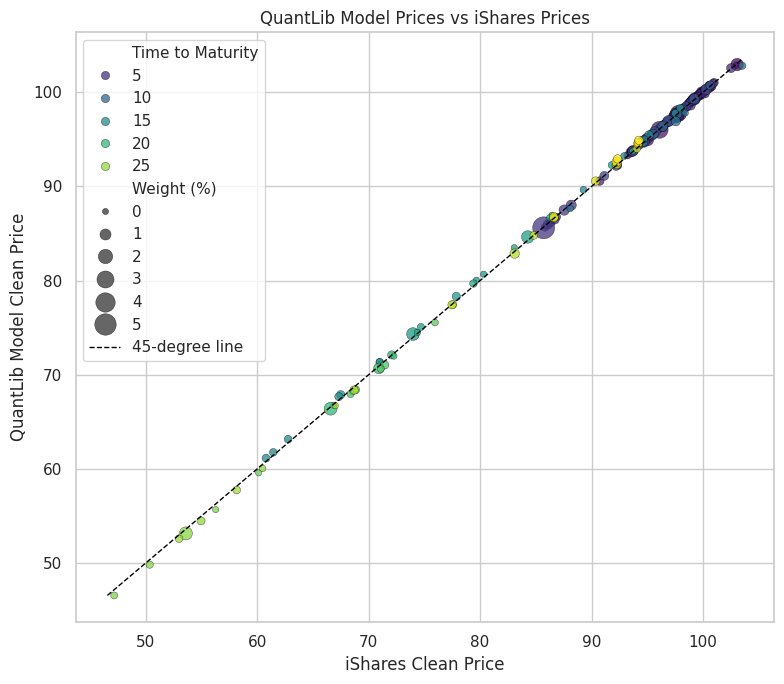

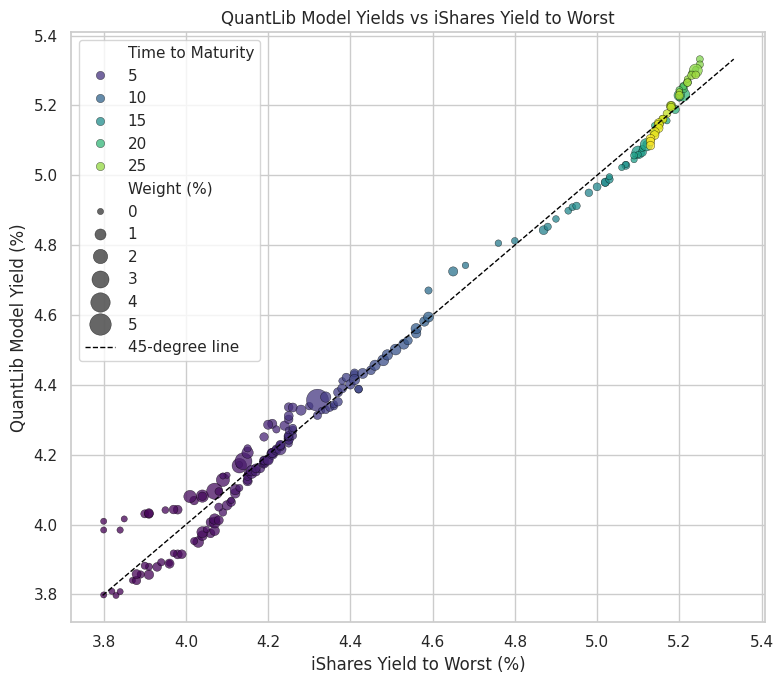

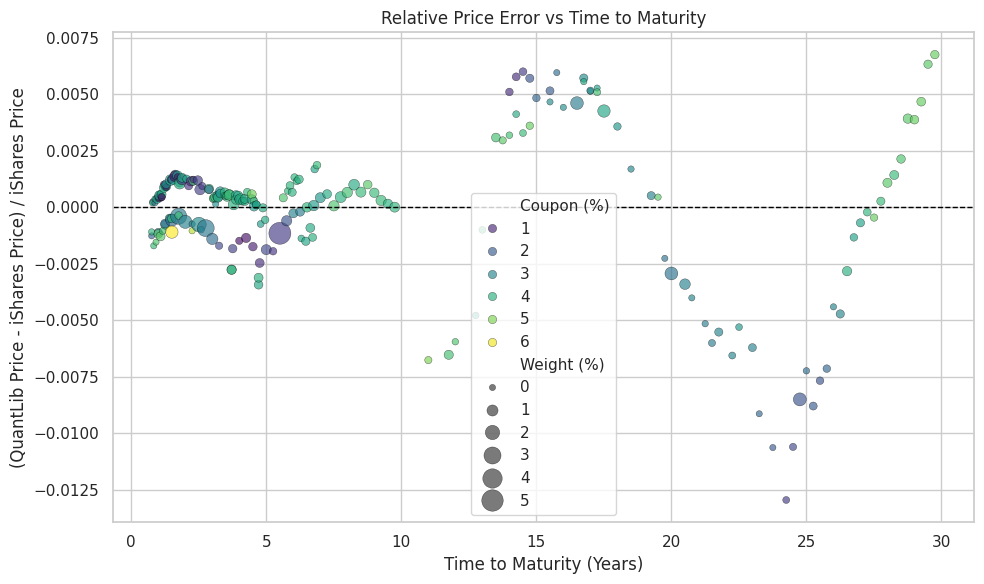

Excel output written to: quantlib_ishares_comparison_outputs.xlsx


In [23]:
# ============================================================
# Display, plot, and export QuantLib vs iShares comparison
#
# Required existing objects from Module 1:
#   df
#   df_curve
#   eval_date
#   curve_obj
#   ts
#   werr
#   error_df
#   zero_df
#   comparison_df
#   stats_table
#
# Output:
#   bucket_stats
#   diagnostics_table
#   quantlib_ishares_comparison_outputs.xlsx
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# Validate inputs
# ============================================================

required_objects = [
    "df",
    "df_curve",
    "eval_date",
    "ts",
    "comparison_df",
    "stats_table",
]

missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise NameError(f"Missing required objects from Module 1: {missing_objects}")


# ============================================================
# Display settings
# ============================================================

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", "{:,.6f}".format)


# ============================================================
# Common display columns
# ============================================================

comparison_display_cols = [
    "Name",
    "Maturity",
    "Effective Date",
    "Time to Maturity",
    "Coupon (%)",
    "Weight (%)",
    "iShares Price",
    "QuantLib Price",
    "Price Error",
    "Abs Price Error",
    "iShares Yield to Worst (%)",
    "QuantLib Yield (%)",
    "Yield Error (%)",
    "Abs Yield Error (%)",
]

comparison_display_cols = [
    c for c in comparison_display_cols
    if c in comparison_df.columns
]


# ============================================================
# 1) Summary
# ============================================================

print("=== SUMMARY ===")
print("iShares eval_date:", pd.Timestamp(eval_date).date())
print("Cleaned holdings rows:", len(df))
print("Curve-fitting rows:", len(df_curve))
print("Comparison rows:", len(comparison_df))

if "werr" in globals():
    print(f"Curve weighted average absolute clean-price error: {werr:.6f}")

print("\n=== STATS TABLE ===")
display(stats_table)

if "zero_df" in globals():
    print("=== QUANTLIB ZERO RATES ===")
    display(zero_df)


# ============================================================
# 2) Full comparison table
# ============================================================

sort_cols = [c for c in ["Maturity", "Coupon (%)", "Name"] if c in comparison_df.columns]

full_comparison_table = comparison_df[comparison_display_cols].copy()

if sort_cols:
    full_comparison_table = full_comparison_table.sort_values(sort_cols)

print("=== FULL COMPARISON TABLE ===")
display(full_comparison_table.reset_index(drop=True))


# ============================================================
# 3) Error rankings
# ============================================================

if "Abs Price Error" in comparison_df.columns:
    price_error_ranking = (
        comparison_df[comparison_display_cols]
        .sort_values("Abs Price Error", ascending=False)
        .reset_index(drop=True)
    )

    print("=== PRICE ERROR RANKING ===")
    display(price_error_ranking)
else:
    price_error_ranking = pd.DataFrame()

if "Abs Yield Error (%)" in comparison_df.columns:
    yield_error_ranking = (
        comparison_df[comparison_display_cols]
        .sort_values("Abs Yield Error (%)", ascending=False)
        .reset_index(drop=True)
    )

    print("=== YIELD ERROR RANKING ===")
    display(yield_error_ranking)
else:
    yield_error_ranking = pd.DataFrame()


# ============================================================
# 4) Compact diagnostics
# ============================================================

diagnostics = {
    "Total comparison rows": len(comparison_df),
    "Non-null iShares prices": comparison_df["iShares Price"].notna().sum()
        if "iShares Price" in comparison_df.columns else np.nan,
    "Non-null QuantLib prices": comparison_df["QuantLib Price"].notna().sum()
        if "QuantLib Price" in comparison_df.columns else np.nan,
    "Non-null iShares YTW": comparison_df["iShares Yield to Worst (%)"].notna().sum()
        if "iShares Yield to Worst (%)" in comparison_df.columns else np.nan,
    "Non-null QuantLib yields": comparison_df["QuantLib Yield (%)"].notna().sum()
        if "QuantLib Yield (%)" in comparison_df.columns else np.nan,
    "Mean abs price error": comparison_df["Abs Price Error"].mean()
        if "Abs Price Error" in comparison_df.columns else np.nan,
    "Median abs price error": comparison_df["Abs Price Error"].median()
        if "Abs Price Error" in comparison_df.columns else np.nan,
    "Max abs price error": comparison_df["Abs Price Error"].max()
        if "Abs Price Error" in comparison_df.columns else np.nan,
    "Mean abs yield error": comparison_df["Abs Yield Error (%)"].mean()
        if "Abs Yield Error (%)" in comparison_df.columns else np.nan,
    "Median abs yield error": comparison_df["Abs Yield Error (%)"].median()
        if "Abs Yield Error (%)" in comparison_df.columns else np.nan,
    "Max abs yield error": comparison_df["Abs Yield Error (%)"].max()
        if "Abs Yield Error (%)" in comparison_df.columns else np.nan,
}

diagnostics_table = pd.Series(diagnostics).to_frame("Value")

print("=== DIAGNOSTICS ===")
display(diagnostics_table)


# ============================================================
# 5) Maturity bucket stats
# ============================================================

bucket_df = comparison_df.copy()

bucket_df["Time to Maturity"] = pd.to_numeric(
    bucket_df["Time to Maturity"],
    errors="coerce",
)

bucket_df = bucket_df.dropna(subset=["Time to Maturity"]).copy()

bucket_df["Maturity Bucket"] = pd.cut(
    bucket_df["Time to Maturity"],
    bins=[0, 1, 2, 5, 10, 20, 30, np.inf],
    labels=["0-1Y", "1-2Y", "2-5Y", "5-10Y", "10-20Y", "20-30Y", "30Y+"],
    right=True,
)

agg_map = {
    "Observations": ("Name", "count"),
    "Mean_Time_to_Maturity": ("Time to Maturity", "mean"),
}

optional_aggs = {
    "Mean_iShares_Price": ("iShares Price", "mean"),
    "Mean_QuantLib_Price": ("QuantLib Price", "mean"),
    "Mean_Price_Error": ("Price Error", "mean"),
    "Mean_Abs_Price_Error": ("Abs Price Error", "mean"),
    "Max_Abs_Price_Error": ("Abs Price Error", "max"),
    "Mean_iShares_YTW": ("iShares Yield to Worst (%)", "mean"),
    "Mean_QuantLib_Yield": ("QuantLib Yield (%)", "mean"),
    "Mean_Yield_Error": ("Yield Error (%)", "mean"),
    "Mean_Abs_Yield_Error": ("Abs Yield Error (%)", "mean"),
    "Max_Abs_Yield_Error": ("Abs Yield Error (%)", "max"),
    "Total_Weight": ("Weight (%)", "sum"),
}

for new_col, spec in optional_aggs.items():
    source_col = spec[0]
    if source_col in bucket_df.columns:
        agg_map[new_col] = spec

bucket_stats = (
    bucket_df
    .groupby("Maturity Bucket", observed=True)
    .agg(**agg_map)
    .reset_index()
)

print("=== ERROR STATS BY MATURITY BUCKET ===")
display(bucket_stats)


# ============================================================
# 6) Largest positive / negative errors
# ============================================================

if "Price Error" in comparison_df.columns:
    largest_positive_price_errors = (
        comparison_df[comparison_display_cols]
        .sort_values("Price Error", ascending=False)
        .head(20)
        .reset_index(drop=True)
    )

    largest_negative_price_errors = (
        comparison_df[comparison_display_cols]
        .sort_values("Price Error", ascending=True)
        .head(20)
        .reset_index(drop=True)
    )

    print("=== LARGEST POSITIVE PRICE ERRORS ===")
    display(largest_positive_price_errors)

    print("=== LARGEST NEGATIVE PRICE ERRORS ===")
    display(largest_negative_price_errors)
else:
    largest_positive_price_errors = pd.DataFrame()
    largest_negative_price_errors = pd.DataFrame()

if "Yield Error (%)" in comparison_df.columns:
    largest_positive_yield_errors = (
        comparison_df[comparison_display_cols]
        .sort_values("Yield Error (%)", ascending=False)
        .head(20)
        .reset_index(drop=True)
    )

    largest_negative_yield_errors = (
        comparison_df[comparison_display_cols]
        .sort_values("Yield Error (%)", ascending=True)
        .head(20)
        .reset_index(drop=True)
    )

    print("=== LARGEST POSITIVE YIELD ERRORS ===")
    display(largest_positive_yield_errors)

    print("=== LARGEST NEGATIVE YIELD ERRORS ===")
    display(largest_negative_yield_errors)
else:
    largest_positive_yield_errors = pd.DataFrame()
    largest_negative_yield_errors = pd.DataFrame()


# ============================================================
# 7) Scatter plot: QuantLib Price vs iShares Price
# ============================================================

sns.set_theme(style="whitegrid")

price_plot_df = comparison_df.dropna(
    subset=[
        "iShares Price",
        "QuantLib Price",
        "Time to Maturity",
        "Weight (%)",
    ]
).copy()

plt.figure(figsize=(8, 7))

sns.scatterplot(
    data=price_plot_df,
    x="iShares Price",
    y="QuantLib Price",
    hue="Time to Maturity",
    size="Weight (%)",
    sizes=(20, 250),
    palette="viridis",
    alpha=0.75,
    edgecolor="black",
    linewidth=0.3,
)

min_price = min(
    price_plot_df["iShares Price"].min(),
    price_plot_df["QuantLib Price"].min(),
)

max_price = max(
    price_plot_df["iShares Price"].max(),
    price_plot_df["QuantLib Price"].max(),
)

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    color="black",
    linestyle="--",
    linewidth=1,
    label="45-degree line",
)

plt.title("QuantLib Model Prices vs iShares Prices")
plt.xlabel("iShares Clean Price")
plt.ylabel("QuantLib Model Clean Price")
plt.legend(loc="best")
plt.tight_layout()
plt.show()


# ============================================================
# 8) Scatter plot: QuantLib Yield vs iShares YTW
# ============================================================

yield_plot_df = comparison_df.dropna(
    subset=[
        "iShares Yield to Worst (%)",
        "QuantLib Yield (%)",
        "Time to Maturity",
        "Weight (%)",
    ]
).copy()

if not yield_plot_df.empty:
    plt.figure(figsize=(8, 7))

    sns.scatterplot(
        data=yield_plot_df,
        x="iShares Yield to Worst (%)",
        y="QuantLib Yield (%)",
        hue="Time to Maturity",
        size="Weight (%)",
        sizes=(20, 250),
        palette="viridis",
        alpha=0.75,
        edgecolor="black",
        linewidth=0.3,
    )

    min_yield = min(
        yield_plot_df["iShares Yield to Worst (%)"].min(),
        yield_plot_df["QuantLib Yield (%)"].min(),
    )

    max_yield = max(
        yield_plot_df["iShares Yield to Worst (%)"].max(),
        yield_plot_df["QuantLib Yield (%)"].max(),
    )

    plt.plot(
        [min_yield, max_yield],
        [min_yield, max_yield],
        color="black",
        linestyle="--",
        linewidth=1,
        label="45-degree line",
    )

    plt.title("QuantLib Model Yields vs iShares Yield to Worst")
    plt.xlabel("iShares Yield to Worst (%)")
    plt.ylabel("QuantLib Model Yield (%)")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()
else:
    print("No non-null QuantLib yields available for yield scatter plot.")


# ============================================================
# 9) Residual plots
# ============================================================

residual_df = comparison_df.copy()

residual_df["Relative Price Error"] = (
    residual_df["Price Error"] / residual_df["iShares Price"]
)

residual_df = residual_df.replace([np.inf, -np.inf], np.nan)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=residual_df.dropna(subset=["Time to Maturity", "Relative Price Error"]),
    x="Time to Maturity",
    y="Relative Price Error",
    hue="Coupon (%)",
    size="Weight (%)",
    sizes=(20, 250),
    palette="viridis",
    alpha=0.65,
    edgecolor="black",
    linewidth=0.3,
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Relative Price Error vs Time to Maturity")
plt.xlabel("Time to Maturity (Years)")
plt.ylabel("(QuantLib Price - iShares Price) / iShares Price")
plt.tight_layout()
plt.show()


# ============================================================
# 10) Export all output tables to Excel
# ============================================================

output_path = "quantlib_ishares_comparison_outputs.xlsx"

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    stats_table.to_excel(writer, sheet_name="Stats", index=False)
    diagnostics_table.to_excel(writer, sheet_name="Diagnostics")

    full_comparison_table.to_excel(
        writer,
        sheet_name="Full Comparison",
        index=False,
    )

    if not price_error_ranking.empty:
        price_error_ranking.to_excel(
            writer,
            sheet_name="Price Error Ranking",
            index=False,
        )

    if not yield_error_ranking.empty:
        yield_error_ranking.to_excel(
            writer,
            sheet_name="Yield Error Ranking",
            index=False,
        )

    bucket_stats.to_excel(
        writer,
        sheet_name="Maturity Bucket Stats",
        index=False,
    )

    if not largest_positive_price_errors.empty:
        largest_positive_price_errors.to_excel(
            writer,
            sheet_name="Positive Price Errors",
            index=False,
        )

    if not largest_negative_price_errors.empty:
        largest_negative_price_errors.to_excel(
            writer,
            sheet_name="Negative Price Errors",
            index=False,
        )

    if not largest_positive_yield_errors.empty:
        largest_positive_yield_errors.to_excel(
            writer,
            sheet_name="Positive Yield Errors",
            index=False,
        )

    if not largest_negative_yield_errors.empty:
        largest_negative_yield_errors.to_excel(
            writer,
            sheet_name="Negative Yield Errors",
            index=False,
        )

    if "zero_df" in globals():
        zero_df.to_excel(writer, sheet_name="Zero Rates", index=False)

    if "error_df" in globals():
        error_df.to_excel(writer, sheet_name="Curve Fit Errors", index=False)

print(f"Excel output written to: {output_path}")

In [24]:
import QuantLib as ql
import pandas as pd
from datetime import date
import logging

# Setup logging
logging.basicConfig(level=logging.DEBUG, format='%(message)s')
logger = logging.getLogger()

def yield_curve_quantlib(df, eval_date):
    settlement_days = 1
    day_count = ql.ActualActual(ql.ActualActual.Bond)
    min_ttm = 0.0

    #ql_eval_date = ql.Date(eval_date.day, eval_date.month, eval_date.year)
    ql_eval_date = ql.Date(eval_date.day, eval_date.month, eval_date.year)
    ql.Settings.instance().evaluationDate = ql_eval_date
    calendar = ql.UnitedStates(ql.UnitedStates.GovernmentBond)

    df_full = df.copy()
    df = df_full.dropna(subset=["Maturity", "Price", "Coupon (%)", "Par Value", "Mod. Duration", "Bond Age (Years)"]).copy()

    # Compute time to maturity (QL format)
    bond_daycount = ql.ActualActual(ql.ActualActual.Bond)
    df["QL_TTM"] = df["Maturity"].apply(
        lambda d: bond_daycount.yearFraction(ql_eval_date, ql.Date(d.day, d.month, d.year))
    )

    # Filter: bonds with positive and sufficiently long TTM
    df = df[df["QL_TTM"] > min_ttm]

    # Sort and deduplicate using rounded TTM to avoid QuantLib interpolation crashes
    df = (
        df.sort_values(by="Bond Age (Years)")
          .assign(QL_TTM_rounded=lambda d: d["QL_TTM"].round(6))
          .drop_duplicates(subset="QL_TTM_rounded", keep="first")
    )

    helpers = []
    bond_objs = []

    for _, row in df.iterrows():
        maturity = ql.Date(row["Maturity"].day, row["Maturity"].month, row["Maturity"].year)
        schedule = ql.Schedule(
            ql_eval_date, maturity, ql.Period(ql.Semiannual),
            calendar, ql.Unadjusted, ql.Unadjusted,
            ql.DateGeneration.Backward, False
        )
        bond = ql.FixedRateBond(
            settlement_days,
            float(row["Par Value"]),
            schedule,
            [float(row["Coupon (%)"]) / 100],
            day_count
        )
        
        # Log bond information
        logger.debug(f"Processing bond: {row['Name']} with Maturity: {row['Maturity']} and Price: {row['Price']}")

        try:
            # Creating bond helper
            helper = ql.BondHelper(ql.QuoteHandle(ql.SimpleQuote(float(row["Price"]))), bond)
            helpers.append(helper)
            bond_objs.append((bond, float(row["Price"]), float(row["Mod. Duration"])))
        except Exception as e:
            # Log any bond helper creation issues
            logger.error(f"Error creating BondHelper for bond {row['Name']} with Maturity: {row['Maturity']}: {e}")

    # Construct piecewise yield curve
    try:
        curve_obj = ql.PiecewiseLogCubicDiscount(ql_eval_date, helpers, day_count)
        #curve_obj = ql.PiecewiseFlatForward(ql_eval_date, helpers, day_count)
        curve_obj.enableExtrapolation()
    except Exception as e:
        logger.error(f"Error constructing PiecewiseLogCubicDiscount curve: {e}")
        return None, None, None, None

    # Wrap in handle for pricing
    curve_handle = ql.YieldTermStructureHandle(curve_obj)

    # Pricing error summary
    results = []
    total_error = 0
    total_duration = 0

    for bond, price, duration in bond_objs:
        try:
            bond.setPricingEngine(ql.DiscountingBondEngine(curve_handle))
            model_price = bond.cleanPrice()
            
            # Check if model price is NaN
            if model_price != model_price:  # NaN check
                logger.error(f"Model price for bond {bond} is NaN")
                model_price = None
            
            error = abs(model_price - price) if model_price is not None else None
            weighted_error = error * duration if error is not None else None

            results.append({
                "Maturity": bond.maturityDate().ISO(),
                "Observed": price,
                "Model": model_price,
                "Error": round(error, 4) if error is not None else None,
                "Duration QL": duration,
                "Weighted Error": round(weighted_error, 4) if weighted_error is not None else None
            })

            total_error += weighted_error if weighted_error is not None else 0
            total_duration += duration

        except Exception as e:
            logger.error(f"Error pricing bond {bond}: {e}")

    df_result = pd.DataFrame(results)

    # Merge with the full dataset
    df_full["Maturity"] = pd.to_datetime(df_full["Maturity"])
    df_result["Maturity"] = pd.to_datetime(df_result["Maturity"])

    df_merged = df_full.merge(df_result, on="Maturity", how="left")

    # Duration-weighted average error
    dw_error = total_error / total_duration if total_duration > 0 else None

    return curve_obj, curve_handle, df_merged, dw_error

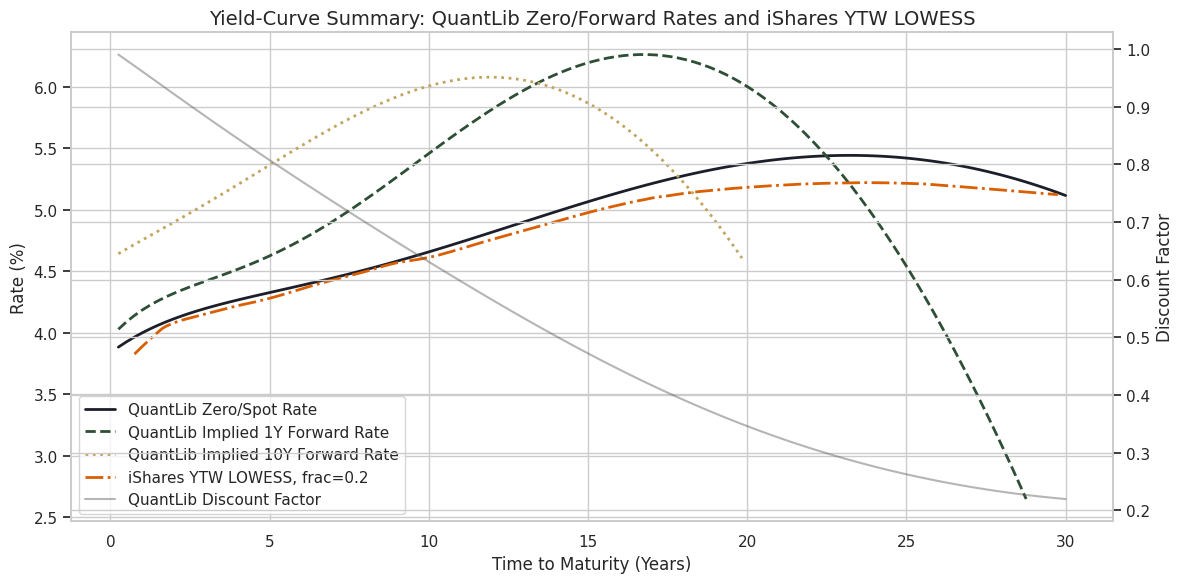

,Time (Years),Discount Factor,Spot Rate (%),1Y Forward Rate (%),10Y Forward Rate (%)
0,0.250000,0.990436,3.881346,4.026689,4.641136
1,0.497917,0.980840,3.923421,4.085638,4.678449
2,0.745833,0.971164,3.961855,4.137116,4.715153
3,0.993750,0.961435,3.997010,4.182244,4.751472
4,1.241667,0.951675,4.029219,4.222036,4.787595


,Info
0,No pillar points exposed by this curve object.


,Time (Years),LOWESS YTW (%)
0,0.755647,3.824764
1,0.791239,3.833955
2,0.832307,3.844492
3,0.876112,3.855646
4,0.917180,3.866021


In [25]:
# ============================================================
# Summary plot: QuantLib curve elements + iShares LOWESS YTW
#
# Required objects from Module 1:
#   df          = cleaned iShares holdings
#   eval_date   = iShares holdings date
#   ts          = QuantLib YieldTermStructureHandle
#   curve_obj   = QuantLib FittedBondDiscountCurve
#
# Outputs:
#   df_curve_elements = QuantLib discount factors, spot rates, forward rates
#   df_pillars        = curve pillar points, if exposed by QuantLib
#   df_lowess         = LOWESS-smoothed iShares Yield to Worst
# ============================================================

import datetime
import numpy as np
import pandas as pd
import QuantLib as ql
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess


# ------------------------------------------------------------
# Validate inputs
# ------------------------------------------------------------

required_objects = ["df", "eval_date", "ts"]

missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise NameError(f"Missing required objects from Module 1: {missing_objects}")

if "curve_obj" not in globals():
    curve_obj = None


# ------------------------------------------------------------
# Date helper
# ------------------------------------------------------------

def as_py_date_for_plot(x):
    if isinstance(x, pd.Timestamp):
        return x.date()
    if isinstance(x, datetime.datetime):
        return x.date()
    if isinstance(x, datetime.date):
        return x
    if isinstance(x, ql.Date):
        return datetime.date(x.year(), x.month(), x.dayOfMonth())
    return pd.Timestamp(x).date()


# ------------------------------------------------------------
# Main function
# ------------------------------------------------------------

def plot_yield_curve_elements_with_lowess(
    curve_handle,
    df_holdings,
    eval_date,
    curve_obj=None,
    calculate_forward_rate=True,
    max_time=30.0,
    min_time=0.25,
    n_points=121,
    lowess_frac=0.20,
):
    """
    Plot and return:
      - QuantLib discount factors
      - QuantLib zero/spot rates
      - QuantLib 1Y and 10Y implied forward rates
      - LOWESS-smoothed iShares Yield to Worst
      - QuantLib curve pillars, if available
    """

    # --------------------------------------------------------
    # Evaluation date and curve object
    # --------------------------------------------------------

    eval_date = as_py_date_for_plot(eval_date)

    ql.Settings.instance().evaluationDate = ql.Date(
        eval_date.day,
        eval_date.month,
        eval_date.year,
    )

    if curve_obj is None:
        try:
            curve_obj = curve_handle.currentLink()
        except Exception:
            curve_obj = None

    if curve_obj is not None:
        try:
            day_counter = curve_obj.dayCounter()
        except Exception:
            day_counter = ql.ActualActual(ql.ActualActual.Bond)
    else:
        day_counter = ql.ActualActual(ql.ActualActual.Bond)

    spot_compounding = ql.Compounded
    spot_frequency = ql.Semiannual

    forward_compounding = ql.Continuous
    forward_frequency = ql.Annual

    times = np.linspace(float(min_time), float(max_time), int(n_points))

    # --------------------------------------------------------
    # QuantLib curve elements
    # --------------------------------------------------------

    rows = []

    for t in times:
        try:
            discount_factor = float(curve_handle.discount(float(t), True))
        except Exception:
            discount_factor = np.nan

        try:
            spot_rate = 100.0 * float(
                curve_handle.zeroRate(
                    float(t),
                    spot_compounding,
                    spot_frequency,
                    True,
                ).rate()
            )
        except Exception:
            spot_rate = np.nan

        if calculate_forward_rate and t + 1.0 <= max_time:
            try:
                forward_1y = 100.0 * float(
                    curve_handle.forwardRate(
                        float(t),
                        float(t + 1.0),
                        forward_compounding,
                        forward_frequency,
                        True,
                    ).rate()
                )
            except Exception:
                forward_1y = np.nan
        else:
            forward_1y = np.nan

        if calculate_forward_rate and t + 10.0 <= max_time:
            try:
                forward_10y = 100.0 * float(
                    curve_handle.forwardRate(
                        float(t),
                        float(t + 10.0),
                        forward_compounding,
                        forward_frequency,
                        True,
                    ).rate()
                )
            except Exception:
                forward_10y = np.nan
        else:
            forward_10y = np.nan

        rows.append({
            "Time (Years)": float(t),
            "Discount Factor": discount_factor,
            "Spot Rate (%)": spot_rate,
            "1Y Forward Rate (%)": forward_1y,
            "10Y Forward Rate (%)": forward_10y,
        })

    df_curve_elements = pd.DataFrame(rows)

    # --------------------------------------------------------
    # Curve pillars
    # --------------------------------------------------------

    df_pillars = pd.DataFrame()

    if curve_obj is not None:
        try:
            pillar_dates = list(curve_obj.dates())
            pillar_rows = []

            for d in pillar_dates:
                try:
                    pillar_time = float(curve_obj.timeFromReference(d))
                    pillar_rate = 100.0 * float(
                        curve_obj.zeroRate(
                            d,
                            day_counter,
                            spot_compounding,
                            spot_frequency,
                        ).rate()
                    )

                    if np.isfinite(pillar_time) and np.isfinite(pillar_rate) and pillar_time >= 0:
                        pillar_rows.append({
                            "Date": as_py_date_for_plot(d),
                            "Time (Years)": pillar_time,
                            "Zero Rate (%)": pillar_rate,
                        })

                except Exception:
                    continue

            df_pillars = pd.DataFrame(pillar_rows)

        except Exception:
            df_pillars = pd.DataFrame()

    # --------------------------------------------------------
    # LOWESS from iShares Yield to Worst
    # --------------------------------------------------------

    required_lowess_cols = [
        "Time to Maturity",
        "Yield to Worst (%)",
    ]

    missing_cols = [c for c in required_lowess_cols if c not in df_holdings.columns]

    if missing_cols:
        raise KeyError(f"df_holdings is missing required LOWESS columns: {missing_cols}")

    df_obs = df_holdings.copy()

    df_obs["Time to Maturity"] = pd.to_numeric(
        df_obs["Time to Maturity"],
        errors="coerce",
    )

    df_obs["Yield to Worst (%)"] = pd.to_numeric(
        df_obs["Yield to Worst (%)"],
        errors="coerce",
    )

    if "Name" in df_obs.columns:
        df_obs = df_obs[
            ~df_obs["Name"].astype(str).str.contains(
                r"Cash|CSH FND",
                case=False,
                na=False,
            )
        ].copy()

    df_obs = (
        df_obs
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["Time to Maturity", "Yield to Worst (%)"])
        .copy()
    )

    df_obs = df_obs[
        (df_obs["Time to Maturity"] > 0)
        & (df_obs["Time to Maturity"] <= max_time)
    ].copy()

    if len(df_obs) < 3:
        raise ValueError(f"Need at least 3 observed bonds for LOWESS. Found {len(df_obs)}.")

    df_obs_grouped = (
        df_obs
        .groupby("Time to Maturity", as_index=False)
        .agg({"Yield to Worst (%)": "mean"})
        .sort_values("Time to Maturity")
    )

    if len(df_obs_grouped) < 3:
        raise ValueError(
            f"Need at least 3 unique maturities for LOWESS. Found {len(df_obs_grouped)}."
        )

    lowess_fit = lowess(
        endog=df_obs_grouped["Yield to Worst (%)"].to_numpy(dtype=float),
        exog=df_obs_grouped["Time to Maturity"].to_numpy(dtype=float),
        frac=float(lowess_frac),
        it=0,
        return_sorted=True,
    )

    df_lowess = pd.DataFrame(
        lowess_fit,
        columns=["Time (Years)", "LOWESS YTW (%)"],
    )

    df_lowess = (
        df_lowess
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["Time (Years)", "LOWESS YTW (%)"])
        .drop_duplicates(subset=["Time (Years)"])
        .sort_values("Time (Years)")
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    sns.set_theme(style="whitegrid")

    fig, ax1 = plt.subplots(figsize=(12, 6))

    sns.lineplot(
        data=df_curve_elements,
        x="Time (Years)",
        y="Spot Rate (%)",
        label="QuantLib Zero/Spot Rate",
        ax=ax1,
        linewidth=2,
        color="#1C1F2A",
    )

    if calculate_forward_rate:
        sns.lineplot(
            data=df_curve_elements,
            x="Time (Years)",
            y="1Y Forward Rate (%)",
            label="QuantLib Implied 1Y Forward Rate",
            ax=ax1,
            linewidth=2,
            linestyle="--",
            color="#2E4F36",
        )

        sns.lineplot(
            data=df_curve_elements,
            x="Time (Years)",
            y="10Y Forward Rate (%)",
            label="QuantLib Implied 10Y Forward Rate",
            ax=ax1,
            linewidth=2,
            linestyle=":",
            color="#C1A45F",
        )

    sns.lineplot(
        data=df_lowess,
        x="Time (Years)",
        y="LOWESS YTW (%)",
        label=f"iShares YTW LOWESS, frac={lowess_frac}",
        ax=ax1,
        linewidth=2,
        linestyle="-.",
        color="#D95F02",
    )

    if not df_pillars.empty:
        ax1.scatter(
            df_pillars["Time (Years)"],
            df_pillars["Zero Rate (%)"],
            label="QuantLib Curve Pillars",
            marker="o",
            color="#C1A45F",
            s=80,
            zorder=5,
            edgecolor="black",
            linewidth=0.3,
        )

    ax1.set_title(
        "Yield-Curve Summary: QuantLib Zero/Forward Rates and iShares YTW LOWESS",
        fontsize=14,
    )

    ax1.set_xlabel("Time to Maturity (Years)")
    ax1.set_ylabel("Rate (%)")
    ax1.grid(True)

    ax2 = ax1.twinx()

    sns.lineplot(
        data=df_curve_elements,
        x="Time (Years)",
        y="Discount Factor",
        ax=ax2,
        color="#5E5C58",
        linewidth=1.5,
        alpha=0.45,
        label="QuantLib Discount Factor",
    )

    ax2.set_ylabel("Discount Factor")

    handles_1, labels_1 = ax1.get_legend_handles_labels()
    handles_2, labels_2 = ax2.get_legend_handles_labels()

    ax1.legend(
        handles_1 + handles_2,
        labels_1 + labels_2,
        loc="best",
    )

    if ax2.get_legend() is not None:
        ax2.get_legend().remove()

    plt.tight_layout()
    plt.show()

    return df_curve_elements, df_pillars, df_lowess


# ------------------------------------------------------------
# Run summary plot
# ------------------------------------------------------------

df_curve_elements, df_pillars, df_lowess = plot_yield_curve_elements_with_lowess(
    curve_handle=ts,
    curve_obj=curve_obj,
    df_holdings=df,
    eval_date=eval_date,
    calculate_forward_rate=True,
    max_time=30.0,
    min_time=0.25,
    n_points=121,
    lowess_frac=0.20,
)

display(df_curve_elements.head())

if not df_pillars.empty:
    display(df_pillars.head())
else:
    display(pd.DataFrame({"Info": ["No pillar points exposed by this curve object."]}))

display(df_lowess.head())

=== CURVE COMPARISON TABLE ===


,Time to Maturity,Fitted Svensson Zero Rate (%),Fitted Svensson Discount Factor
0,0.250000,3.881346,0.990436
1,0.497917,3.923421,0.980840
2,0.745833,3.961855,0.971164
3,0.993750,3.997010,0.961435
4,1.241667,4.029219,0.951675


=== CURVE COMPARISON LONG TABLE ===


,Time to Maturity,Rate (%),Curve
0,0.250000,3.881346,Fitted Svensson Zero Curve
1,0.497917,3.923421,Fitted Svensson Zero Curve
2,0.745833,3.961855,Fitted Svensson Zero Curve
3,0.993750,3.997010,Fitted Svensson Zero Curve
4,1.241667,4.029219,Fitted Svensson Zero Curve
5,1.489583,4.058792,Fitted Svensson Zero Curve
6,1.737500,4.086017,Fitted Svensson Zero Curve
7,1.985417,4.111159,Fitted Svensson Zero Curve
8,2.233333,4.134466,Fitted Svensson Zero Curve
9,2.481250,4.156162,Fitted Svensson Zero Curve


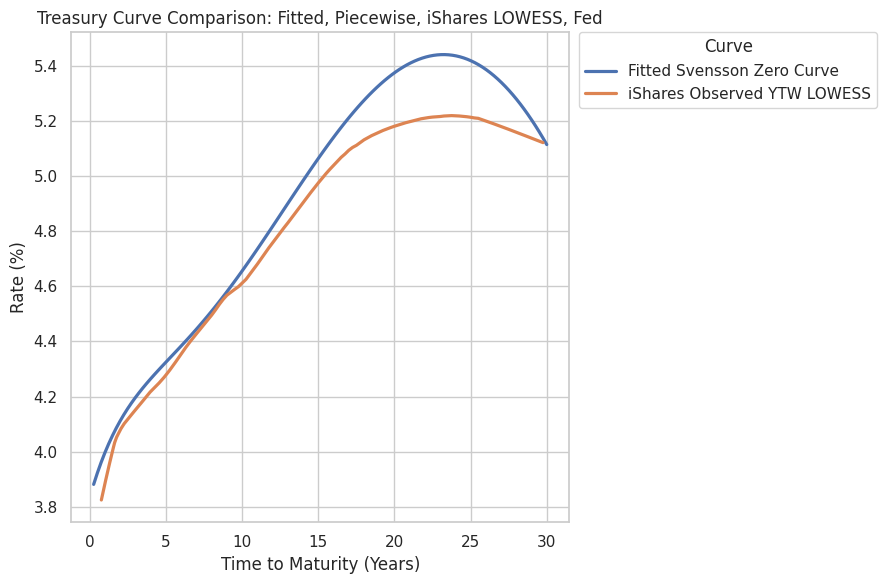

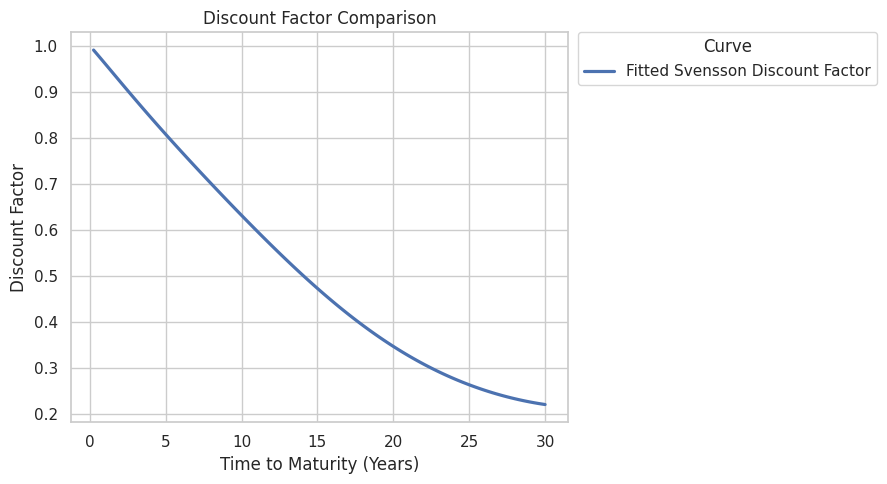

In [26]:
# ============================================================
# OUTPUT MODULE
# Compare Fitted Svensson Curve, Piecewise Bootstrap Curve,
# iShares Observed YTW LOWESS, and Fed Curve if available
#
# Required:
#   ts                     = fitted Svensson QuantLib curve handle
#   df                     = cleaned iShares GOVT holdings
#   eval_date              = evaluation date
#
# Optional:
#   piecewise_ts           = piecewise bootstrap QuantLib curve handle
#   piecewise_pillars_df   = piecewise pillar table
#   df_pillars             = fitted/economic pillar table from summary module
#   fed_curve_df           = Fed SVENY / SVENPY curve table
#
# Outputs:
#   curve_comparison_df
#   treasury_lowess_df
#   curve_comparison_long_df
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import QuantLib as ql
from statsmodels.nonparametric.smoothers_lowess import lowess


# ------------------------------------------------------------
# Validate required objects
# ------------------------------------------------------------

required_objects = ["ts", "df", "eval_date"]

missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise NameError(f"Missing required objects: {missing_objects}")


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

CURVE_OUTPUT_CONFIG = {
    "min_time": 0.25,
    "max_time": 30.0,
    "n_points": 121,
    "lowess_frac": 0.20,
    "spot_compounding": ql.Compounded,
    "spot_frequency": ql.Semiannual,
    "show_fitted_pillars": True,
    "show_piecewise_pillars": True,
    "legend_right_margin": 0.76,
}


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def ql_zero_rate_percent(curve_handle, t, config=CURVE_OUTPUT_CONFIG):
    """
    Return zero / spot rate in percent for a QuantLib curve handle.
    """
    try:
        return 100.0 * float(
            curve_handle.zeroRate(
                float(t),
                config["spot_compounding"],
                config["spot_frequency"],
                True,
            ).rate()
        )
    except Exception:
        return np.nan


def ql_discount_factor(curve_handle, t):
    try:
        return float(curve_handle.discount(float(t), True))
    except Exception:
        return np.nan


def move_legend_outside(ax=None, right_margin=None):
    if right_margin is None:
        right_margin = CURVE_OUTPUT_CONFIG["legend_right_margin"]

    if ax is None:
        ax = plt.gca()

    legend = ax.get_legend()

    if legend is not None:
        sns.move_legend(
            ax,
            "upper left",
            bbox_to_anchor=(1.02, 1),
            borderaxespad=0,
            frameon=True,
        )

    plt.tight_layout(rect=[0, 0, right_margin, 1])


def build_ishares_lowess_yield_curve(
    df,
    lowess_frac=0.20,
    max_time=30.0,
):
    """
    LOWESS-smoothed iShares observed Yield to Worst curve.

    This is not a zero curve.
    It is an empirical smoothing of observed bond-level YTW.
    """
    required = ["Time to Maturity", "Yield to Worst (%)"]

    missing = [c for c in required if c not in df.columns]

    if missing:
        raise KeyError(f"df is missing required columns for LOWESS: {missing}")

    obs = df.copy()

    obs["Time to Maturity"] = pd.to_numeric(
        obs["Time to Maturity"],
        errors="coerce",
    )

    obs["Yield to Worst (%)"] = pd.to_numeric(
        obs["Yield to Worst (%)"],
        errors="coerce",
    )

    if "Name" in obs.columns:
        obs = obs[
            ~obs["Name"].astype(str).str.contains(
                r"Cash|CSH FND",
                case=False,
                na=False,
            )
        ].copy()

    obs = (
        obs
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=required)
        .copy()
    )

    obs = obs[
        (obs["Time to Maturity"] > 0)
        & (obs["Time to Maturity"] <= max_time)
    ].copy()

    if len(obs) < 3:
        return pd.DataFrame(
            columns=["Time to Maturity", "iShares LOWESS YTW (%)"]
        )

    grouped = (
        obs
        .groupby("Time to Maturity", as_index=False)
        .agg({"Yield to Worst (%)": "mean"})
        .sort_values("Time to Maturity")
    )

    if len(grouped) < 3:
        return pd.DataFrame(
            columns=["Time to Maturity", "iShares LOWESS YTW (%)"]
        )

    fit = lowess(
        endog=grouped["Yield to Worst (%)"].to_numpy(dtype="float64"),
        exog=grouped["Time to Maturity"].to_numpy(dtype="float64"),
        frac=float(lowess_frac),
        it=0,
        return_sorted=True,
    )

    return pd.DataFrame(
        fit,
        columns=["Time to Maturity", "iShares LOWESS YTW (%)"],
    )


def prepare_fed_curve_for_plot(fed_curve_df):
    """
    Accepts Fed table variants from earlier modules.

    Expected possible columns:
      - Tenor
      - Fed Zero Yield SVENY (%)
      - SVENY Zero Yield (%)
      - Fed Par Yield SVENPY (%)
      - SVENPY Par Yield (%)
    """
    if fed_curve_df is None or not isinstance(fed_curve_df, pd.DataFrame) or fed_curve_df.empty:
        return pd.DataFrame()

    out = fed_curve_df.copy()

    if "Tenor" not in out.columns:
        return pd.DataFrame()

    out["Tenor"] = pd.to_numeric(out["Tenor"], errors="coerce")

    zero_col = None
    par_col = None

    for candidate in ["Fed Zero Yield SVENY (%)", "SVENY Zero Yield (%)"]:
        if candidate in out.columns:
            zero_col = candidate
            break

    for candidate in ["Fed Par Yield SVENPY (%)", "SVENPY Par Yield (%)"]:
        if candidate in out.columns:
            par_col = candidate
            break

    rows = []

    if zero_col is not None:
        temp = out[["Tenor", zero_col]].copy()
        temp[zero_col] = pd.to_numeric(temp[zero_col], errors="coerce")
        temp = temp.dropna(subset=["Tenor", zero_col])
        temp = temp.rename(columns={"Tenor": "Time to Maturity", zero_col: "Rate (%)"})
        temp["Curve"] = "Fed SVENY Zero Curve"
        rows.append(temp[["Time to Maturity", "Rate (%)", "Curve"]])

    if par_col is not None:
        temp = out[["Tenor", par_col]].copy()
        temp[par_col] = pd.to_numeric(temp[par_col], errors="coerce")
        temp = temp.dropna(subset=["Tenor", par_col])
        temp = temp.rename(columns={"Tenor": "Time to Maturity", par_col: "Rate (%)"})
        temp["Curve"] = "Fed SVENPY Par Curve"
        rows.append(temp[["Time to Maturity", "Rate (%)", "Curve"]])

    if rows:
        return pd.concat(rows, ignore_index=True)

    return pd.DataFrame()


def prepare_pillar_table_for_plot(pillar_df, source_label):
    """
    Prepare pillar points from df_pillars or piecewise_pillars_df.
    """
    if pillar_df is None or not isinstance(pillar_df, pd.DataFrame) or pillar_df.empty:
        return pd.DataFrame()

    required = ["Time (Years)", "Zero Rate (%)"]

    missing = [c for c in required if c not in pillar_df.columns]

    if missing:
        return pd.DataFrame()

    out = pillar_df.copy()

    out["Time (Years)"] = pd.to_numeric(
        out["Time (Years)"],
        errors="coerce",
    )

    out["Zero Rate (%)"] = pd.to_numeric(
        out["Zero Rate (%)"],
        errors="coerce",
    )

    out = (
        out
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["Time (Years)", "Zero Rate (%)"])
        .copy()
    )

    if out.empty:
        return pd.DataFrame()

    out["Pillar Set"] = source_label

    return out


# ------------------------------------------------------------
# Build curve comparison table
# ------------------------------------------------------------

times = np.linspace(
    CURVE_OUTPUT_CONFIG["min_time"],
    CURVE_OUTPUT_CONFIG["max_time"],
    CURVE_OUTPUT_CONFIG["n_points"],
)

rows = []

for t in times:
    row = {
        "Time to Maturity": float(t),
        "Fitted Svensson Zero Rate (%)": ql_zero_rate_percent(ts, t),
        "Fitted Svensson Discount Factor": ql_discount_factor(ts, t),
    }

    if "piecewise_ts" in globals():
        row["Piecewise Bootstrap Zero Rate (%)"] = ql_zero_rate_percent(piecewise_ts, t)
        row["Piecewise Bootstrap Discount Factor"] = ql_discount_factor(piecewise_ts, t)

    rows.append(row)

curve_comparison_df = pd.DataFrame(rows)

treasury_lowess_df = build_ishares_lowess_yield_curve(
    df=df,
    lowess_frac=CURVE_OUTPUT_CONFIG["lowess_frac"],
    max_time=CURVE_OUTPUT_CONFIG["max_time"],
)


# ------------------------------------------------------------
# Long-format curve table for plotting
# ------------------------------------------------------------

curve_parts = []

if "Fitted Svensson Zero Rate (%)" in curve_comparison_df.columns:
    curve_parts.append(
        curve_comparison_df[
            ["Time to Maturity", "Fitted Svensson Zero Rate (%)"]
        ]
        .rename(columns={"Fitted Svensson Zero Rate (%)": "Rate (%)"})
        .assign(Curve="Fitted Svensson Zero Curve")
    )

if "Piecewise Bootstrap Zero Rate (%)" in curve_comparison_df.columns:
    curve_parts.append(
        curve_comparison_df[
            ["Time to Maturity", "Piecewise Bootstrap Zero Rate (%)"]
        ]
        .rename(columns={"Piecewise Bootstrap Zero Rate (%)": "Rate (%)"})
        .assign(Curve="Piecewise Bootstrap Zero Curve")
    )

if not treasury_lowess_df.empty:
    curve_parts.append(
        treasury_lowess_df.rename(
            columns={"iShares LOWESS YTW (%)": "Rate (%)"}
        ).assign(Curve="iShares Observed YTW LOWESS")
    )

if "fed_curve_df" in globals():
    fed_plot_df = prepare_fed_curve_for_plot(fed_curve_df)
    if not fed_plot_df.empty:
        curve_parts.append(fed_plot_df)

curve_comparison_long_df = (
    pd.concat(curve_parts, ignore_index=True)
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["Time to Maturity", "Rate (%)", "Curve"])
)


# ------------------------------------------------------------
# Prepare pillar points
# ------------------------------------------------------------

fitted_pillars_plot_df = pd.DataFrame()
piecewise_pillars_plot_df = pd.DataFrame()

if CURVE_OUTPUT_CONFIG["show_fitted_pillars"] and "df_pillars" in globals():
    fitted_pillars_plot_df = prepare_pillar_table_for_plot(
        df_pillars,
        source_label="Fitted Curve Pillars",
    )

if CURVE_OUTPUT_CONFIG["show_piecewise_pillars"] and "piecewise_pillars_df" in globals():
    piecewise_pillars_plot_df = prepare_pillar_table_for_plot(
        piecewise_pillars_df,
        source_label="Piecewise Bootstrap Pillars",
    )


# ------------------------------------------------------------
# Display summary tables
# ------------------------------------------------------------

print("=== CURVE COMPARISON TABLE ===")
display(curve_comparison_df.head())

print("=== CURVE COMPARISON LONG TABLE ===")
display(curve_comparison_long_df.head(20))

if not fitted_pillars_plot_df.empty:
    print("=== FITTED CURVE PILLARS ===")
    display(fitted_pillars_plot_df.head(20))

if not piecewise_pillars_plot_df.empty:
    print("=== PIECEWISE BOOTSTRAP PILLARS ===")
    display(piecewise_pillars_plot_df.head(20))


# ------------------------------------------------------------
# Plot 1: All curves together
# ------------------------------------------------------------

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

curve_style_order = [
    "Fitted Svensson Zero Curve",
    "Piecewise Bootstrap Zero Curve",
    "iShares Observed YTW LOWESS",
    "Fed SVENY Zero Curve",
    "Fed SVENPY Par Curve",
]

sns.lineplot(
    data=curve_comparison_long_df,
    x="Time to Maturity",
    y="Rate (%)",
    hue="Curve",
    hue_order=[c for c in curve_style_order if c in curve_comparison_long_df["Curve"].unique()],
    linewidth=2.3,
    ax=ax,
)

if not fitted_pillars_plot_df.empty:
    ax.scatter(
        fitted_pillars_plot_df["Time (Years)"],
        fitted_pillars_plot_df["Zero Rate (%)"],
        s=30,
        marker="o",
        alpha=0.65,
        edgecolor="black",
        linewidth=0.25,
        label="Fitted Curve Pillars",
        zorder=5,
    )

if not piecewise_pillars_plot_df.empty:
    ax.scatter(
        piecewise_pillars_plot_df["Time (Years)"],
        piecewise_pillars_plot_df["Zero Rate (%)"],
        s=45,
        marker="X",
        alpha=0.80,
        edgecolor="black",
        linewidth=0.25,
        label="Piecewise Bootstrap Pillars",
        zorder=6,
    )

ax.set_title("Treasury Curve Comparison: Fitted, Piecewise, iShares LOWESS, Fed")
ax.set_xlabel("Time to Maturity (Years)")
ax.set_ylabel("Rate (%)")
move_legend_outside(ax)
plt.show()


# ------------------------------------------------------------
# Plot 2: Fitted vs Piecewise only
# ------------------------------------------------------------

if "piecewise_ts" in globals():
    fitted_piecewise_df = curve_comparison_df[
        [
            "Time to Maturity",
            "Fitted Svensson Zero Rate (%)",
            "Piecewise Bootstrap Zero Rate (%)",
        ]
    ].copy()

    fitted_piecewise_long_df = (
        fitted_piecewise_df
        .melt(
            id_vars="Time to Maturity",
            value_vars=[
                "Fitted Svensson Zero Rate (%)",
                "Piecewise Bootstrap Zero Rate (%)",
            ],
            var_name="Curve",
            value_name="Rate (%)",
        )
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["Rate (%)"])
    )

    fig, ax = plt.subplots(figsize=(12, 6))

    sns.lineplot(
        data=fitted_piecewise_long_df,
        x="Time to Maturity",
        y="Rate (%)",
        hue="Curve",
        linewidth=2.5,
        ax=ax,
    )

    if not piecewise_pillars_plot_df.empty:
        ax.scatter(
            piecewise_pillars_plot_df["Time (Years)"],
            piecewise_pillars_plot_df["Zero Rate (%)"],
            s=50,
            marker="X",
            alpha=0.85,
            edgecolor="black",
            linewidth=0.25,
            label="Piecewise Bootstrap Pillars",
            zorder=6,
        )

    ax.set_title("Fitted Svensson Curve vs Piecewise Bootstrap Curve")
    ax.set_xlabel("Time to Maturity (Years)")
    ax.set_ylabel("Zero / Spot Rate (%)")
    move_legend_outside(ax)
    plt.show()


# ------------------------------------------------------------
# Plot 3: Difference between Piecewise and Fitted
# ------------------------------------------------------------

if "Piecewise Bootstrap Zero Rate (%)" in curve_comparison_df.columns:
    diff_df = curve_comparison_df.copy()

    diff_df["Piecewise minus Fitted (bp)"] = (
        100.0
        * (
            diff_df["Piecewise Bootstrap Zero Rate (%)"]
            - diff_df["Fitted Svensson Zero Rate (%)"]
        )
    )

    diff_df = (
        diff_df
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["Time to Maturity", "Piecewise minus Fitted (bp)"])
    )

    fig, ax = plt.subplots(figsize=(12, 5))

    sns.lineplot(
        data=diff_df,
        x="Time to Maturity",
        y="Piecewise minus Fitted (bp)",
        color="#B85700",
        linewidth=2.3,
        ax=ax,
    )

    ax.axhline(0, color="black", linestyle="--", linewidth=1)

    if not piecewise_pillars_plot_df.empty:
        pillar_diff = []

        for _, r in piecewise_pillars_plot_df.iterrows():
            t = float(r["Time (Years)"])
            z_piece = float(r["Zero Rate (%)"])
            z_fit = ql_zero_rate_percent(ts, t)
            pillar_diff.append({
                "Time (Years)": t,
                "Piecewise minus Fitted (bp)": 100.0 * (z_piece - z_fit),
            })

        pillar_diff_df = pd.DataFrame(pillar_diff).dropna()

        if not pillar_diff_df.empty:
            ax.scatter(
                pillar_diff_df["Time (Years)"],
                pillar_diff_df["Piecewise minus Fitted (bp)"],
                s=45,
                marker="X",
                edgecolor="black",
                linewidth=0.25,
                label="Piecewise Pillar Differences",
                zorder=5,
            )

    ax.set_title("Piecewise Bootstrap Curve minus Fitted Svensson Curve")
    ax.set_xlabel("Time to Maturity (Years)")
    ax.set_ylabel("Difference (bp)")
    move_legend_outside(ax)
    plt.show()


# ------------------------------------------------------------
# Plot 4: Discount factor comparison
# ------------------------------------------------------------

discount_cols = ["Fitted Svensson Discount Factor"]

if "Piecewise Bootstrap Discount Factor" in curve_comparison_df.columns:
    discount_cols.append("Piecewise Bootstrap Discount Factor")

discount_long_df = (
    curve_comparison_df[
        ["Time to Maturity"] + discount_cols
    ]
    .melt(
        id_vars="Time to Maturity",
        value_vars=discount_cols,
        var_name="Curve",
        value_name="Discount Factor",
    )
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["Discount Factor"])
)

fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data=discount_long_df,
    x="Time to Maturity",
    y="Discount Factor",
    hue="Curve",
    linewidth=2.3,
    ax=ax,
)

ax.set_title("Discount Factor Comparison")
ax.set_xlabel("Time to Maturity (Years)")
ax.set_ylabel("Discount Factor")
move_legend_outside(ax)
plt.show()

### Yield-Curve Summary: What This Chart Shows

This chart combines several different yield-curve concepts in one view. They are related, but they are not the same object.

### QuantLib Discount Factor
The discount factor tells us the present value of receiving 1 dollar at a future date.
If the discount factor at 10 years is 0.62, then 1 dollar paid in 10 years is worth 0.62 dollars today under the fitted QuantLib curve.
The discount factor is the most fundamental object in the curve. Once we know the discount factors, we can derive zero rates, spot rates, and forward rates.

### QuantLib Zero / Spot Rate
The zero rate, also called the spot rate, is the yield on a hypothetical zero-coupon bond.
A zero-coupon bond has only one cash flow: principal at maturity.
Therefore, the 10-year zero rate is the single yield that discounts one cash flow from year 10 back to today.
In this notebook, the QuantLib zero / spot rate is derived from the fitted discount curve:
`ts.zeroRate(...)`
This is a model-implied curve, not a directly observed market yield.

### QuantLib Forward Rates
A forward rate is an interest rate implied today for a future period.
The 1-year forward rate starting at year 5 means:
“What is the implied 1-year rate from year 5 to year 6?”
The 10-year forward rate starting at year 5 means:
“What is the implied annualized rate from year 5 to year 15?”
Forward rates are not forecasts. They are break-even rates implied by today’s fitted curve. They include expectations, term premia, liquidity effects, and model assumptions.

### Empirical "iShares" Yield to Worst
The iShares Yield to Worst is an observed bond-level yield from the ETF holdings file.
It is not a zero rate.
Each iShares bond has coupons, maturity, accrued interest, settlement assumptions, and vendor pricing conventions. Therefore, its Yield to Worst is not directly comparable to a theoretical zero-coupon rate without caution.
In the chart, individual iShares yields are smoothed with LOWESS to show the broad shape of observed ETF yields.

### LOWESS iShares YTW Curve
LOWESS is a non-parametric smoothing method.
It does not impose a financial model. It simply smooths observed bond yields across time to maturity.
This makes it useful for visual comparison, but it is not an arbitrage-free yield curve. It cannot be used directly for pricing cash flows.
The LOWESS line answers:
“What is the broad empirical shape of the observed iShares Yield to Worst data?”
It does not answer:
“What discount factor should be used to price a cash flow?”

### Curve Pillar Points
Pillar points are the key dates or maturities used internally by some QuantLib curve objects.
For a fitted curve, pillars may be less meaningful than for an exact bootstrap, because the whole curve is fitted globally rather than built one instrument at a time.
If QuantLib exposes pillar points, the chart shows them as markers.

### Why the Curves Do Not Match Perfectly
The QuantLib curve is a fitted model curve. It tries to explain many bond prices with one smooth discount function.
The iShares LOWESS line is a smoothed version of observed bond yields.
They can differ because:
- iShares yields are bond-level yields, not zero rates
- coupon bonds and zero-coupon rates are different objects
- the QuantLib curve is fitted to prices, not directly to Yield to Worst
- iShares uses vendor pricing and rounding conventions
- short maturities are sensitive to settlement and accrued-interest assumptions
- old and off-the-run bonds may contain liquidity premia
- the Svensson curve imposes a smooth functional shape

### Correct Interpretation
The chart should be read as a diagnostic comparison.
It shows:
- the model-implied discount curve
- the model-implied zero / spot curve
- the model-implied forward curves
- the empirical shape of observed iShares yields

It does not prove that one curve is “true” and the other is “wrong.”
The correct interpretation is:
“The QuantLib curve gives us an internally consistent pricing curve. The iShares LOWESS line shows the empirical yield pattern in the ETF holdings. Differences between them are model residuals, convention effects, liquidity effects, and data effects.”

### Main Takeaway
A yield curve is not one single object.
There are several related curves:

| Curve Element | Meaning | Use |
|---|---|---|
| Discount factor curve | Present value of future cash flows | Pricing |
| Zero / spot curve | Yield on zero-coupon bonds | Discounting and curve comparison |
| Forward curve | Implied future rates | Term-structure analysis |
| Par curve | Coupon rate that prices a bond at par | Market quoting and benchmark comparison |
| iShares YTW curve | Observed bond-level yield data | Empirical diagnostics |
| LOWESS YTW curve | Smoothed observed yields | Visualization only |

For pricing, use the QuantLib discount curve.
For visual diagnostics, compare QuantLib zero / forward rates with iShares LOWESS Yield to Worst.

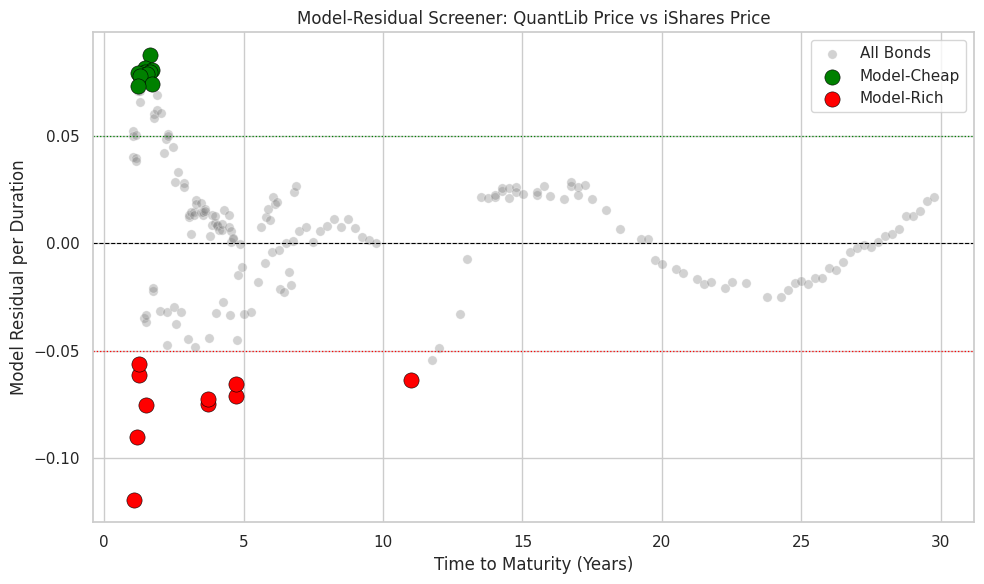

Duration used: Time-to-maturity proxy
Model-cheap bonds: model price > iShares price


,Signal,Name,Maturity,Time to Maturity,Coupon (%),Weight (%),iShares Price,QuantLib Price,Price Error,Relative Price Error,Duration Used,Model Residual per Duration,iShares Yield to Worst (%),QuantLib Yield (%),Yield Error (%)
35,Model-Cheap,TREASURY NOTE,2027-12-31,1.629021,3.380000,0.460000,98.930000,99.073270,0.143270,0.001448,1.629021,0.087949,4.060000,3.974826,-0.085174
29,Model-Cheap,TREASURY NOTE,2027-10-31,1.462012,3.500000,0.930000,99.250000,99.369638,0.119638,0.001205,1.462012,0.081831,4.030000,3.950173,-0.079827
37,Model-Cheap,TREASURY NOTE,2028-01-31,1.713895,3.500000,0.640000,99.070000,99.208360,0.138360,0.001397,1.713895,0.080728,4.070000,3.982456,-0.087544
30,Model-Cheap,TREASURY NOTE,2027-10-31,1.462012,0.500000,0.170000,95.060000,95.176523,0.116523,0.001226,1.462012,0.079701,4.020000,3.952866,-0.067134
36,Model-Cheap,TREASURY NOTE,2027-12-31,1.629021,0.630000,0.980000,94.670000,94.799733,0.129733,0.001370,1.629021,0.079639,4.040000,3.978481,-0.061519
21,Model-Cheap,TREASURY NOTE,2027-07-31,1.210130,0.380000,0.190000,95.810000,95.905887,0.095887,0.001001,1.210130,0.079237,3.940000,3.892120,-0.047880
34,Model-Cheap,TREASURY NOTE,2027-11-30,1.544148,3.380000,0.680000,99.010000,99.132118,0.122118,0.001233,1.544148,0.079084,4.040000,3.968378,-0.071622
27,Model-Cheap,TREASURY NOTE,2027-08-31,1.295003,3.130000,0.460000,98.920000,99.021190,0.101190,0.001023,1.295003,0.078139,3.990000,3.915285,-0.074715
38,Model-Cheap,TREASURY NOTE,2028-01-31,1.713895,0.750000,0.050000,94.590000,94.717209,0.127209,0.001345,1.713895,0.074222,4.050000,3.986174,-0.063826
20,Model-Cheap,TREASURY NOTE,2027-07-31,1.210130,2.750000,0.010000,98.580000,98.668558,0.088558,0.000898,1.210130,0.073180,3.960000,3.889525,-0.070475


Model-rich bonds: model price < iShares price


,Signal,Name,Maturity,Time to Maturity,Coupon (%),Weight (%),iShares Price,QuantLib Price,Price Error,Relative Price Error,Duration Used,Model Residual per Duration,iShares Yield to Worst (%),QuantLib Yield (%),Yield Error (%)
15,Model-Rich,TREASURY NOTE,2027-06-15,1.084189,4.630000,0.520000,100.750000,100.620359,-0.129641,-0.001287,1.084189,-0.119574,3.910000,4.032677,0.122677
19,Model-Rich,TREASURY NOTE,2027-07-15,1.166324,4.380000,0.110000,100.480000,100.375031,-0.104969,-0.001045,1.166324,-0.090000,3.950000,4.041611,0.091611
33,Model-Rich,TREASURY BOND,2027-11-15,1.503080,6.130000,1.380000,103.050000,102.936931,-0.113069,-0.001097,1.503080,-0.075225,4.010000,4.080465,0.070465
78,Model-Rich,TREASURY NOTE,2030-01-31,3.715264,4.250000,0.560000,100.150000,99.872695,-0.277305,-0.002769,3.715264,-0.074639,4.200000,4.285926,0.085926
77,Model-Rich,TREASURY NOTE,2030-01-31,3.715264,3.500000,0.560000,97.590000,97.320963,-0.269037,-0.002757,3.715264,-0.072414,4.210000,4.288553,0.078553
100,Model-Rich,TREASURY NOTE,2031-01-31,4.714579,3.750000,0.450000,97.860000,97.524540,-0.335460,-0.003428,4.714579,-0.071154,4.250000,4.336247,0.086247
101,Model-Rich,TREASURY NOTE,2031-01-31,4.714579,4.000000,0.510000,98.890000,98.581863,-0.308137,-0.003116,4.714579,-0.065358,4.260000,4.335246,0.075246
139,Model-Rich,TREASURY BOND,2037-05-15,11.000684,5.000000,0.170000,103.510000,102.810249,-0.699751,-0.006760,11.000684,-0.063610,4.590000,4.670158,0.080158
23,Model-Rich,TREASURY NOTE,2027-08-15,1.251198,3.750000,0.480000,99.720000,99.643043,-0.076957,-0.000772,1.251198,-0.061506,3.980000,4.042779,0.062779
24,Model-Rich,TREASURY NOTE,2027-08-15,1.251198,2.250000,0.450000,97.910000,97.839672,-0.070328,-0.000718,1.251198,-0.056209,3.970000,4.043177,0.073177


Signal counts:


,Count
Signal,
Neutral,158
Model-Cheap,23
Model-Rich,11


In [27]:
# ============================================================
# APPLICATION MODULE
# Model-residual screener: rich / cheap versus fitted curve
#
# Required object:
#   comparison_df
#
# Interpretation:
#   Price Error = QuantLib Price - iShares Price
#
#   Price Error > 0:
#       model price is above observed iShares price
#       bond looks cheap versus the model
#
#   Price Error < 0:
#       model price is below observed iShares price
#       bond looks rich versus the model
#
# This is not a trading recommendation.
# It is a diagnostic screen of model residuals.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------
# User-visible settings
# ------------------------------------------------------------

SCREENER_CONFIG = {
    # Minimum absolute score required for a bond to be highlighted.
    # Score = Price Error / Duration Used.
    "score_threshold": 0.05,

    # Number of top model-cheap and model-rich bonds to display.
    "top_n": 10,

    # Remove very short maturities where yield/price residuals are noisy.
    "min_time_to_maturity": 1.0,

    # Remove tiny ETF positions.
    "min_weight": 0.01,
}


# ------------------------------------------------------------
# Validate input
# ------------------------------------------------------------

if "comparison_df" not in globals():
    raise NameError("comparison_df is missing. Run the curve comparison module first.")


required_cols = [
    "Name",
    "Maturity",
    "Time to Maturity",
    "Coupon (%)",
    "Weight (%)",
    "iShares Price",
    "QuantLib Price",
    "Price Error",
]

missing_cols = [c for c in required_cols if c not in comparison_df.columns]

if missing_cols:
    raise KeyError(f"comparison_df is missing required columns: {missing_cols}")


# ------------------------------------------------------------
# Clean data
# ------------------------------------------------------------

df_screened = comparison_df.copy()

df_screened["Maturity"] = pd.to_datetime(df_screened["Maturity"], errors="coerce")

for col in [
    "Time to Maturity",
    "Coupon (%)",
    "Weight (%)",
    "iShares Price",
    "QuantLib Price",
    "Price Error",
]:
    df_screened[col] = pd.to_numeric(df_screened[col], errors="coerce")

df_screened = (
    df_screened
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=required_cols)
    .copy()
)

df_screened = df_screened[
    (df_screened["Time to Maturity"] >= SCREENER_CONFIG["min_time_to_maturity"])
    & (df_screened["Weight (%)"] >= SCREENER_CONFIG["min_weight"])
    & (df_screened["iShares Price"] > 0)
    & (df_screened["QuantLib Price"] > 0)
].copy()

if df_screened.empty:
    raise ValueError("No valid rows left for model-residual screening.")


# ------------------------------------------------------------
# Duration used for scaling
# ------------------------------------------------------------

duration_candidates = [
    "Duration QL",
    "QuantLib Duration",
    "Mod. Duration",
    "Duration",
]

duration_col = next(
    (c for c in duration_candidates if c in df_screened.columns),
    None,
)

if duration_col is not None:
    df_screened["Duration Used"] = pd.to_numeric(
        df_screened[duration_col],
        errors="coerce",
    )
    duration_label = duration_col
else:
    df_screened["Duration Used"] = df_screened["Time to Maturity"].clip(
        lower=0.25,
        upper=30,
    )
    duration_label = "Time-to-maturity proxy"

df_screened = (
    df_screened
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["Duration Used"])
    .copy()
)

df_screened = df_screened[df_screened["Duration Used"] > 0].copy()

if df_screened.empty:
    raise ValueError("No valid rows left after duration filtering.")


# ------------------------------------------------------------
# Residual score
# ------------------------------------------------------------

df_screened["Relative Price Error"] = (
    df_screened["Price Error"] / df_screened["iShares Price"]
)

df_screened["Model Residual per Duration"] = (
    df_screened["Price Error"] / df_screened["Duration Used"]
)

score_col = "Model Residual per Duration"
threshold = float(SCREENER_CONFIG["score_threshold"])
top_n = int(SCREENER_CONFIG["top_n"])

df_screened["Signal"] = "Neutral"
df_screened.loc[df_screened[score_col] > threshold, "Signal"] = "Model-Cheap"
df_screened.loc[df_screened[score_col] < -threshold, "Signal"] = "Model-Rich"


model_cheap = (
    df_screened[df_screened["Signal"].eq("Model-Cheap")]
    .sort_values(score_col, ascending=False)
    .head(top_n)
    .copy()
)

model_rich = (
    df_screened[df_screened["Signal"].eq("Model-Rich")]
    .sort_values(score_col, ascending=True)
    .head(top_n)
    .copy()
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_screened,
    x="Time to Maturity",
    y=score_col,
    color="gray",
    alpha=0.35,
    s=45,
    label="All Bonds",
)

if not model_cheap.empty:
    sns.scatterplot(
        data=model_cheap,
        x="Time to Maturity",
        y=score_col,
        color="green",
        s=120,
        label="Model-Cheap",
        edgecolor="black",
        linewidth=0.4,
    )

if not model_rich.empty:
    sns.scatterplot(
        data=model_rich,
        x="Time to Maturity",
        y=score_col,
        color="red",
        s=120,
        label="Model-Rich",
        edgecolor="black",
        linewidth=0.4,
    )

plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.axhline(threshold, color="green", linestyle=":", linewidth=0.9)
plt.axhline(-threshold, color="red", linestyle=":", linewidth=0.9)

plt.xlabel("Time to Maturity (Years)")
plt.ylabel("Model Residual per Duration")
plt.title("Model-Residual Screener: QuantLib Price vs iShares Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Candidate tables
# ------------------------------------------------------------

display_cols = [
    "Signal",
    "Name",
    "Maturity",
    "Time to Maturity",
    "Coupon (%)",
    "Weight (%)",
    "iShares Price",
    "QuantLib Price",
    "Price Error",
    "Relative Price Error",
    "Duration Used",
    score_col,
    "iShares Yield to Worst (%)",
    "QuantLib Yield (%)",
    "Yield Error (%)",
]

display_cols = [c for c in display_cols if c in df_screened.columns]

print("Duration used:", duration_label)

print("Model-cheap bonds: model price > iShares price")
display(model_cheap[display_cols])

print("Model-rich bonds: model price < iShares price")
display(model_rich[display_cols])

print("Signal counts:")
display(df_screened["Signal"].value_counts().to_frame("Count"))

## Fed Data is curated

Starting new HTTPS connection (1): www.federalreserve.gov:443
https://www.federalreserve.gov:443 "GET /data/yield-curve-tables/feds200628_1.html HTTP/1.1" 200 None
/tmp/ipykernel_101/3386035082.py:149: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_fed_raw["_Date_Normalized"] = df_fed_raw["Date"].dt.normalize()
No exact Fed row for 2026-05-15. Using latest available Fed date before target: 2026-05-05.
Loaded Fed curve date: 2026-05-05
Target date: 2026-05-15


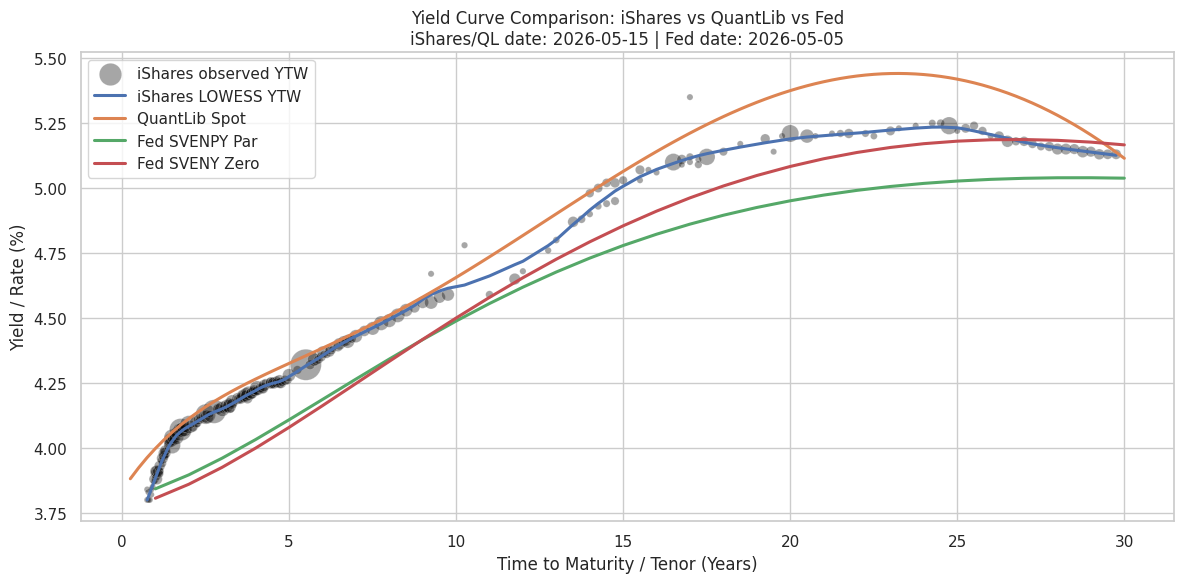

,Date,Tenor,Fed Par Yield SVENPY (%),Fed Zero Yield SVENY (%)
0,2026-05-05,1,3.842500,3.806300
1,2026-05-05,2,3.896300,3.860200
2,2026-05-05,3,3.960700,3.925500
3,2026-05-05,4,4.032200,3.999300
4,2026-05-05,5,4.108200,4.079000
5,2026-05-05,6,4.186300,4.162400
6,2026-05-05,7,4.264700,4.247600
7,2026-05-05,8,4.341900,4.333100
8,2026-05-05,9,4.416700,4.417600
9,2026-05-05,10,4.488200,4.499900


,Time to Maturity,QuantLib Spot Rate (%),QuantLib Discount Factor
0,0.250000,3.881346,0.990436
1,0.500000,3.923758,0.980759
2,0.750000,3.962472,0.971001
3,1.000000,3.997857,0.961189
4,1.250000,4.030254,0.951346


,Time to Maturity,iShares LOWESS YTW (%)
0,0.755647,3.799856
1,0.791239,3.811971
2,0.832307,3.825962
3,0.876112,3.840839
4,0.917180,3.854723


,Tenor,Rate (%),Curve
0,0.755647,3.799856,iShares LOWESS YTW
1,0.791239,3.811971,iShares LOWESS YTW
2,0.832307,3.825962,iShares LOWESS YTW
3,0.876112,3.840839,iShares LOWESS YTW
4,0.917180,3.854723,iShares LOWESS YTW


In [28]:
# ============================================================
# Module: Plot Fed curve vs QuantLib curve vs iShares curve
#
# Required existing objects:
#   df        = cleaned iShares holdings DataFrame
#   ts        = QuantLib YieldTermStructureHandle
#   eval_date = iShares / QuantLib evaluation date
#
# Data sources:
#   iShares curve  = observed Yield to Worst (%) from ETF holdings
#   QuantLib curve = fitted/bootstrapped spot curve from ts
#   Fed curve      = Federal Reserve Svensson HTML table
#
# Output:
#   fed_curve_df
#   ql_curve_df
#   ishares_curve_df
#   lowess_curve_df
#   combined_curve_df
# ============================================================

import re
import datetime
import numpy as np
import pandas as pd
import requests
import QuantLib as ql
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess


FED_HTML_URL = "https://www.federalreserve.gov/data/yield-curve-tables/feds200628_1.html"


# ------------------------------------------------------------
# Date helper
# ------------------------------------------------------------

def as_py_date(x):
    if isinstance(x, pd.Timestamp):
        return x.date()
    if isinstance(x, datetime.datetime):
        return x.date()
    if isinstance(x, datetime.date):
        return x
    if isinstance(x, ql.Date):
        return datetime.date(x.year(), x.month(), x.dayOfMonth())
    return pd.Timestamp(x).date()


# ------------------------------------------------------------
# Fed HTML loader
# ------------------------------------------------------------

def load_fed_sven_curve_from_html(
    url=FED_HTML_URL,
    target_date=None,
):
    """
    Load Fed nominal yield curve from the Federal Reserve HTML table.

    Extracts:
      SVENPY01...SVENPY30 = par yields
      SVENY01 ...SVENY30  = zero yields
    """
    headers = {
        "User-Agent": "Mozilla/5.0",
        "Accept": "text/html,text/plain,*/*",
        "Referer": "https://www.federalreserve.gov/data/yield-curve-tables.htm",
    }

    resp = requests.get(url, headers=headers, timeout=60)
    resp.raise_for_status()

    html = resp.text

    text = re.sub(r"<script.*?</script>", " ", html, flags=re.S | re.I)
    text = re.sub(r"<style.*?</style>", " ", text, flags=re.S | re.I)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"&nbsp;", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    header_match = re.search(
        r"Date\s+BETA0\s+BETA1\s+BETA2\s+BETA3\s+SVEN1F01",
        text,
    )

    if not header_match:
        raise ValueError("Could not locate Fed yield-curve table header in HTML.")

    data_text = text[header_match.start():]

    first_date_match = re.search(r"\b\d{2}-\d{2}-\d{4}\b", data_text)

    if not first_date_match:
        raise ValueError("Could not locate first data row date in Fed HTML table.")

    header_text = data_text[:first_date_match.start()].strip()
    rows_text = data_text[first_date_match.start():].strip()

    columns = header_text.split()
    expected_width = len(columns)

    date_matches = list(re.finditer(r"\b\d{2}-\d{2}-\d{4}\b", rows_text))

    if not date_matches:
        raise ValueError("No dated rows found in Fed HTML data.")

    rows = []

    for i, match in enumerate(date_matches):
        start = match.start()
        end = date_matches[i + 1].start() if i + 1 < len(date_matches) else len(rows_text)

        row_text = rows_text[start:end].strip()
        tokens = row_text.split()

        if len(tokens) == expected_width:
            rows.append(tokens)

    if not rows:
        raise ValueError("No Fed rows matched expected table width.")

    df_fed_raw = pd.DataFrame(rows, columns=columns)

    df_fed_raw["Date"] = pd.to_datetime(
        df_fed_raw["Date"],
        format="%m-%d-%Y",
        errors="coerce",
    )

    df_fed_raw = df_fed_raw.dropna(subset=["Date"]).copy()

    for col in df_fed_raw.columns:
        if col != "Date":
            df_fed_raw[col] = pd.to_numeric(df_fed_raw[col], errors="coerce")

    if target_date is None:
        if "eval_date" in globals() and eval_date is not None:
            target_date = pd.Timestamp(eval_date)
        else:
            target_date = df_fed_raw["Date"].max()
    else:
        target_date = pd.Timestamp(target_date)

    target_date = target_date.normalize()

    df_fed_raw["_Date_Normalized"] = df_fed_raw["Date"].dt.normalize()

    df_fed = df_fed_raw[df_fed_raw["_Date_Normalized"].eq(target_date)].copy()

    if df_fed.empty:
        available_before = df_fed_raw[
            df_fed_raw["_Date_Normalized"] <= target_date
        ]

        if available_before.empty:
            raise ValueError(
                f"No Fed curve data found on or before {target_date.date()}."
            )

        fallback_date = available_before["_Date_Normalized"].max()

        df_fed = df_fed_raw[
            df_fed_raw["_Date_Normalized"].eq(fallback_date)
        ].copy()

        print(
            f"No exact Fed row for {target_date.date()}. "
            f"Using latest available Fed date before target: {fallback_date.date()}."
        )

    actual_date = df_fed["_Date_Normalized"].iloc[0]

    par_cols = [
        c for c in df_fed.columns
        if re.fullmatch(r"SVENPY\d{2}", str(c))
    ]

    zero_cols = [
        c for c in df_fed.columns
        if re.fullmatch(r"SVENY\d{2}", str(c))
    ]

    par_cols = sorted(par_cols, key=lambda c: int(c[-2:]))
    zero_cols = sorted(zero_cols, key=lambda c: int(c[-2:]))

    if not par_cols:
        raise KeyError("No SVENPY par-yield columns found in Fed HTML table.")

    tenors = sorted({int(c[-2:]) for c in par_cols + zero_cols})

    curve_rows = []

    for tenor in tenors:
        par_col = f"SVENPY{tenor:02d}"
        zero_col = f"SVENY{tenor:02d}"

        curve_rows.append({
            "Date": actual_date,
            "Tenor": tenor,
            "Fed Par Yield SVENPY (%)": (
                float(df_fed[par_col].iloc[0])
                if par_col in df_fed.columns and pd.notna(df_fed[par_col].iloc[0])
                else np.nan
            ),
            "Fed Zero Yield SVENY (%)": (
                float(df_fed[zero_col].iloc[0])
                if zero_col in df_fed.columns and pd.notna(df_fed[zero_col].iloc[0])
                else np.nan
            ),
        })

    fed_curve_df = pd.DataFrame(curve_rows)

    df_fed = df_fed.drop(columns=["_Date_Normalized"], errors="ignore")
    df_fed_raw = df_fed_raw.drop(columns=["_Date_Normalized"], errors="ignore")

    print(f"Loaded Fed curve date: {actual_date.date()}")
    print(f"Target date: {target_date.date()}")

    return df_fed_raw, df_fed, fed_curve_df


# ------------------------------------------------------------
# iShares observed curve and LOWESS curve
# ------------------------------------------------------------

def build_ishares_curve_tables(
    df,
    lowess_frac=0.10,
    exclude_cash=True,
):
    required_cols = [
        "Time to Maturity",
        "Yield to Worst (%)",
        "Weight (%)",
    ]

    missing = [c for c in required_cols if c not in df.columns]

    if missing:
        raise KeyError(f"df is missing required iShares columns: {missing}")

    ishares_curve_df = df.copy()

    for col in required_cols:
        ishares_curve_df[col] = pd.to_numeric(ishares_curve_df[col], errors="coerce")

    ishares_curve_df = (
        ishares_curve_df
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=required_cols)
        .copy()
    )

    ishares_curve_df = ishares_curve_df[
        (ishares_curve_df["Time to Maturity"] > 0)
        & (ishares_curve_df["Weight (%)"] >= 0)
    ].copy()

    if exclude_cash and "Name" in ishares_curve_df.columns:
        ishares_curve_df = ishares_curve_df[
            ~ishares_curve_df["Name"].astype(str).str.contains(
                r"Cash|CSH FND",
                case=False,
                na=False,
            )
        ].copy()

    if ishares_curve_df.empty:
        raise ValueError("No valid iShares curve rows after filtering.")

    ishares_curve_df["Bubble Size"] = np.clip(
        ishares_curve_df["Weight (%)"].to_numpy(dtype=float) * 100,
        5,
        None,
    )

    lowess_base = (
        ishares_curve_df
        .groupby("Time to Maturity", as_index=False)
        .agg({
            "Yield to Worst (%)": "mean",
            "Weight (%)": "sum",
        })
        .sort_values("Time to Maturity")
    )

    if len(lowess_base) < 3:
        raise ValueError(
            f"Need at least 3 unique maturities for LOWESS. Found {len(lowess_base)}."
        )

    lowess_result = lowess(
        endog=lowess_base["Yield to Worst (%)"].to_numpy(dtype=float),
        exog=lowess_base["Time to Maturity"].to_numpy(dtype=float),
        frac=float(lowess_frac),
        it=0,
        return_sorted=True,
    )

    lowess_curve_df = pd.DataFrame(
        lowess_result,
        columns=["Time to Maturity", "iShares LOWESS YTW (%)"],
    )

    return ishares_curve_df, lowess_curve_df


# ------------------------------------------------------------
# QuantLib curve table
# ------------------------------------------------------------

def build_quantlib_curve_table(
    ts,
    min_time=0.25,
    max_time=30.0,
    n_points=120,
):
    times = np.linspace(float(min_time), float(max_time), int(n_points))

    rows = []

    for t in times:
        try:
            spot = 100.0 * float(
                ts.zeroRate(
                    float(t),
                    ql.Compounded,
                    ql.Semiannual,
                    True,
                ).rate()
            )
        except Exception:
            spot = np.nan

        try:
            discount = float(ts.discount(float(t), True))
        except Exception:
            discount = np.nan

        rows.append({
            "Time to Maturity": float(t),
            "QuantLib Spot Rate (%)": spot,
            "QuantLib Discount Factor": discount,
        })

    ql_curve_df = pd.DataFrame(rows).dropna(
        subset=["Time to Maturity", "QuantLib Spot Rate (%)"]
    )

    return ql_curve_df


# ------------------------------------------------------------
# Main module
# ------------------------------------------------------------

def plot_fed_quantlib_ishares_curves(
    df,
    ts,
    eval_date,
    fed_url=FED_HTML_URL,
    lowess_frac=0.10,
    min_time=0.25,
    max_time=30.0,
    n_points=120,
):
    """
    Plot three curves:
      - observed iShares Yield to Worst scatter
      - LOWESS-smoothed iShares YTW
      - QuantLib spot curve
      - Fed SVENPY par curve
      - Fed SVENY zero curve
    """

    eval_date = pd.Timestamp(as_py_date(eval_date))

    # Fed
    df_fed_raw, df_fed, fed_curve_df = load_fed_sven_curve_from_html(
        url=fed_url,
        target_date=eval_date,
    )

    # iShares
    ishares_curve_df, lowess_curve_df = build_ishares_curve_tables(
        df=df,
        lowess_frac=lowess_frac,
        exclude_cash=True,
    )

    # QuantLib
    ql_curve_df = build_quantlib_curve_table(
        ts=ts,
        min_time=min_time,
        max_time=max_time,
        n_points=n_points,
    )

    # Combined long-format table for line curves
    combined_parts = []

    combined_parts.append(
        lowess_curve_df.rename(
            columns={
                "Time to Maturity": "Tenor",
                "iShares LOWESS YTW (%)": "Rate (%)",
            }
        ).assign(Curve="iShares LOWESS YTW")[["Tenor", "Rate (%)", "Curve"]]
    )

    combined_parts.append(
        ql_curve_df.rename(
            columns={
                "Time to Maturity": "Tenor",
                "QuantLib Spot Rate (%)": "Rate (%)",
            }
        ).assign(Curve="QuantLib Spot")[["Tenor", "Rate (%)", "Curve"]]
    )

    combined_parts.append(
        fed_curve_df.rename(
            columns={
                "Tenor": "Tenor",
                "Fed Par Yield SVENPY (%)": "Rate (%)",
            }
        ).assign(Curve="Fed SVENPY Par")[["Tenor", "Rate (%)", "Curve"]]
    )

    combined_parts.append(
        fed_curve_df.rename(
            columns={
                "Tenor": "Tenor",
                "Fed Zero Yield SVENY (%)": "Rate (%)",
            }
        ).assign(Curve="Fed SVENY Zero")[["Tenor", "Rate (%)", "Curve"]]
    )

    combined_curve_df = (
        pd.concat(combined_parts, ignore_index=True)
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["Tenor", "Rate (%)", "Curve"])
    )

    # Plot
    sns.set_theme(style="whitegrid")

    plt.figure(figsize=(12, 6))

    sns.scatterplot(
        data=ishares_curve_df,
        x="Time to Maturity",
        y="Yield to Worst (%)",
        size="Bubble Size",
        sizes=(20, 500),
        alpha=0.35,
        color="black",
        legend=False,
        label="iShares observed YTW",
    )

    sns.lineplot(
        data=combined_curve_df,
        x="Tenor",
        y="Rate (%)",
        hue="Curve",
        linewidth=2.2,
    )

    fed_date = fed_curve_df["Date"].iloc[0].date()

    plt.title(
        f"Yield Curve Comparison: iShares vs QuantLib vs Fed\n"
        f"iShares/QL date: {eval_date.date()} | Fed date: {fed_date}"
    )
    plt.xlabel("Time to Maturity / Tenor (Years)")
    plt.ylabel("Yield / Rate (%)")
    plt.grid(True)
    plt.legend(title="")
    plt.tight_layout()
    plt.show()

    return {
        "fed_curve_df": fed_curve_df,
        "ql_curve_df": ql_curve_df,
        "ishares_curve_df": ishares_curve_df,
        "lowess_curve_df": lowess_curve_df,
        "combined_curve_df": combined_curve_df,
        "df_fed_raw": df_fed_raw,
        "df_fed": df_fed,
    }


# ------------------------------------------------------------
# Usage
# ------------------------------------------------------------

curve_outputs = plot_fed_quantlib_ishares_curves(
    df=df,
    ts=ts,
    eval_date=eval_date,
    fed_url=FED_HTML_URL,
    lowess_frac=0.10,
    min_time=0.25,
    max_time=30.0,
    n_points=120,
)

fed_curve_df = curve_outputs["fed_curve_df"]
ql_curve_df = curve_outputs["ql_curve_df"]
ishares_curve_df = curve_outputs["ishares_curve_df"]
lowess_curve_df = curve_outputs["lowess_curve_df"]
combined_curve_df = curve_outputs["combined_curve_df"]

display(fed_curve_df.head(30))
display(ql_curve_df.head())
display(lowess_curve_df.head())
display(combined_curve_df.head())

# Credit Spreads in Corporate Bonds
In the Treasury section, we built a USD risk-free term structure from Treasury bonds.
That curve gives us a benchmark for the time value of money.
We now move from Treasury bonds to corporate bonds.

The example is `USIG`, an investment-grade corporate bond ETF. Its holdings contain many USD corporate bonds issued 
by companies and financial institutions.

The key question changes.
For Treasuries, we mainly asked:
`What is the term structure of risk-free rates?`

For corporate bonds, we ask:
`How much extra yield does the market require above the Treasury curve?`

That extra yield is the credit spread.

### Core Intuition
A corporate bond yield is usually higher than a Treasury yield with similar maturity.
The difference exists because a corporate bond has additional risks:
- default risk
- downgrade risk
- lower liquidity
- sector-specific risk
- market stress sensitivity
- uncertainty about recovery value
- compensation for bearing credit risk

A corporate bond yield can be decomposed approximately as:
`Corporate Yield ≈ Treasury Yield + Credit Spread`

So:
`Credit Spread ≈ Corporate Yield - Matched Treasury Yield`

#### What We Do in the Code
The code performs four steps.

### Step 1: Download USIG Holdings
We download the USIG holdings from the BlackRock holdings endpoint.
The holdings contain bond-level data such as:
- name
- maturity
- price
- coupon
- weight in the ETF
- duration
- Yield to Worst

The code cleans the data and removes unusable rows.

### Step 2: Match Each Corporate Bond to the Treasury Curve
Each USIG bond has a remaining maturity:
`Time to Maturity`
For each bond, we ask the Treasury curve:
`What is the Treasury zero / spot rate at the same maturity?`

This gives a maturity-matched Treasury benchmark.
The benchmark is not one single Treasury yield for all bonds. It is different for every bond because each bond has a different maturity.

### Step 3: Calculate the Nominal Credit Spread
For every corporate bond, the code calculates:
`Nominal Credit Spread = Corporate Yield - Matched Treasury Zero Rate`

In the code:
`Corporate Yield` is based on iShares / BlackRock `Yield to Worst (%)`.
`Matched Treasury Zero Rate` comes from our fitted QuantLib Treasury curve.

The spread is reported in percent and basis points.
`1% = 100 basis points`
So a spread of `1.25%` is `125 bp`.

### Step 4: Estimate Price Impact from Spread Widening
The code also estimates the price impact of a spread widening.
Approximation:
`Price Change (%) ≈ -Spread Duration × Spread Change`

Example:
If spread duration is `6` and spreads widen by `100 bp`, then:
`Price Change ≈ -6 × 1.00% = -6.00%`
This shows why spread duration matters. Long credit bonds can lose substantial value when credit spreads widen.

#### Important Definitions
#### Treasury Zero / Spot Rate
The Treasury zero rate is the yield on a hypothetical zero-coupon Treasury bond.
It is derived from the fitted Treasury discount curve.
It is used as the risk-free benchmark.
In the code, this comes from:
`ts.zeroRate(...)`

#### Corporate Yield
The corporate yield is the bond-level yield from the USIG holdings file.
The module uses:
`Yield to Worst (%)`
Yield to Worst is the lowest yield an investor could receive under allowed bond features, such as calls, assuming no default. For plain non-callable bonds, Yield to Worst is often close to Yield to Maturity.
For callable bonds, Yield to Worst can differ from Yield to Maturity.

#### Nominal Credit Spread
The nominal credit spread is the difference between a corporate bond yield and a matched-maturity Treasury yield.
Formula:
`Nominal Spread = Corporate Yield - Treasury Yield`

Example:
If a corporate bond yields `5.80%` and the matched Treasury rate is `4.40%`, then:
`Nominal Spread = 5.80% - 4.40% = 1.40% = 140 bp`
This is the simplest spread measure.
It is easy to understand, but it is not the most precise spread measure.

#### Z-Spread
The Z-spread is more precise than the nominal spread.
It is the constant spread added to the entire Treasury zero curve so that the present value of the corporate bond cash flows equals the observed corporate bond price.
Conceptually:
`Corporate Price = PV(Cash Flows discounted at Treasury Zero Curve + Z-Spread)`
The Z-spread uses all bond cash flows, not just one maturity point.
This module does not solve for Z-spreads yet. It introduces nominal spreads first.

#### Option-Adjusted Spread
The option-adjusted spread adjusts for embedded options.
Many corporate bonds are callable. This means the issuer can repay the bond early.
A callable bond contains an option that benefits the issuer and hurts the investor.
The OAS attempts to remove the value of that embedded option and isolate the compensation for credit and liquidity risk. This module only introduces OAS conceptually.

### Why We Use the Treasury Curve
A spread must be measured against a benchmark.
The Treasury curve is our risk-free benchmark.
We do not compare every USIG bond to the same Treasury rate.
Instead, we use a matched-maturity Treasury rate.
A 2-year corporate bond is compared to the 2-year Treasury point.
A 10-year corporate bond is compared to the 10-year Treasury point.
A 25-year corporate bond is compared to the 25-year Treasury point.
This avoids mixing maturity risk with credit risk.

### What the Main Chart Shows
The first chart compares:
- USIG corporate bond yields
- the matched Treasury zero curve
- a LOWESS-smoothed USIG corporate yield curve

The scatter points are individual USIG bonds.
The x-axis is:
`Time to Maturity`
The y-axis is:
`Yield / Rate (%)`
The Treasury line is the risk-free benchmark.
The vertical distance between a corporate bond point and the Treasury line is approximately the credit spread.
The LOWESS line shows the smoothed empirical shape of USIG corporate yields.

### What the Spread Chart Shows
The second chart plots:
`Nominal Credit Spread (bp)`
against:
`Time to Maturity`
This directly shows how much extra yield USIG bonds offer above the matched Treasury curve.
A higher spread means the market demands more compensation for credit and liquidity risk.
A lower spread means the market demands less compensation.

### What the Spread-Duration Stress Chart Shows
The third chart estimates:
`Price Impact of Spread Widening`
This uses:
`Price Change (%) ≈ -Spread Duration × Spread Change`
If spreads widen, corporate bond prices fall.
If spreads tighten, corporate bond prices rise.
The chart helps to see that spread risk is not only about the level of the spread. It is also about sensitivity to spread changes. A bond with a modest spread but high spread duration can still have large spread risk.

### Why Spreads Differ Across Bonds
Credit spreads are not the same for every bond.
They differ because of:

| Driver | Effect |
|---|---|
| Credit quality | Weaker issuers usually have wider spreads |
| Maturity | Longer bonds often carry more uncertainty |
| Sector | Banks, utilities, industrials, and energy firms have different risks |
| Liquidity | Less liquid bonds usually require wider spreads |
| Seniority | Subordinated debt usually trades wider than senior debt |
| Coupon and price | Discount and premium bonds can behave differently |
| Embedded options | Callable bonds require option adjustment |
| Market stress | Spreads usually widen when risk aversion increases |

### Important Caveats
This module calculates a nominal spread approximation.
It does not calculate a full Z-spread.
It does not calculate a full option-adjusted spread.
It uses Yield to Worst from the holdings file and compares it with a matched Treasury zero / spot rate.

This is useful for intuition and teaching, but it is not a production credit-pricing system.

The module answers:
`How much extra yield do USIG corporate bonds offer relative to the Treasury curve?`

It does not answer:
`Which bonds are mispriced?`

It also does not prove that a higher-spread bond is better.

A higher spread may mean higher compensation, but it may also mean higher credit risk, lower liquidity, or greater exposure to stress.

### Takeaway
Treasury bonds teach the risk-free term structure.
Corporate bonds add credit and liquidity risk.
The credit spread is the bridge between risk-free pricing and risky bond pricing.

The key idea is:
`Corporate Yield = Risk-Free Rate + Credit Spread`

But the deeper question is:
`What part of the spread is expected loss, and what part is compensation for uncertainty, liquidity, and risk aversion?`

In [29]:
# ============================================================
# MODULE: USIG Credit Spreads
# Block 1: Download, map, clean, calculate
#
# Required from Treasury module:
#   ts        = QuantLib YieldTermStructureHandle
#   eval_date = Treasury / lecture evaluation date
#
# Main outputs:
#   usig_raw
#   usig_df
#   usig_spread_df
#   usig_file_date
#   usig_eval_date
#   spread_duration_source
#
# Spread definition:
#   Nominal Credit Spread
#   = Corporate Yield to Worst - Matched Treasury Zero/Spot Rate
#
# Teaching caveat:
#   This is a nominal spread approximation, not a full Z-spread.
# ============================================================

import re
from io import StringIO

import numpy as np
import pandas as pd
import requests
import QuantLib as ql


# ------------------------------------------------------------
# Validate Treasury inputs
# ------------------------------------------------------------

if "ts" not in globals():
    raise NameError("Treasury curve handle 'ts' is missing. Run the Treasury curve module first.")

if "eval_date" not in globals():
    raise NameError("eval_date is missing. Run the Treasury curve module first.")


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

USIG_CONFIG = {
    # Align USIG time-to-maturity to Treasury eval_date.
    "use_treasury_eval_date": True,

    # Holdings as-of date for BlackRock endpoint.
    # If None, use eval_date.
    "as_of_date": None,

    # Filters.
    "min_time_to_maturity": 0.25,
    "max_time_to_maturity": 30.0,
    "min_weight": 0.0,
    "min_price": 0.0,
    "max_price": 200.0,

    # Exclusions.
    "exclude_cash": True,
    "exclude_non_bonds": True,

    # Matched Treasury zero-rate convention.
    "treasury_compounding": ql.Compounded,
    "treasury_frequency": ql.Semiannual,

    # Spread-widening scenario.
    "spread_widening_bp": 100,
}


def build_usig_url(as_of_date=None):
    """
    Build BlackRock USIG holdings API URL.

    as_of_date format expected by endpoint:
        YYYYMMDD
    """
    if as_of_date is None:
        as_of_date = pd.Timestamp(eval_date)

    as_of_date = pd.Timestamp(as_of_date).strftime("%Y%m%d")

    return (
        "https://www.blackrock.com/varnish-api/blk-one01-product-data/"
        "product-data/api/v1/get-fund-document"
        "?appType=PRODUCT_PAGE"
        "&appSubType=ISHARES"
        "&targetSite=us-ishares"
        "&locale=en_US"
        "&portfolioId=239460"
        "&userType=individual"
        f"&asOfDate={as_of_date}"
        "&component=holdings"
    )


USIG_URL = build_usig_url(USIG_CONFIG["as_of_date"])

USIG_REFERER = (
    "https://www.ishares.com/us/products/239460/"
    "ishares-broad-usd-investment-grade-corporate-bond-etf"
)

USIG_HEADERS = {
    "User-Agent": "Mozilla/5.0",
    "Accept": "application/json,text/csv,text/plain,*/*",
    "Referer": USIG_REFERER,
}


# ------------------------------------------------------------
# Basic helpers
# ------------------------------------------------------------

def clean_number_credit(x):
    """
    Robust numeric cleaner for BlackRock / iShares holdings.
    """
    if pd.isna(x):
        return pd.NA

    s = str(x).strip()

    if s in {"--", "-", "", "nan", "None", "NaN", "N/A", "n/a"}:
        return pd.NA

    s = (
        s.replace("\ufeff", "")
         .replace("\xa0", "")
         .replace("’", "")
         .replace("'", "")
         .replace(",", "")
         .replace("%", "")
         .replace("$", "")
         .replace("USD", "")
         .strip()
    )

    s = re.sub(r"[^0-9.\-]", "", s)

    if s in {"", "-", ".", "-."}:
        return pd.NA

    try:
        return float(s)
    except ValueError:
        return pd.NA


def parse_blackrock_date_series(s):
    """
    Robust explicit date parser for BlackRock / iShares holdings.

    Avoids pandas warning:
        Could not infer format...

    Handles:
      - YYYY-MM-DD
      - MM/DD/YYYY
      - DD/Mon/YYYY
      - Mon DD, YYYY
      - Month DD, YYYY
      - Excel serial dates
    """
    s_original = s.copy()

    s_str = s.astype("string").str.strip()

    s_str = s_str.replace(
        {
            "": pd.NA,
            "--": pd.NA,
            "-": pd.NA,
            "nan": pd.NA,
            "NaN": pd.NA,
            "None": pd.NA,
            "N/A": pd.NA,
            "n/a": pd.NA,
        }
    )

    parsed = pd.to_datetime(
        s_str,
        format="%Y-%m-%d",
        errors="coerce",
    )

    missing = parsed.isna()
    if missing.any():
        parsed.loc[missing] = pd.to_datetime(
            s_str.loc[missing],
            format="%m/%d/%Y",
            errors="coerce",
        )

    missing = parsed.isna()
    if missing.any():
        parsed.loc[missing] = pd.to_datetime(
            s_str.loc[missing],
            format="%d/%b/%Y",
            errors="coerce",
        )

    missing = parsed.isna()
    if missing.any():
        parsed.loc[missing] = pd.to_datetime(
            s_str.loc[missing],
            format="%b %d, %Y",
            errors="coerce",
        )

    missing = parsed.isna()
    if missing.any():
        parsed.loc[missing] = pd.to_datetime(
            s_str.loc[missing],
            format="%B %d, %Y",
            errors="coerce",
        )

    # Excel serial date fallback.
    numeric_candidate = pd.to_numeric(s_original, errors="coerce")
    missing = parsed.isna()

    excel_mask = (
        missing
        & numeric_candidate.notna()
        & (numeric_candidate > 20_000)
        & (numeric_candidate < 80_000)
    )

    if excel_mask.any():
        parsed.loc[excel_mask] = pd.to_datetime(
            numeric_candidate.loc[excel_mask],
            unit="D",
            origin="1899-12-30",
            errors="coerce",
        )

    return parsed


def infer_date_from_url(url):
    m = re.search(r"asOfDate=(\d{8})", url)
    if m:
        return pd.to_datetime(m.group(1), format="%Y%m%d")
    return pd.NaT


def normalize_column_name(col):
    """
    Normalize BlackRock field names into notebook-friendly names.
    """
    c = str(col).strip()
    key = re.sub(r"[^a-z0-9]+", "", c.lower())

    mapping = {
        "name": "Name",
        "securityname": "Name",
        "holdingname": "Name",
        "issuername": "Issuer",
        "issuer": "Issuer",
        "ticker": "Ticker",
        "cusip": "CUSIP",
        "isin": "ISIN",
        "sedol": "SEDOL",

        "assetclass": "Asset Class",
        "sector": "Sector",
        "sectorname": "Sector",
        "industry": "Industry",
        "rating": "Rating",
        "moodysrating": "Moody Rating",
        "sprating": "S&P Rating",
        "s&prating": "S&P Rating",
        "fitchrating": "Fitch Rating",

        "marketvalue": "Market Value",
        "marketvalueusd": "Market Value",
        "notionalvalue": "Notional Value",
        "parvalue": "Par Value",
        "weight": "Weight (%)",
        "weightpercent": "Weight (%)",
        "weightpct": "Weight (%)",
        "weighting": "Weight (%)",

        "price": "Price",
        "coupon": "Coupon (%)",
        "couponrate": "Coupon (%)",
        "yieldtoworst": "Yield to Worst (%)",
        "ytw": "Yield to Worst (%)",
        "ytm": "YTM (%)",
        "yieldtomaturity": "YTM (%)",

        "duration": "Duration",
        "modduration": "Mod. Duration",
        "modifiedduration": "Mod. Duration",
        "spreadduration": "Spread Duration",
        "oas": "OAS",
        "optionadjustedspread": "Option Adjusted Spread",

        "maturity": "Maturity",
        "maturitydate": "Maturity",
        "accrualdate": "Accrual Date",
        "effectivedate": "Effective Date",
    }

    return mapping.get(key, c)


def find_first_table_in_json(obj):
    """
    Recursively find the first list of dictionaries in nested JSON.
    """
    if isinstance(obj, list):
        if obj and all(isinstance(x, dict) for x in obj):
            return obj

        for item in obj:
            found = find_first_table_in_json(item)
            if found is not None:
                return found

    if isinstance(obj, dict):
        preferred_keys = [
            "holdings",
            "data",
            "rows",
            "aaData",
            "fundHoldings",
            "components",
        ]

        for k in preferred_keys:
            if k in obj:
                found = find_first_table_in_json(obj[k])
                if found is not None:
                    return found

        for value in obj.values():
            found = find_first_table_in_json(value)
            if found is not None:
                return found

    return None


def collect_dates_from_json(obj):
    values = []

    if isinstance(obj, dict):
        for k, v in obj.items():
            if "date" in str(k).lower() or "asof" in str(k).lower():
                values.append(v)
            values.extend(collect_dates_from_json(v))

    elif isinstance(obj, list):
        for item in obj:
            values.extend(collect_dates_from_json(item))

    return values


def infer_date_from_json(payload, fallback_url=None):
    for candidate in collect_dates_from_json(payload):
        try:
            if isinstance(candidate, str):
                candidate_str = candidate.strip()

                for fmt in ["%Y-%m-%d", "%m/%d/%Y", "%d/%b/%Y", "%b %d, %Y", "%B %d, %Y"]:
                    parsed = pd.to_datetime(candidate_str, format=fmt, errors="coerce")
                    if pd.notna(parsed):
                        return pd.Timestamp(parsed)

            parsed = pd.to_datetime(candidate, errors="coerce")
            if pd.notna(parsed):
                return pd.Timestamp(parsed)

        except Exception:
            pass

    if fallback_url is not None:
        parsed = infer_date_from_url(fallback_url)
        if pd.notna(parsed):
            return parsed

    return pd.Timestamp.today().normalize()


# ------------------------------------------------------------
# Download holdings
# ------------------------------------------------------------

def download_usig_holdings_blackrock_api(
    url=USIG_URL,
    headers=USIG_HEADERS,
):
    """
    Download USIG holdings from BlackRock product-data API.

    Handles:
      - JSON response with nested holdings table
      - CSV-like text response
    """
    resp = requests.get(url, headers=headers, timeout=60)
    resp.raise_for_status()

    content_type = resp.headers.get("Content-Type", "").lower()
    text = resp.content.decode("utf-8-sig", errors="replace")

    if "<html" in text[:1000].lower() or "<!doctype html" in text[:1000].lower():
        raise ValueError(
            "BlackRock returned HTML instead of holdings data. "
            "The request may be blocked or the endpoint changed.\n\n"
            f"First 1000 characters:\n{text[:1000]}"
        )

    # JSON case.
    if "json" in content_type or text.lstrip().startswith(("{", "[")):
        payload = resp.json()

        table = find_first_table_in_json(payload)

        if table is None:
            top_level = list(payload.keys()) if isinstance(payload, dict) else type(payload)
            raise ValueError(
                "Could not find a tabular holdings list in BlackRock JSON response.\n"
                f"Top-level object: {top_level}"
            )

        raw_df = pd.DataFrame(table)
        raw_df.columns = [normalize_column_name(c) for c in raw_df.columns]

        usig_file_date = infer_date_from_json(payload, fallback_url=url)

        return raw_df, usig_file_date

    # CSV-like text case.
    lines = text.splitlines()

    if not lines:
        raise ValueError("Downloaded holdings response is empty.")

    header_idx = None

    for i, line in enumerate(lines[:300]):
        normalized = line.lstrip("\ufeff\xa0 ").strip()

        if normalized.startswith(("Name,", '"Name",')):
            header_idx = i
            break

    if header_idx is None:
        for i, line in enumerate(lines[:300]):
            lower = line.lower()

            if (
                "name" in lower
                and ("weight" in lower or "market value" in lower)
                and ("maturity" in lower or "coupon" in lower)
            ):
                header_idx = i
                break

    if header_idx is None:
        raise ValueError(
            "Could not find holdings header row in BlackRock response.\n\n"
            f"First 1000 characters:\n{text[:1000]}"
        )

    csv_text = "\n".join(lines[header_idx:])
    raw_df = pd.read_csv(StringIO(csv_text))

    raw_df = raw_df.dropna(how="all").copy()
    raw_df.columns = [normalize_column_name(c) for c in raw_df.columns]

    if "Name" in raw_df.columns:
        raw_df = raw_df[raw_df["Name"].astype(str).str.strip().ne("Name")].copy()

    usig_file_date = infer_date_from_url(url)

    if pd.isna(usig_file_date):
        usig_file_date = pd.Timestamp.today().normalize()

    return raw_df, usig_file_date


# ------------------------------------------------------------
# Clean holdings
# ------------------------------------------------------------

def load_usig_holdings(
    url=USIG_URL,
    headers=USIG_HEADERS,
    eval_date_used=None,
    config=USIG_CONFIG,
):
    """
    Load and clean USIG holdings.
    """
    raw_df, usig_file_date = download_usig_holdings_blackrock_api(
        url=url,
        headers=headers,
    )

    df = raw_df.copy()
    df.columns = [normalize_column_name(c) for c in df.columns]
    df = df.loc[:, ~pd.Index(df.columns).duplicated()].copy()

    if eval_date_used is None:
        eval_date_used = pd.Timestamp(usig_file_date)
    else:
        eval_date_used = pd.Timestamp(eval_date_used)

    numeric_cols = [
        "Market Value",
        "Weight (%)",
        "Notional Value",
        "Par Value",
        "Price",
        "Coupon (%)",
        "Yield to Worst (%)",
        "YTM (%)",
        "Duration",
        "Mod. Duration",
        "Spread Duration",
        "OAS",
        "Option Adjusted Spread",
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = df[col].map(clean_number_credit).astype("Float64")

    # Explicit date parsing. This removes the pandas format-inference warning.
    for col in ["Maturity", "Accrual Date", "Effective Date"]:
        if col in df.columns:
            df[col] = parse_blackrock_date_series(df[col])

    if {"Effective Date", "Accrual Date"}.issubset(df.columns):
        df["Effective Date"] = df["Effective Date"].fillna(df["Accrual Date"])

    # Optional diagnostics for dates.
    print("Date parsing diagnostics:")
    for col in ["Maturity", "Accrual Date", "Effective Date"]:
        if col in df.columns:
            print(
                f"{col}:",
                "non-null =", int(df[col].notna().sum()),
                "| null =", int(df[col].isna().sum()),
                "| min =", df[col].min(),
                "| max =", df[col].max(),
            )

    required_base = ["Name", "Maturity", "Weight (%)", "Price"]

    missing_base = [c for c in required_base if c not in df.columns]
    if missing_base:
        raise KeyError(
            f"USIG holdings missing required columns after mapping: {missing_base}\n"
            f"Columns found: {df.columns.tolist()}"
        )

    df["Time to Maturity"] = (
        df["Maturity"] - pd.Timestamp(eval_date_used)
    ).dt.days / 365.25

    if {"Yield to Worst (%)", "YTM (%)"}.issubset(df.columns):
        df["Corporate Yield (%)"] = df["Yield to Worst (%)"].fillna(df["YTM (%)"])
    elif "Yield to Worst (%)" in df.columns:
        df["Corporate Yield (%)"] = df["Yield to Worst (%)"]
    elif "YTM (%)" in df.columns:
        df["Corporate Yield (%)"] = df["YTM (%)"]
    else:
        raise KeyError(
            "USIG holdings data has neither 'Yield to Worst (%)' nor 'YTM (%)'. "
            f"Columns found: {df.columns.tolist()}"
        )

    if config.get("exclude_cash", True):
        df = df[
            ~df["Name"].astype(str).str.contains(
                r"Cash|CSH FND|USD CASH|CASH COLLATERAL",
                case=False,
                na=False,
            )
        ].copy()

    if config.get("exclude_non_bonds", True) and "Asset Class" in df.columns:
        df = df[
            ~df["Asset Class"].astype(str).str.contains(
                r"cash|equity|future|swap|option",
                case=False,
                na=False,
            )
        ].copy()

    required_clean = [
        "Name",
        "Maturity",
        "Time to Maturity",
        "Weight (%)",
        "Price",
        "Corporate Yield (%)",
    ]

    df = df.dropna(subset=required_clean).copy()

    df = df[
        (df["Time to Maturity"] >= float(config["min_time_to_maturity"]))
        & (df["Time to Maturity"] <= float(config["max_time_to_maturity"]))
        & (df["Weight (%)"] >= float(config["min_weight"]))
        & (df["Price"] > float(config["min_price"]))
        & (df["Price"] < float(config["max_price"]))
        & (df["Corporate Yield (%)"] > 0)
    ].copy()

    df = df.sort_values("Time to Maturity").reset_index(drop=True)

    return raw_df, df, pd.Timestamp(usig_file_date), pd.Timestamp(eval_date_used)


# ------------------------------------------------------------
# Treasury matched rate and spread calculations
# ------------------------------------------------------------

def treasury_zero_rate_from_ts(
    ts,
    maturity_years,
    config=USIG_CONFIG,
):
    """
    Matched-maturity Treasury zero / spot rate from existing Treasury curve.

    Returns percent, not decimal.
    """
    if pd.isna(maturity_years):
        return np.nan

    t = float(maturity_years)

    if t <= 0:
        return np.nan

    try:
        rate = ts.zeroRate(
            t,
            config.get("treasury_compounding", ql.Compounded),
            config.get("treasury_frequency", ql.Semiannual),
            True,
        ).rate()

        return 100.0 * float(rate)

    except Exception:
        return np.nan


def build_usig_nominal_spreads(
    usig_df,
    ts,
    config=USIG_CONFIG,
):
    """
    Build nominal credit spread table.

    Nominal spread:
        Corporate Yield - Matched Treasury Zero Rate
    """
    df = usig_df.copy()

    df["Treasury Matched Zero Rate (%)"] = df["Time to Maturity"].map(
        lambda t: treasury_zero_rate_from_ts(ts, t, config=config)
    )

    df["Nominal Credit Spread (%)"] = (
        df["Corporate Yield (%)"] - df["Treasury Matched Zero Rate (%)"]
    )

    df["Nominal Credit Spread (bp)"] = (
        100.0 * df["Nominal Credit Spread (%)"]
    )

    spread_duration_candidates = [
        "Spread Duration",
        "Spread Duration (Years)",
        "OAS Duration",
        "Duration",
        "Mod. Duration",
    ]

    spread_duration_col = next(
        (c for c in spread_duration_candidates if c in df.columns),
        None,
    )

    if spread_duration_col is not None:
        df["Spread Duration Used"] = pd.to_numeric(
            df[spread_duration_col],
            errors="coerce",
        )
        duration_source = spread_duration_col
    else:
        df["Spread Duration Used"] = pd.to_numeric(
            df["Time to Maturity"],
            errors="coerce",
        ).clip(lower=0.25, upper=30.0)
        duration_source = "Time to maturity proxy"

    spread_widening_decimal = float(config.get("spread_widening_bp", 100)) / 100.0

    df["Price Impact of Spread Widening (%)"] = (
        -df["Spread Duration Used"] * spread_widening_decimal
    )

    df = (
        df.replace([np.inf, -np.inf], np.nan)
        .dropna(
            subset=[
                "Treasury Matched Zero Rate (%)",
                "Nominal Credit Spread (%)",
                "Nominal Credit Spread (bp)",
                "Spread Duration Used",
            ]
        )
        .copy()
    )

    return df, duration_source


# ------------------------------------------------------------
# Run block 1
# ------------------------------------------------------------

if USIG_CONFIG.get("use_treasury_eval_date", True):
    usig_eval_date_input = eval_date
else:
    usig_eval_date_input = None

USIG_URL = build_usig_url(
    USIG_CONFIG["as_of_date"] if USIG_CONFIG["as_of_date"] is not None else eval_date
)

usig_raw, usig_df, usig_file_date, usig_eval_date = load_usig_holdings(
    url=USIG_URL,
    headers=USIG_HEADERS,
    eval_date_used=usig_eval_date_input,
    config=USIG_CONFIG,
)

usig_spread_df, spread_duration_source = build_usig_nominal_spreads(
    usig_df=usig_df,
    ts=ts,
    config=USIG_CONFIG,
)

print("Treasury / lecture eval_date:", pd.Timestamp(eval_date).date())
print("USIG holdings URL:", USIG_URL)
print("USIG holdings file date:", pd.Timestamp(usig_file_date).date())
print("USIG eval_date used:", pd.Timestamp(usig_eval_date).date())
print("USIG raw rows:", len(usig_raw))
print("USIG rows after cleaning:", len(usig_df))
print("USIG rows with nominal spreads:", len(usig_spread_df))
print("Spread duration source:", spread_duration_source)
print("USIG columns found:")
print(usig_raw.columns.tolist())

Starting new HTTPS connection (1): www.blackrock.com:443
https://www.blackrock.com:443 "GET /varnish-api/blk-one01-product-data/product-data/api/v1/get-fund-document?appType=PRODUCT_PAGE&appSubType=ISHARES&targetSite=us-ishares&locale=en_US&portfolioId=239460&userType=individual&asOfDate=20260515&component=holdings HTTP/1.1" 200 3249292
Date parsing diagnostics:
Maturity: non-null = 11385 | null = 4 | min = 2027-04-30 00:00:00 | max = 2122-06-01 00:00:00
Accrual Date: non-null = 11385 | null = 4 | min = 1994-01-15 00:00:00 | max = 2026-11-21 00:00:00
Effective Date: non-null = 11388 | null = 1 | min = 1989-01-01 00:00:00 | max = 2026-05-28 00:00:00
Treasury / lecture eval_date: 2026-05-15
USIG holdings URL: https://www.blackrock.com/varnish-api/blk-one01-product-data/product-data/api/v1/get-fund-document?appType=PRODUCT_PAGE&appSubType=ISHARES&targetSite=us-ishares&locale=en_US&portfolioId=239460&userType=individual&asOfDate=20260515&component=holdings
USIG holdings file date: 2026-05-

=== USIG CREDIT SPREAD SUMMARY ===


,Metric,Value
0,Rows,11033
1,USIG Holdings File Date,2026-05-15
2,USIG Eval Date Used,2026-05-15
3,Weighted Avg Corporate Yield (%),5.2016
4,Weighted Avg Treasury Matched Zero (%),4.5608
5,Weighted Avg Nominal Spread (bp),64.0740
6,Median Nominal Spread (bp),60.9154
7,Min Nominal Spread (bp),-74.6512
8,Max Nominal Spread (bp),838.6191
9,Weighted Avg Spread Duration,5.9914


=== USIG SPREAD TABLE PREVIEW ===


,Name,Sector,Maturity,Time to Maturity,Weight (%),Price,Coupon (%),Corporate Yield (%),Treasury Matched Zero Rate (%),Nominal Credit Spread (%),Nominal Credit Spread (bp),Spread Duration Used,Price Impact of Spread Widening (%)
664,PATTERSON-UTI ENERGY INC.,Energy,2028-02-01,1.7166,0.0100,99.5500,3.9500,12.4700,4.0838,8.3862,838.6191,0.0500,-0.0500
5763,CONCENTRIX CORP,Technology,2033-08-02,7.2170,0.0000,86.5700,6.8500,9.4600,4.4586,5.0014,500.1380,5.4300,-5.4300
5165,ACCIDENT FUND INSURANCE COMPANY OF 144A,Insurance,2032-08-01,6.2149,0.0000,99.5600,8.5000,8.5900,4.3967,4.1933,419.3303,4.6800,-4.6800
6404,SBL HOLDINGS INC 144A,Insurance,2034-10-30,8.4600,0.0100,91.0500,7.2000,8.7200,4.5420,4.1780,417.8042,6.1800,-6.1800
4057,SBL HOLDINGS INC 144A,Insurance,2031-02-18,4.7639,0.0000,87.9000,5.0000,8.1100,4.3113,3.7987,379.8666,4.1100,-4.1100
1904,CONCENTRIX CORP,Technology,2029-03-01,2.7953,0.0000,96.5000,6.5000,7.9100,4.1817,3.7283,372.8336,2.4900,-2.4900
1277,CONCENTRIX CORP,Technology,2028-08-02,2.2177,0.0100,97.5700,6.6000,7.8100,4.1330,3.6770,367.6958,2.0100,-2.0100
1457,SBL HOLDINGS INC 144A,Insurance,2028-09-26,2.3682,0.0100,96.1600,5.9000,7.7000,4.1465,3.5535,355.3542,2.1800,-2.1800
7858,GRUPO TELEVISA SAB,Communications,2040-01-15,13.6701,0.0000,86.6700,6.6300,8.2700,4.9565,3.3135,331.3489,8.3400,-8.3400
2765,PIPELINE FUNDING CO LLC 144A,Energy,2030-01-15,3.6715,0.0000,100.4600,7.5000,7.3400,4.2440,3.0960,309.5992,2.8500,-2.8500


=== SECTOR / INDUSTRY SPREAD SUMMARY ===


,Sector,Bonds,Weight (%),Weighted Avg Corporate Yield (%),Weighted Avg Spread (bp),Median Spread (bp),Weighted Avg Spread Duration,Weighted Price Impact (%)
14,Local Authority,6.0000,0.0200,5.8050,148.9467,127.5000,3.9250,-3.9250
9,Finance Companies,209.0000,1.2800,5.5346,124.2281,132.5909,3.6966,-3.6966
18,Sovereign,2.0000,0.0800,5.3400,105.9019,102.6383,2.5400,-2.5400
10,Financial Other,31.0000,0.1200,5.3175,98.6271,80.5078,4.3383,-4.3383
11,Government Sponsored,7.0000,0.0300,5.0967,83.3043,58.4374,3.6233,-3.6233
2,Brokerage/Asset Managers/Exchanges,208.0000,1.5200,5.2574,78.3192,75.3942,5.4237,-5.4237
4,Communications,477.0000,5.8900,5.4770,78.2874,74.2547,7.3518,-7.3518
16,Owned No Guarantee,305.0000,2.4200,5.4508,74.5867,70.1856,7.1732,-7.1732
15,Natural Gas,155.0000,0.8300,5.5124,70.5865,67.3643,7.9440,-7.9440
1,Basic Industry,392.0000,2.8000,5.3025,70.2533,69.1066,6.4350,-6.4350


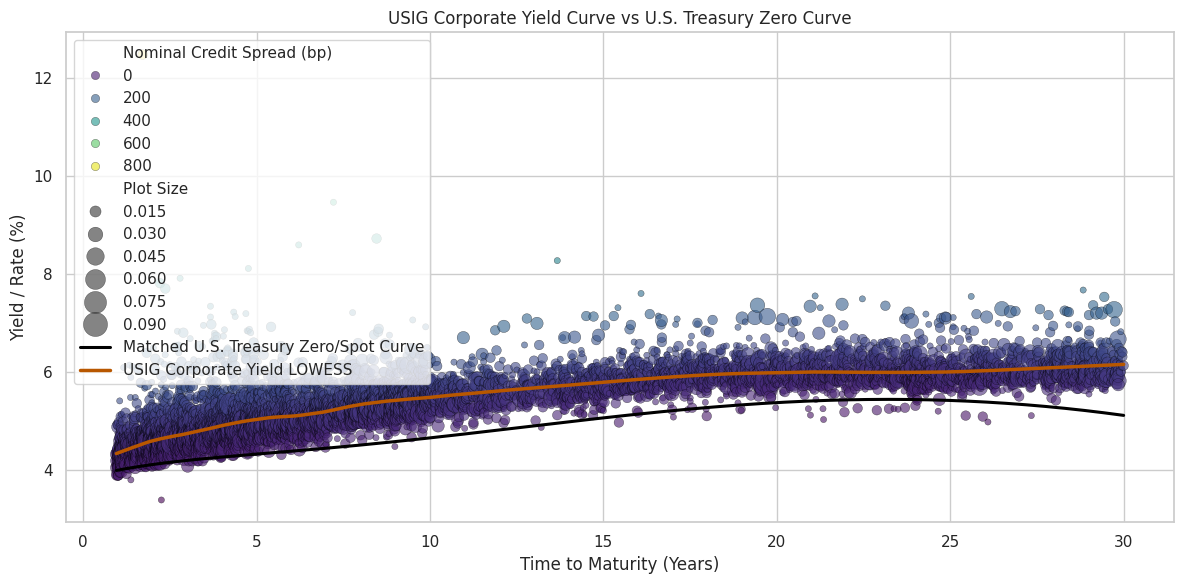

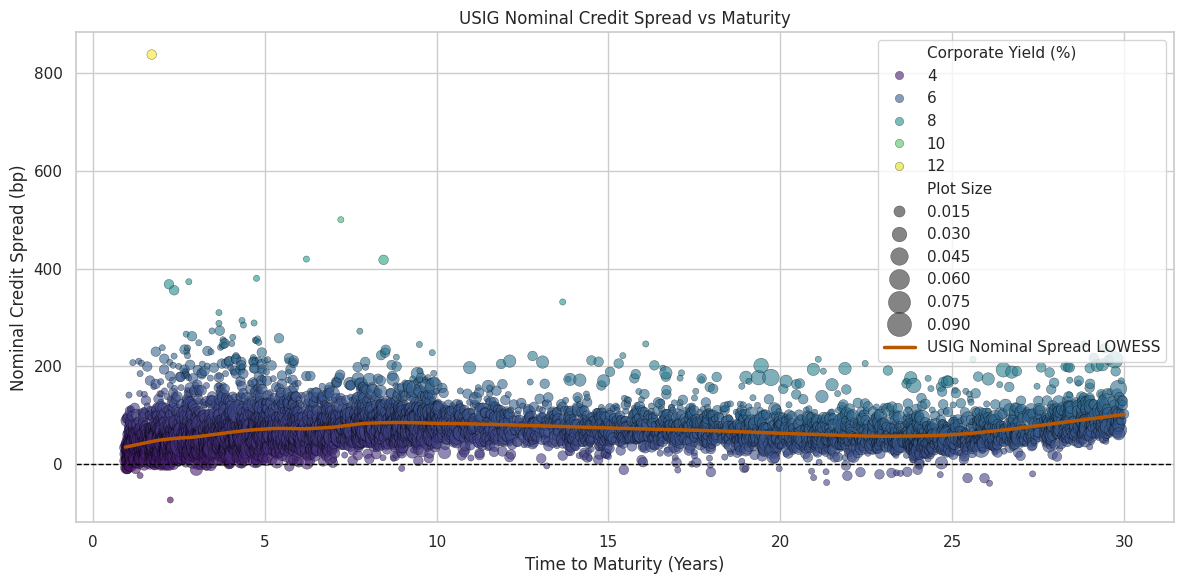

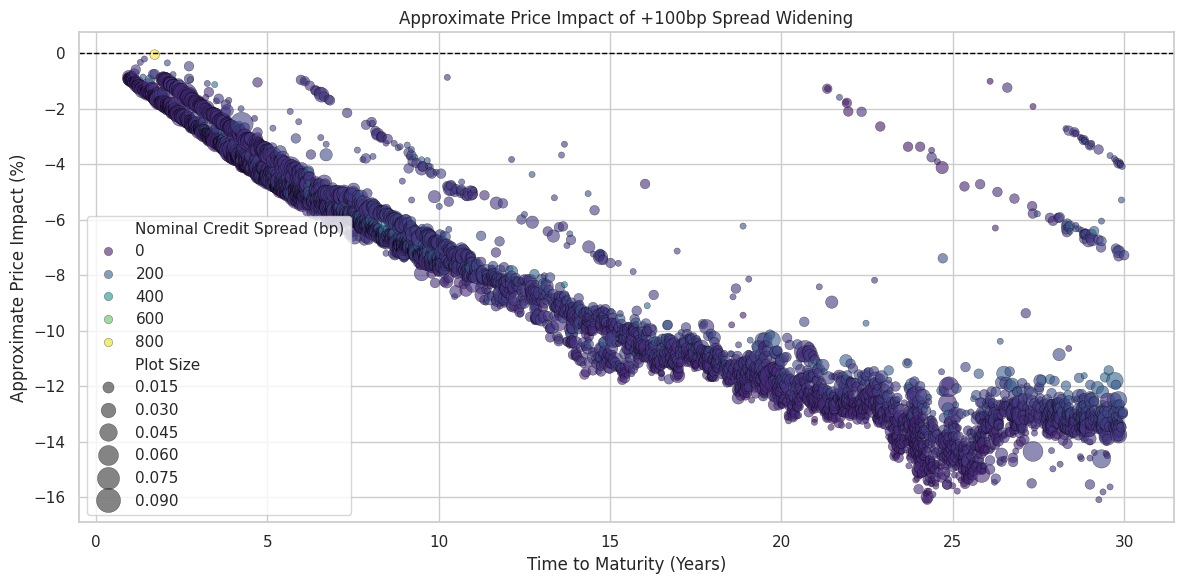

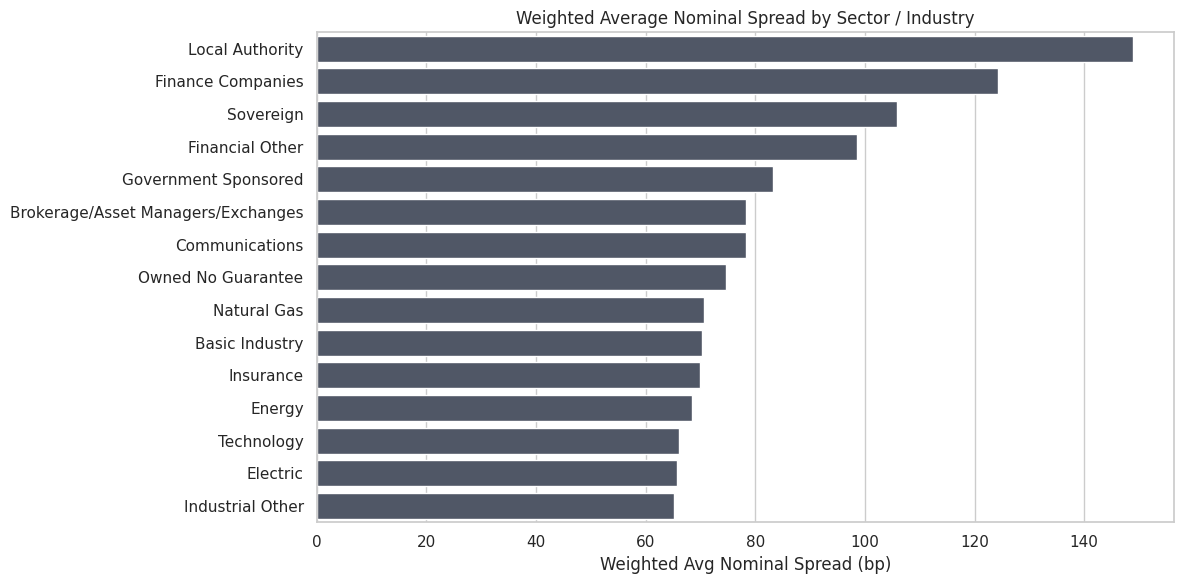

In [30]:
# ============================================================
# MODULE: USIG Credit Spreads
# Block 2: Output only
#
# Required from Block 1:
#   usig_raw
#   usig_df
#   usig_spread_df
#   usig_file_date
#   usig_eval_date
#   spread_duration_source
#
# Outputs:
#   spread_summary
#   sector_summary
#   rating_summary
#   usig_curve_lowess_df
#   spread_lowess_df
#   usig_output_plot_df
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess


# ------------------------------------------------------------
# Validate inputs
# ------------------------------------------------------------

required_objects = [
    "usig_raw",
    "usig_df",
    "usig_spread_df",
    "usig_file_date",
    "usig_eval_date",
    "spread_duration_source",
]

missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise NameError(f"Missing required objects from USIG Block 1: {missing_objects}")


# ------------------------------------------------------------
# Display settings
# ------------------------------------------------------------

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", "{:,.4f}".format)


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def weighted_average(series, weights):
    s = pd.to_numeric(series, errors="coerce")
    w = pd.to_numeric(weights, errors="coerce")

    mask = s.notna() & w.notna() & (w > 0)

    if not mask.any():
        return np.nan

    return float(np.average(s[mask], weights=w[mask]))


def make_lowess_table(
    df,
    x_col,
    y_col,
    output_x_col,
    output_y_col,
    frac=0.15,
    min_points=5,
):
    """
    Build LOWESS table from grouped x/y values.
    """
    temp = df[[x_col, y_col]].copy()

    temp[x_col] = pd.to_numeric(temp[x_col], errors="coerce").astype("float64")
    temp[y_col] = pd.to_numeric(temp[y_col], errors="coerce").astype("float64")

    temp = (
        temp
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=[x_col, y_col])
        .copy()
    )

    grouped = (
        temp
        .groupby(x_col, as_index=False)
        .agg({y_col: "mean"})
        .sort_values(x_col)
    )

    if len(grouped) < min_points:
        return pd.DataFrame(columns=[output_x_col, output_y_col])

    fit = lowess(
        endog=grouped[y_col].to_numpy(dtype="float64"),
        exog=grouped[x_col].to_numpy(dtype="float64"),
        frac=float(frac),
        it=0,
        return_sorted=True,
    )

    return pd.DataFrame(fit, columns=[output_x_col, output_y_col])


def prepare_usig_output_plot_df(usig_spread_df):
    """
    Convert all plot columns to ordinary float64 to avoid seaborn dtype issues.
    """
    required_plot_cols = [
        "Time to Maturity",
        "Corporate Yield (%)",
        "Treasury Matched Zero Rate (%)",
        "Nominal Credit Spread (bp)",
        "Weight (%)",
        "Spread Duration Used",
        "Price Impact of Spread Widening (%)",
    ]

    missing = [c for c in required_plot_cols if c not in usig_spread_df.columns]

    if missing:
        raise KeyError(f"Missing required output columns: {missing}")

    plot_df = usig_spread_df.copy()

    for col in required_plot_cols:
        plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce").astype("float64")

    plot_df = (
        plot_df
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=required_plot_cols)
        .copy()
    )

    plot_df = plot_df[
        (plot_df["Time to Maturity"] > 0)
        & (plot_df["Corporate Yield (%)"] > 0)
        & (plot_df["Treasury Matched Zero Rate (%)"] > 0)
        & (plot_df["Weight (%)"] >= 0)
    ].copy()

    if plot_df.empty:
        raise ValueError("No valid rows left for USIG output plots.")

    plot_df["Plot Size"] = np.clip(
        plot_df["Weight (%)"].to_numpy(dtype="float64"),
        0.001,
        None,
    )

    return plot_df


# ------------------------------------------------------------
# Prepare output data
# ------------------------------------------------------------

usig_output_plot_df = prepare_usig_output_plot_df(usig_spread_df)

usig_curve_lowess_df = make_lowess_table(
    df=usig_output_plot_df,
    x_col="Time to Maturity",
    y_col="Corporate Yield (%)",
    output_x_col="Time to Maturity",
    output_y_col="USIG LOWESS Corporate Yield (%)",
    frac=0.15,
)

spread_lowess_df = make_lowess_table(
    df=usig_output_plot_df,
    x_col="Time to Maturity",
    y_col="Nominal Credit Spread (bp)",
    output_x_col="Time to Maturity",
    output_y_col="USIG LOWESS Nominal Spread (bp)",
    frac=0.15,
)


# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

spread_summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "USIG Holdings File Date",
        "USIG Eval Date Used",
        "Weighted Avg Corporate Yield (%)",
        "Weighted Avg Treasury Matched Zero (%)",
        "Weighted Avg Nominal Spread (bp)",
        "Median Nominal Spread (bp)",
        "Min Nominal Spread (bp)",
        "Max Nominal Spread (bp)",
        "Weighted Avg Spread Duration",
        "Weighted Price Impact of Spread Widening (%)",
        "Spread Duration Source",
    ],
    "Value": [
        len(usig_output_plot_df),
        pd.Timestamp(usig_file_date).date(),
        pd.Timestamp(usig_eval_date).date(),
        weighted_average(
            usig_output_plot_df["Corporate Yield (%)"],
            usig_output_plot_df["Weight (%)"],
        ),
        weighted_average(
            usig_output_plot_df["Treasury Matched Zero Rate (%)"],
            usig_output_plot_df["Weight (%)"],
        ),
        weighted_average(
            usig_output_plot_df["Nominal Credit Spread (bp)"],
            usig_output_plot_df["Weight (%)"],
        ),
        usig_output_plot_df["Nominal Credit Spread (bp)"].median(),
        usig_output_plot_df["Nominal Credit Spread (bp)"].min(),
        usig_output_plot_df["Nominal Credit Spread (bp)"].max(),
        weighted_average(
            usig_output_plot_df["Spread Duration Used"],
            usig_output_plot_df["Weight (%)"],
        ),
        weighted_average(
            usig_output_plot_df["Price Impact of Spread Widening (%)"],
            usig_output_plot_df["Weight (%)"],
        ),
        spread_duration_source,
    ],
})

print("=== USIG CREDIT SPREAD SUMMARY ===")
display(spread_summary)


# ------------------------------------------------------------
# Holdings / spread preview
# ------------------------------------------------------------

preview_cols = [
    "Name",
    "Issuer",
    "Ticker",
    "Sector",
    "Industry",
    "Rating",
    "Maturity",
    "Time to Maturity",
    "Weight (%)",
    "Price",
    "Coupon (%)",
    "Corporate Yield (%)",
    "Treasury Matched Zero Rate (%)",
    "Nominal Credit Spread (%)",
    "Nominal Credit Spread (bp)",
    "Spread Duration Used",
    "Price Impact of Spread Widening (%)",
]

preview_cols = [c for c in preview_cols if c in usig_spread_df.columns]

print("=== USIG SPREAD TABLE PREVIEW ===")
display(
    usig_spread_df[preview_cols]
    .sort_values("Nominal Credit Spread (bp)", ascending=False)
    .head(30)
)


# ------------------------------------------------------------
# Sector summary
# ------------------------------------------------------------

sector_summary = pd.DataFrame()

sector_col = None

for candidate in ["Sector", "Sector Name", "Industry", "Asset Class"]:
    if candidate in usig_spread_df.columns:
        sector_col = candidate
        break

if sector_col is not None:
    sector_summary = (
        usig_spread_df
        .dropna(subset=[sector_col])
        .groupby(sector_col, observed=True)
        .apply(
            lambda g: pd.Series({
                "Bonds": len(g),
                "Weight (%)": g["Weight (%)"].sum(),
                "Weighted Avg Corporate Yield (%)": weighted_average(
                    g["Corporate Yield (%)"],
                    g["Weight (%)"],
                ),
                "Weighted Avg Spread (bp)": weighted_average(
                    g["Nominal Credit Spread (bp)"],
                    g["Weight (%)"],
                ),
                "Median Spread (bp)": g["Nominal Credit Spread (bp)"].median(),
                "Weighted Avg Spread Duration": weighted_average(
                    g["Spread Duration Used"],
                    g["Weight (%)"],
                ),
                "Weighted Price Impact (%)": weighted_average(
                    g["Price Impact of Spread Widening (%)"],
                    g["Weight (%)"],
                ),
            })
        )
        .reset_index()
        .sort_values("Weighted Avg Spread (bp)", ascending=False)
    )

    print("=== SECTOR / INDUSTRY SPREAD SUMMARY ===")
    display(sector_summary)


# ------------------------------------------------------------
# Rating summary
# ------------------------------------------------------------

rating_summary = pd.DataFrame()

rating_col = None

for candidate in ["Rating", "S&P Rating", "Moody Rating", "Fitch Rating"]:
    if candidate in usig_spread_df.columns:
        rating_col = candidate
        break

if rating_col is not None:
    rating_summary = (
        usig_spread_df
        .dropna(subset=[rating_col])
        .groupby(rating_col, observed=True)
        .apply(
            lambda g: pd.Series({
                "Bonds": len(g),
                "Weight (%)": g["Weight (%)"].sum(),
                "Weighted Avg Corporate Yield (%)": weighted_average(
                    g["Corporate Yield (%)"],
                    g["Weight (%)"],
                ),
                "Weighted Avg Spread (bp)": weighted_average(
                    g["Nominal Credit Spread (bp)"],
                    g["Weight (%)"],
                ),
                "Median Spread (bp)": g["Nominal Credit Spread (bp)"].median(),
                "Weighted Avg Spread Duration": weighted_average(
                    g["Spread Duration Used"],
                    g["Weight (%)"],
                ),
                "Weighted Price Impact (%)": weighted_average(
                    g["Price Impact of Spread Widening (%)"],
                    g["Weight (%)"],
                ),
            })
        )
        .reset_index()
        .sort_values("Weighted Avg Spread (bp)", ascending=False)
    )

    print("=== RATING SPREAD SUMMARY ===")
    display(rating_summary)


# ------------------------------------------------------------
# Plot 1:
# U.S. Treasury yield curve vs USIG corporate yield curve
# ------------------------------------------------------------

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=usig_output_plot_df,
    x="Time to Maturity",
    y="Corporate Yield (%)",
    size="Plot Size",
    hue="Nominal Credit Spread (bp)",
    sizes=(20, 300),
    palette="viridis",
    alpha=0.60,
    edgecolor="black",
    linewidth=0.3,
)

treasury_curve_line = (
    usig_output_plot_df[
        ["Time to Maturity", "Treasury Matched Zero Rate (%)"]
    ]
    .dropna()
    .sort_values("Time to Maturity")
    .copy()
)

sns.lineplot(
    data=treasury_curve_line,
    x="Time to Maturity",
    y="Treasury Matched Zero Rate (%)",
    color="black",
    linewidth=2.2,
    label="Matched U.S. Treasury Zero/Spot Curve",
)

if not usig_curve_lowess_df.empty:
    sns.lineplot(
        data=usig_curve_lowess_df,
        x="Time to Maturity",
        y="USIG LOWESS Corporate Yield (%)",
        color="#B85700",
        linewidth=2.5,
        label="USIG Corporate Yield LOWESS",
    )

plt.title("USIG Corporate Yield Curve vs U.S. Treasury Zero Curve")
plt.xlabel("Time to Maturity (Years)")
plt.ylabel("Yield / Rate (%)")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot 2:
# Nominal credit spread curve with LOWESS
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=usig_output_plot_df,
    x="Time to Maturity",
    y="Nominal Credit Spread (bp)",
    size="Plot Size",
    hue="Corporate Yield (%)",
    sizes=(20, 300),
    palette="viridis",
    alpha=0.60,
    edgecolor="black",
    linewidth=0.3,
)

if not spread_lowess_df.empty:
    sns.lineplot(
        data=spread_lowess_df,
        x="Time to Maturity",
        y="USIG LOWESS Nominal Spread (bp)",
        color="#B85700",
        linewidth=2.5,
        label="USIG Nominal Spread LOWESS",
    )

plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.title("USIG Nominal Credit Spread vs Maturity")
plt.xlabel("Time to Maturity (Years)")
plt.ylabel("Nominal Credit Spread (bp)")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot 3:
# Spread duration stress: price impact of spread widening
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=usig_output_plot_df,
    x="Time to Maturity",
    y="Price Impact of Spread Widening (%)",
    size="Plot Size",
    hue="Nominal Credit Spread (bp)",
    sizes=(20, 300),
    palette="viridis",
    alpha=0.60,
    edgecolor="black",
    linewidth=0.3,
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)

spread_widening_bp = (
    USIG_CONFIG["spread_widening_bp"]
    if "USIG_CONFIG" in globals() and "spread_widening_bp" in USIG_CONFIG
    else 100
)

plt.title(f"Approximate Price Impact of +{spread_widening_bp}bp Spread Widening")
plt.xlabel("Time to Maturity (Years)")
plt.ylabel("Approximate Price Impact (%)")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot 4:
# Sector / industry spread bar chart, if available
# ------------------------------------------------------------

if not sector_summary.empty:
    plt.figure(figsize=(12, 6))

    sector_plot = sector_summary.sort_values(
        "Weighted Avg Spread (bp)",
        ascending=False,
    ).head(15)

    sns.barplot(
        data=sector_plot,
        x="Weighted Avg Spread (bp)",
        y=sector_col,
        color="#4C566A",
    )

    plt.title("Weighted Average Nominal Spread by Sector / Industry")
    plt.xlabel("Weighted Avg Nominal Spread (bp)")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Plot 5:
# Rating spread bar chart, if available
# ------------------------------------------------------------

if not rating_summary.empty:
    plt.figure(figsize=(10, 6))

    rating_plot = rating_summary.sort_values(
        "Weighted Avg Spread (bp)",
        ascending=False,
    )

    sns.barplot(
        data=rating_plot,
        x="Weighted Avg Spread (bp)",
        y=rating_col,
        color="#4C566A",
    )

    plt.title("Weighted Average Nominal Spread by Rating")
    plt.xlabel("Weighted Avg Nominal Spread (bp)")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=f46a0507-8a9e-41ab-a24b-9020d88794e6' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>